## 11/24 軌跡復現

### 國產資料

In [13]:
## lib 
from pathlib import Path
import webbrowser

# 匯入自訂模組
from data_loader import load_and_preprocess
from voyage_splitter import detect_stops, split_voyages, voyage_quality_checker
from visualization import visualize_voyages
from od_marker import assign_ports
from Trajectory_Recon import TrajectoryReconstructor  # 新增這行
from data_quality import voyage_integrity_metrics

In [14]:
csv_path = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "477300400_VesselHistoryLineInfo.csv"
target_mmsi = 477300400

print("載入與前處理資料中...")
df = load_and_preprocess(csv_path, target_mmsi)
print(f"清理後資料筆數: {len(df)}")

print("執行停泊判斷...")
stop_segments_initial = detect_stops(df)
print(f"偵測到停泊區段數量: {len(stop_segments_initial)}")

# -----------------------------------
# Step 3: 傳統航程切分（供 QA / 缺口偵測使用）
# -----------------------------------
print("切分航程（傳統：停泊→航行→停泊）...")
df_with_voyages, voyages_raw = split_voyages(df, stop_segments_initial)
print(f"切分後航程數量: {len(voyages_raw)}")

# -----------------------------------
# Step 4: 航程 QA
# -----------------------------------
print("執行航程 QA 檢查...")
voyages_qc = voyage_quality_checker(
    df_with_voyages,
    voyages_raw,
    stop_segments=stop_segments_initial
)
print(f"QA 完成，有效航程數量: {voyages_qc['valid_flag'].sum()}")
visualize_voyages(df_with_voyages, voyages_raw)
import webbrowser

webbrowser.open("voyages_map.html")

載入與前處理資料中...
  已套用 SOG_CAP=50.0：刪除 46145 筆不合理 SOG
清理後資料筆數: 154733
執行停泊判斷...
偵測到停泊區段數量: 215
切分航程（傳統：停泊→航行→停泊）...
切分後航程數量: 214
執行航程 QA 檢查...
QA 完成，有效航程數量: 1
Map saved to voyages_map.html


True

In [17]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np

LAND_FILE = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp")
PORTS_CSV = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\filtered_ports.csv")

land = gpd.read_file(LAND_FILE)

def parse_timestamp(series: pd.Series) -> pd.Series:
    series = series.astype(str).str.strip()
    mask_ais = series.str.match(r"^\d{14}$")
    ts = pd.to_datetime(series[mask_ais], format="%Y%m%d%H%M%S", errors="coerce")
    ts_other = pd.to_datetime(series[~mask_ais], errors="coerce")
    ts = pd.concat([ts, ts_other]).sort_index()
    return ts

def load_and_preprocess_no_sogcap(csv_path: Path, target_mmsi: int) -> pd.DataFrame:
    df = pd.read_csv(csv_path, low_memory=False)

    # 經度欄位名稱處理
    if "Long" in df.columns:
        pass
    elif "Lng" in df.columns:
        df = df.rename(columns={"Lng": "Long"})
    else:
        print(f" 找不到經度欄位，欄位清單: {list(df.columns)}")
        raise ValueError("請確認經度欄位名稱 (必須是 Long 或 Lng)")

    # 時間欄位名稱處理
    if "Timestamp" in df.columns:
        pass
    elif "DataSourceLastTime_UTC" in df.columns:
        df = df.rename(columns={"DataSourceLastTime_UTC": "Timestamp"})
    else:
        print(f" 找不到時間欄位，欄位清單: {list(df.columns)}")
        raise ValueError("請確認時間欄位名稱 (必須是 Timestamp 或 DataSourceLastTime_UTC)")

    # MMSI 篩選（強制轉 Int 比對）
    df = df[df["MMSI"].round().astype("Int64") == int(target_mmsi)].copy()

    # 基本欄位清理（先轉數值）
    df["Lat"] = pd.to_numeric(df["Lat"], errors="coerce")
    df["Long"] = pd.to_numeric(df["Long"], errors="coerce")
    df["Sog"] = pd.to_numeric(df["Sog"], errors="coerce")

    # 時間處理（先做 Timestamp，才能做「更換設備 SOG 校正」）
    df["Timestamp"] = parse_timestamp(df["Timestamp"])
    df = df.dropna(subset=["Timestamp"])

    # 特例：豐順輪(MMSI=477769500) 更換設備後 SOG 單位校正
    if int(target_mmsi) == 477769500:
        sog_fix_threshold = pd.to_datetime("2025-07-25 10:58:10")
        mask = df["Timestamp"] > sog_fix_threshold
        df.loc[mask, "Sog"] = df.loc[mask, "Sog"] / 10.0
        print("  已對 MMSI=477769500 進行 SOG 校正（/10）")

    # 去除缺值（放在校正後）
    df = df.dropna(subset=["Lat", "Long", "Sog"])

    # 經緯度範圍過濾
    df = df[df["Lat"].between(-90.0, 90.0)]
    df = df[df["Long"].between(-180.0, 180.0)]

    # Long_360（在經度合理後再算）
    df["Long_360"] = df["Long"] % 360

    # ✅ 不做 SOG_CAP 篩選（也不過濾負值），保留原始 Sog 分布

    # 排序
    df = df.sort_values("Timestamp", kind="mergesort").reset_index(drop=True)

    return df


N = 200878
min/max = 0.0 165.0
mean/std = 26.55229585965434 47.121954043319015

Quantiles:
0.00      0.000000
0.01      0.000000
0.05      0.000000
0.10      0.000000
0.25      0.000000
0.50      0.000000
0.75     14.912451
0.90    115.000000
0.95    126.000000
0.99    137.000000
1.00    165.000000
Name: Sog, dtype: float64

Counts:
Sog < 0: 0
Sog = 0: 134370
Sog > 50: 46145
Sog > 100: 34711


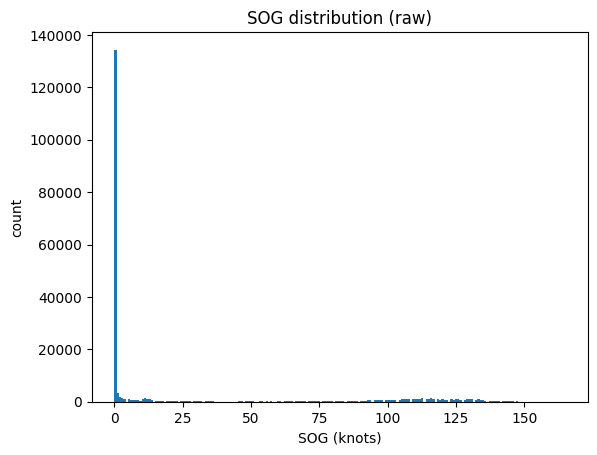

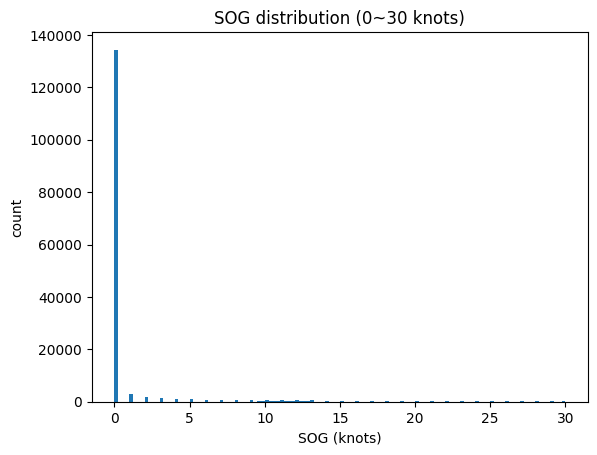

In [18]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

csv_path = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "477300400_VesselHistoryLineInfo.csv"
target_mmsi = 477300400

df = load_and_preprocess_no_sogcap(csv_path, target_mmsi)

sog = df["Sog"].astype(float)

print("N =", len(sog))
print("min/max =", sog.min(), sog.max())
print("mean/std =", sog.mean(), sog.std())
print("\nQuantiles:")
print(sog.quantile([0, .01, .05, .1, .25, .5, .75, .9, .95, .99, 1.0]))

# 極端值概覽（你可自行改門檻）
print("\nCounts:")
print("Sog < 0:", (sog < 0).sum())
print("Sog = 0:", (sog == 0).sum())
print("Sog > 50:", (sog > 50).sum())
print("Sog > 100:", (sog > 100).sum())

# 直方圖：全域（可能會被極端值拉扁）
plt.figure()
plt.hist(sog.dropna(), bins=200)
plt.title("SOG distribution (raw)")
plt.xlabel("SOG (knots)")
plt.ylabel("count")
plt.show()

# 直方圖：聚焦常見區間（更好讀）
plt.figure()
plt.hist(sog[(sog >= 0) & (sog <= 30)].dropna(), bins=120)
plt.title("SOG distribution (0~30 knots)")
plt.xlabel("SOG (knots)")
plt.ylabel("count")
plt.show()


In [19]:
thr = 30

mask = df["Sog"] > thr
if not mask.any():
    print(f"沒有出現 Sog > {thr}")
else:
    first_idx = df.index[mask][0]              # 因為 df 已按 Timestamp 排序
    first_row = df.loc[first_idx]

    print(f"最早出現 Sog > {thr} 的時間：{first_row['Timestamp']}")
    print(f"index={first_idx}, Sog={first_row['Sog']}, Lat={first_row['Lat']}, Long={first_row['Long']}")

    # 看前後各 5 筆（你可改成 10 或更多）
    w = 5
    display(df.loc[max(first_idx - w, 0): first_idx + w, ["Timestamp", "Lat", "Long", "Sog"]])


最早出現 Sog > 30 的時間：2025-01-01 10:09:19
index=302, Sog=37.0, Lat=26.00940333333333, Long=119.48213833333334


,Timestamp,Lat,Long,Sog
297,2025-01-01 09:59:28,26.008182,119.481100,29.0
298,2025-01-01 10:01:18,26.006502,119.480722,22.0
299,2025-01-01 10:03:19,26.006202,119.480397,0.0
300,2025-01-01 10:05:19,26.006572,119.480730,15.0
301,2025-01-01 10:07:20,26.007688,119.481335,28.0
302,2025-01-01 10:09:19,26.009403,119.482138,37.0
303,2025-01-01 10:11:18,26.011633,119.482845,45.0
304,2025-01-01 10:13:18,26.013963,119.484303,51.0
305,2025-01-01 10:15:18,26.016010,119.486787,54.0
306,2025-01-01 10:17:18,26.017957,119.489492,57.0


In [15]:
webbrowser.open("voyages_map.html")

True

## 討論實作

### Library

In [ ]:
import numpy as np
import pandas as pd
from haversine import haversine
from voyage_splitter import _safe_haversine  # 直接沿用你原本的小工具


### 從 stop_segments → 停泊 episodes + 合併碎段

In [ ]:
def build_raw_stop_episodes(df, stop_segments):
    """
    將 detect_stops 回傳的 stop_segments(list of range)
    轉成一個 DataFrame：每列是一個「原始停泊 episode」
    """
    records = []
    for seg_id, seg in enumerate(stop_segments, start=1):
        idxs = list(seg)
        if not idxs:
            continue
        start_idx = idxs[0]
        end_idx   = idxs[-1]
        t_start = df.loc[start_idx, "Timestamp"]
        t_end   = df.loc[end_idx, "Timestamp"]
        duration_sec = (t_end - t_start).total_seconds()
        
        lat_center = df.loc[idxs, "Lat"].median()
        lon_center = df.loc[idxs, "Long"].median()
        sog_mean   = df.loc[idxs, "Sog"].mean()
        sog_std    = df.loc[idxs, "Sog"].std()
        
        # 半徑：用 95% 的點到中心距離（km）
        distances = [
            _safe_haversine(
                (lat_center, lon_center),
                (df.loc[j, "Lat"], df.loc[j, "Long"])
            )
            for j in idxs
        ]
        radius_km = float(np.percentile(distances, 95)) if distances else 0.0
        
        records.append({
            "raw_stop_id": seg_id,
            "start_idx": start_idx,
            "end_idx": end_idx,
            "t_start": t_start,
            "t_end": t_end,
            "duration_sec": duration_sec,
            "center_lat": lat_center,
            "center_lon": lon_center,
            "avg_sog": sog_mean,
            "sog_std": sog_std,
            "radius_km": radius_km,
        })
    
    return pd.DataFrame(records)


def merge_stop_episodes(df,
                        stops_raw,
                        max_gap_sec=30*60,
                        max_center_dist_km=1.0,
                        max_move_duration_sec=30*60,
                        max_move_disp_km=2.0,
                        max_move_avg_sog_kn=2.0):
    """
    將「相鄰停泊 episode」根據：
      - 中間 MOVE 是否很小（時間短、距離短、速度低）
      - 兩個停泊中心的時間間隔 + 空間距離是否很近
    進行合併，輸出較乾淨的 stops_merged DataFrame。
    
    df: 原始 AIS (已排序)
    stops_raw: build_raw_stop_episodes() 的輸出
    """

    if stops_raw.empty:
        return stops_raw.copy().assign(stop_id=lambda x: np.arange(1, len(x)+1))

    # 依時間排序一下（保險起見）
    stops_raw = stops_raw.sort_values("t_start").reset_index(drop=True)

    merged_records = []
    # 初始化第一個 group
    cur_start_idx = stops_raw.loc[0, "start_idx"]
    cur_end_idx   = stops_raw.loc[0, "end_idx"]

    for i in range(len(stops_raw) - 1):
        this_row = stops_raw.loc[i]
        next_row = stops_raw.loc[i+1]

        this_end_idx = int(this_row["end_idx"])
        next_start_idx = int(next_row["start_idx"])

        # 時間 gap
        gap_sec = (next_row["t_start"] - this_row["t_end"]).total_seconds()

        # 兩個停泊中心距離
        center_dist_km = _safe_haversine(
            (this_row["center_lat"], this_row["center_lon"]),
            (next_row["center_lat"], next_row["center_lon"])
        )

        # 中間 MOVE 區段（可能沒有）
        move_start_idx = this_end_idx + 1
        move_end_idx   = next_start_idx - 1

        has_move = move_start_idx <= move_end_idx
        move_duration_sec = 0.0
        move_disp_km = 0.0
        move_avg_sog = 0.0

        if has_move:
            t_move_start = df.loc[move_start_idx, "Timestamp"]
            t_move_end   = df.loc[move_end_idx, "Timestamp"]
            move_duration_sec = (t_move_end - t_move_start).total_seconds()
            move_disp_km = _safe_haversine(
                (df.loc[move_start_idx, "Lat"], df.loc[move_start_idx, "Long"]),
                (df.loc[move_end_idx, "Lat"],   df.loc[move_end_idx, "Long"])
            )
            move_avg_sog = df.loc[move_start_idx:move_end_idx, "Sog"].mean()

        # 判定是否要把 this_row 與 next_row 合併
        # 條件：時間不離太久 + 中心點距離不遠 + 中間 MOVE 不明顯
        cond_time_close   = gap_sec <= max_gap_sec
        cond_center_close = center_dist_km <= max_center_dist_km

        # 若有 MOVE，就看 MOVE 的尺度是否夠小；若沒有 MOVE，就視為很小
        if has_move:
            cond_move_small = (
                (move_duration_sec <= max_move_duration_sec) and
                (move_disp_km <= max_move_disp_km) and
                (move_avg_sog <= max_move_avg_sog_kn)
            )
        else:
            cond_move_small = True

        if cond_time_close and cond_center_close and cond_move_small:
            # 視為同一次停泊，延伸目前 group 的 end_idx
            cur_end_idx = int(next_row["end_idx"])
        else:
            # 結束目前 group，寫入紀錄
            merged_records.append((cur_start_idx, cur_end_idx))
            # 開啟新的 group
            cur_start_idx = int(next_row["start_idx"])
            cur_end_idx   = int(next_row["end_idx"])

    # 最後一個 group
    merged_records.append((cur_start_idx, cur_end_idx))

    # 將 merged_records 再轉成 stops_merged 表
    merged_rows = []
    for stop_id, (s_idx, e_idx) in enumerate(merged_records, start=1):
        idxs = list(range(s_idx, e_idx + 1))
        t_start = df.loc[s_idx, "Timestamp"]
        t_end   = df.loc[e_idx, "Timestamp"]
        duration_sec = (t_end - t_start).total_seconds()

        lat_center = df.loc[idxs, "Lat"].median()
        lon_center = df.loc[idxs, "Long"].median()
        sog_mean   = df.loc[idxs, "Sog"].mean()
        sog_std    = df.loc[idxs, "Sog"].std()

        distances = [
            _safe_haversine(
                (lat_center, lon_center),
                (df.loc[j, "Lat"], df.loc[j, "Long"])
            )
            for j in idxs
        ]
        radius_km = float(np.percentile(distances, 95)) if distances else 0.0

        merged_rows.append({
            "stop_id": stop_id,
            "start_idx": s_idx,
            "end_idx": e_idx,
            "t_start": t_start,
            "t_end": t_end,
            "duration_sec": duration_sec,
            "center_lat": lat_center,
            "center_lon": lon_center,
            "avg_sog": sog_mean,
            "sog_std": sog_std,
            "radius_km": radius_km
        })

    return pd.DataFrame(merged_rows)


# ==== 實際執行：由 stop_segments_initial 產生 stops_merged ====
stops_raw = build_raw_stop_episodes(df, stop_segments_initial)
stops_merged = merge_stop_episodes(df, stops_raw)

print("原始停泊段數量:", len(stops_raw))
print("合併後停泊段數量:", len(stops_merged))
stops_merged.head()


### Port/ Port Call / Anchorage 分類

In [ ]:
# TODO：換成你真正的港口清單路徑與欄位名稱
# 例如 ports_df = pd.read_csv("ports70.csv")
# 要確保裡面有 columns: port_id, port_name, lat, lon
# -----------------------------------------------------
# 示例：
# ports_df = pd.read_csv("ports_master.csv")
# ports_df = ports_df.rename(columns={
#     "locode": "port_id",
#     "name": "port_name",
#     "lat": "lat",
#     "lon": "lon"
# })


def attach_nearest_port_to_stops(stops_df, ports_df):
    """
    對每個停泊 episode，找出最近的港口 (by haversine)
    回傳一個新的 DataFrame，增加:
      - nearest_port_id
      - nearest_port_name
      - dist_to_port_km
    """
    stops_df = stops_df.copy()
    
    port_coords = ports_df[["port_id", "port_name", "lat", "lon"]].to_dict(orient="records")

    nearest_ids = []
    nearest_names = []
    nearest_dists = []

    for _, row in stops_df.iterrows():
        lat0 = row["center_lat"]
        lon0 = row["center_lon"]

        best_port_id = None
        best_port_name = None
        best_dist = np.inf

        for p in port_coords:
            d = haversine((lat0, lon0), (p["lat"], p["lon"]))  # km
            if d < best_dist:
                best_dist = d
                best_port_id = p["port_id"]
                best_port_name = p["port_name"]

        nearest_ids.append(best_port_id)
        nearest_names.append(best_port_name)
        nearest_dists.append(best_dist)

    stops_df["nearest_port_id"] = nearest_ids
    stops_df["nearest_port_name"] = nearest_names
    stops_df["dist_to_port_km"] = nearest_dists

    return stops_df


def classify_stop_type(stops_df,
                       call_max_dist_km=15.0,
                       call_min_duration_sec=4*3600,
                       call_max_avg_sog_kn=0.1,
                       call_max_sog_std_kn=0.1,
                       call_max_radius_km=0.5,
                       anch_max_dist_km=30.0,
                       anch_min_duration_sec=1800,
                       anch_min_avg_sog_kn=0.1,
                       anch_max_avg_sog_kn=2.0):
    """
    根據「距離 + 速度型態 + 半徑 + duration」分類停泊型態：
      - port_call
      - anchorage_like
      - other
    參數都先給一組合理 default，之後你可以視資料調整。
    """
    stops_df = stops_df.copy()
    stops_df["stop_type"] = "other"

    # Port Call：貼港邊、幾乎不動、停很久、radius 很小
    mask_call = (
        (stops_df["dist_to_port_km"] <= call_max_dist_km) &
        (stops_df["duration_sec"]   >= call_min_duration_sec) &
        (stops_df["avg_sog"].fillna(0) <= call_max_avg_sog_kn) &
        (stops_df["sog_std"].fillna(0) <= call_max_sog_std_kn) &
        (stops_df["radius_km"].fillna(0) <= call_max_radius_km)
    )

    stops_df.loc[mask_call, "stop_type"] = "port_call"

    # Anchorage-like：距港在一定範圍內、duration 不短、有微速、radius 較大
    mask_anch = (
        (stops_df["stop_type"] == "other") &  # 不要覆蓋掉 port_call
        (stops_df["dist_to_port_km"] <= anch_max_dist_km) &
        (stops_df["duration_sec"]   >= anch_min_duration_sec) &
        (stops_df["avg_sog"].fillna(0) >= anch_min_avg_sog_kn) &
        (stops_df["avg_sog"].fillna(0) <= anch_max_avg_sog_kn)
    )
    stops_df.loc[mask_anch, "stop_type"] = "anchorage_like"

    return stops_df


# ==== 實際執行：stops_merged -> 貼最近港 -> 分類型態 ====
# 這裡假設你已經在上面載入好 ports_df
stops_with_port = attach_nearest_port_to_stops(stops_merged, ports_df)
stops_classified = classify_stop_type(stops_with_port)

stops_classified["stop_type"].value_counts()
stops_classified.head()


### Port Call → 港到港 Voyages + waiting_for_dest 標記

In [ ]:
def build_port_calls(stops_classified):
    """
    從停泊 episodes 中挑出 stop_type == 'port_call' 的，形成 port_calls 表
    """
    calls = stops_classified[stops_classified["stop_type"] == "port_call"].copy()
    if calls.empty:
        return pd.DataFrame(columns=[
            "call_id", "mmsi", "port_id", "port_name",
            "t_arrive_port", "t_depart_port", "stop_id"
        ])

    calls = calls.sort_values("t_start").reset_index(drop=True)
    calls["call_id"] = np.arange(1, len(calls) + 1)

    port_calls = pd.DataFrame({
        "call_id": calls["call_id"],
        "mmsi": calls.get("mmsi", np.nan),  # 若 stops_merged 沒有 mmsi，就用 NaN
        "port_id": calls["nearest_port_id"],
        "port_name": calls["nearest_port_name"],
        "t_arrive_port": calls["t_start"],
        "t_depart_port": calls["t_end"],
        "stop_id": calls["stop_id"]
    })

    return port_calls


def build_voyages_from_port_calls(port_calls):
    """
    依照時間順序，將相鄰的 port_call 配對成一條條港到港 voyage。
    """
    if port_calls.empty or len(port_calls) < 2:
        return pd.DataFrame(columns=[
            "voyage_id", "origin_call_id", "dest_call_id",
            "origin_port_id", "dest_port_id",
            "origin_port_name", "dest_port_name",
            "t_depart_origin", "t_arrive_dest"
        ])

    port_calls = port_calls.sort_values("t_arrive_port").reset_index(drop=True)

    records = []
    voyage_id = 1
    for i in range(len(port_calls) - 1):
        row_o = port_calls.loc[i]
        row_d = port_calls.loc[i+1]

        records.append({
            "voyage_id": voyage_id,
            "origin_call_id": row_o["call_id"],
            "dest_call_id": row_d["call_id"],
            "origin_port_id": row_o["port_id"],
            "dest_port_id": row_d["port_id"],
            "origin_port_name": row_o["port_name"],
            "dest_port_name": row_d["port_name"],
            "t_depart_origin": row_o["t_depart_port"],
            "t_arrive_dest": row_d["t_arrive_port"]
        })
        voyage_id += 1

    voyages_p2p = pd.DataFrame(records)
    return voyages_p2p


def label_waiting_for_dest(stops_classified, voyages_p2p,
                           ports_df,
                           alpha_progress=0.7,
                           max_dist_to_dest_km=100.0):
    """
    對每條 A->B 的 voyage，標記其中「航程末段」發生的 anchorage-like 停泊為 waiting_for_B。
    
    規則（對每條 voyage）：
      - 取時間區間 [t_depart_origin, t_arrive_dest] 內的所有停泊 episodes
      - 跳過剛離 origin 的短停（透過 progress/距離自然排除）
      - 對每個停泊 episode 計算：
          progress = (t_mid - t_depart_origin) / (t_arrive_dest - t_depart_origin)
          dist_to_B = (停泊中心 → B港) 的距離
      - 若：
          progress >= alpha_progress
        且停泊型態為 anchorage_like（或你覺得合理的 waiting pattern）
        且 dist_to_B <= max_dist_to_dest_km
        => 標為 waiting_for_dest_port_id = dest_port_id
    
    回傳：
      - stops_labeled: 在 stops_classified 上加上 waiting_for_dest_port_id 欄位
      - voyages_with_waiting: 在 voyages_p2p 上增加 total_waiting_sec 等摘要
    """
    stops = stops_classified.copy()
    stops["waiting_for_dest_port_id"] = None  # 預設沒有被標成等待

    if voyages_p2p.empty:
        voyages_p2p["total_waiting_sec"] = 0.0
        return stops, voyages_p2p

    # 建立 port_id -> (lat, lon) 查表
    port_coord_map = {
        row["port_id"]: (row["lat"], row["lon"])
        for _, row in ports_df[["port_id", "lat", "lon"]].iterrows()
    }

    voyages_records = []

    for _, v in voyages_p2p.iterrows():
        voy_id = v["voyage_id"]
        dest_port = v["dest_port_id"]
        t_dep = v["t_depart_origin"]
        t_arr = v["t_arrive_dest"]

        if pd.isna(t_dep) or pd.isna(t_arr) or (t_arr <= t_dep):
            voyages_records.append({**v.to_dict(), "total_waiting_sec": 0.0})
            continue

        T_voy = (t_arr - t_dep).total_seconds()
        if T_voy <= 0:
            voyages_records.append({**v.to_dict(), "total_waiting_sec": 0.0})
            continue

        # 這條 voyage 期間內的停泊 episodes
        mask_in_voy = (
            (stops["t_start"] >= t_dep) &
            (stops["t_start"] <= t_arr)
        )
        stops_voy = stops[mask_in_voy].copy()
        if stops_voy.empty:
            voyages_records.append({**v.to_dict(), "total_waiting_sec": 0.0})
            continue

        # 目的港座標
        if dest_port not in port_coord_map:
            # 沒找到目的港座標，放棄這條 voyage 的距離判斷，只用 progress
            dest_lat, dest_lon = None, None
        else:
            dest_lat, dest_lon = port_coord_map[dest_port]

        waiting_ids = []
        total_waiting_sec = 0.0

        for idx, s in stops_voy.iterrows():
            # 錨泊型態優先考慮 anchorage_like；若你想放寬，可加其它 type
            if s["stop_type"] != "anchorage_like":
                continue

            # 停泊中點時間
            t_mid = s["t_start"] + (s["t_end"] - s["t_start"]) / 2
            progress = (t_mid - t_dep).total_seconds() / T_voy

            if progress < alpha_progress:
                # 航程前段的錨泊，不視為「為 B 等待」
                continue

            # 距離目的港（如果有座標）
            dist_to_B = np.inf
            if dest_lat is not None:
                dist_to_B = haversine((s["center_lat"], s["center_lon"]), (dest_lat, dest_lon))

            if dist_to_B > max_dist_to_dest_km:
                # 距離 B 太遠，就算時間在後段，也暫時不認為是等 B
                continue

            # 通過上述條件 → 視為 waiting_for_B
            waiting_ids.append(s["stop_id"])
            total_waiting_sec += s["duration_sec"]

        # 寫回 stops
        if waiting_ids:
            mask_wait = stops["stop_id"].isin(waiting_ids)
            stops.loc[mask_wait, "waiting_for_dest_port_id"] = dest_port

        # 為 voyage 本身加上 summary
        v_dict = v.to_dict()
        v_dict["total_waiting_sec"] = total_waiting_sec
        voyages_records.append(v_dict)

    voyages_with_waiting = pd.DataFrame(voyages_records)

    return stops, voyages_with_waiting


# ==== 實際執行 ====
port_calls = build_port_calls(stops_classified)
voyages_p2p = build_voyages_from_port_calls(port_calls)
stops_labeled, voyages_with_waiting = label_waiting_for_dest(
    stops_classified,
    voyages_p2p,
    ports_df,
    alpha_progress=0.7,
    max_dist_to_dest_km=100.0
)

print("Port calls 數量:", len(port_calls))
print("港到港 voyages 數量:", len(voyages_with_waiting))
print("有等待時間的航程數量:",
      (voyages_with_waiting["total_waiting_sec"] > 0).sum())

stops_labeled.head()
voyages_with_waiting.head()


### Main

In [1]:
# =========================
# main.py in Jupyter cell（整合版 - smart teleport + 港到港 + robust停泊分類）
# =========================

from pathlib import Path
import webbrowser

import numpy as np
import pandas as pd
from haversine import haversine

# 匯入自訂模組
from data_loader import load_and_preprocess
from voyage_splitter import (
    detect_stops,
    split_voyages,
    voyage_quality_checker,
    _safe_haversine,   # 小工具：改經度範圍後的 haversine
)
from visualization import visualize_voyages
from od_marker import assign_ports
from Trajectory_Recon import TrajectoryReconstructor
from data_quality import voyage_integrity_metrics


# ----------------------------
# 0. 基本設定
# ----------------------------
csv_path = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "477300400_VesselHistoryLineInfo.csv"
target_mmsi = 477300400

# 港口清單路徑：filtered_ports.csv，欄位為 unlocode, lat, lon
ports_csv = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "filtered_ports.csv"


# ----------------------------
# 0.5  移除雜訊點（teleport）- smart 迭代版
# ----------------------------

def remove_teleport_points(
    df: pd.DataFrame,
    speed_kn_th: float = 50.0,
    dt_max_sec: float = 3600.0,
    keep_report: bool = True
):
    """
    移除 AIS 瞬移點（teleport）
    - Rule A（三點檢查，中間點）：prev->cur 爆速 且 prev->next 合理 => 刪 cur
    - Rule B（開頭邊界點）：cur->next 爆速 且 next->next 正常 => 刪 cur
    - Rule C（結尾邊界點）：prev->cur 爆速 且 prev->prev 正常 => 刪 cur

    需要欄位：Timestamp, Lat, Long
    回傳：df_clean, report_df
    """
    d = df.sort_values("Timestamp").copy()

    # 避免你 df 本來就有 orig_index 造成重複欄位
    if "orig_index" in d.columns:
        d = d.rename(columns={"orig_index": "orig_index_old"})
    d = d.reset_index(drop=False).rename(columns={"index": "orig_index"})

    # prev/next
    d["Lat_prev"]   = d["Lat"].shift(1)
    d["Long_prev"]  = d["Long"].shift(1)
    d["T_prev"]     = d["Timestamp"].shift(1)

    d["Lat_next"]   = d["Lat"].shift(-1)
    d["Long_next"]  = d["Long"].shift(-1)
    d["T_next"]     = d["Timestamp"].shift(-1)

    d["Lat_next2"]  = d["Lat"].shift(-2)
    d["Long_next2"] = d["Long"].shift(-2)
    d["T_next2"]    = d["Timestamp"].shift(-2)

    d["Lat_prev2"]  = d["Lat"].shift(2)
    d["Long_prev2"] = d["Long"].shift(2)
    d["T_prev2"]    = d["Timestamp"].shift(2)

    # dt
    d["dt_prev_sec"]     = (d["Timestamp"] - d["T_prev"]).dt.total_seconds()
    d["dt_next_sec"]     = (d["T_next"] - d["Timestamp"]).dt.total_seconds()
    d["dt_prevnext_sec"] = (d["T_next"] - d["T_prev"]).dt.total_seconds()
    d["dt_next2_sec"]    = (d["T_next2"] - d["T_next"]).dt.total_seconds()
    d["dt_prev2_sec"]    = (d["T_prev"] - d["T_prev2"]).dt.total_seconds()

    # dist (km)
    def _dist_km(lat1, lon1, lat2, lon2):
        if np.any(pd.isna([lat1, lon1, lat2, lon2])):
            return np.nan
        return haversine((lat1, lon1), (lat2, lon2))

    d["dist_prev_km"]     = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_prev"],  d["Long_prev"],  d["Lat"],      d["Long"])]
    d["dist_next_km"]     = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat"],       d["Long"],       d["Lat_next"], d["Long_next"])]
    d["dist_prevnext_km"] = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_prev"],  d["Long_prev"],  d["Lat_next"], d["Long_next"])]

    d["dist_next2_km"]    = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_next"],  d["Long_next"],  d["Lat_next2"], d["Long_next2"])]
    d["dist_prev2_km"]    = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_prev2"], d["Long_prev2"], d["Lat_prev"],  d["Long_prev"])]

    # speed (kn)
    d["speed_prev_kn"]     = (d["dist_prev_km"] / (d["dt_prev_sec"] / 3600.0)) / 1.852
    d["speed_next_kn"]     = (d["dist_next_km"] / (d["dt_next_sec"] / 3600.0)) / 1.852
    d["speed_prevnext_kn"] = (d["dist_prevnext_km"] / (d["dt_prevnext_sec"] / 3600.0)) / 1.852
    d["speed_next2_kn"]    = (d["dist_next2_km"] / (d["dt_next2_sec"] / 3600.0)) / 1.852
    d["speed_prev2_kn"]    = (d["dist_prev2_km"] / (d["dt_prev2_sec"] / 3600.0)) / 1.852

    # ---------- Rule A: 三點檢查刪中間點 ----------
    ruleA = (
        (d["dt_prev_sec"] > 0) & (d["dt_prev_sec"] <= dt_max_sec) &
        (d["speed_prev_kn"] > speed_kn_th) &
        (d["speed_prevnext_kn"].fillna(np.inf) <= speed_kn_th)
    )

    # ---------- Rule B: 開頭邊界離群點（刪當前點） ----------
    ruleB = (
        (d["dt_next_sec"] > 0) & (d["dt_next_sec"] <= dt_max_sec) &
        (d["speed_next_kn"] > speed_kn_th) &
        (d["speed_next2_kn"].fillna(np.inf) <= speed_kn_th)
    )

    # ---------- Rule C: 結尾邊界離群點（刪當前點） ----------
    ruleC = (
        (d["dt_prev_sec"] > 0) & (d["dt_prev_sec"] <= dt_max_sec) &
        (d["speed_prev_kn"] > speed_kn_th) &
        (d["speed_prev2_kn"].fillna(np.inf) <= speed_kn_th)
    )

    to_drop = (ruleA | ruleB | ruleC).fillna(False)

    reason = np.where(ruleA, "A_midpoint",
             np.where(ruleB, "B_head_outlier",
             np.where(ruleC, "C_tail_outlier", "")))
    report = d.loc[to_drop, ["orig_index","Timestamp","Lat","Long","speed_prev_kn","speed_next_kn"]].copy()
    report["reason"] = np.array(reason)[to_drop.to_numpy()]

    drop_cols = [
        "Lat_prev","Long_prev","T_prev",
        "Lat_next","Long_next","T_next",
        "Lat_next2","Long_next2","T_next2",
        "Lat_prev2","Long_prev2","T_prev2",
        "dt_prev_sec","dt_next_sec","dt_prevnext_sec","dt_next2_sec","dt_prev2_sec",
        "dist_prev_km","dist_next_km","dist_prevnext_km","dist_next2_km","dist_prev2_km",
        "speed_prev_kn","speed_next_kn","speed_prevnext_kn","speed_next2_kn","speed_prev2_kn"
    ]
    drop_cols = [c for c in drop_cols if c in d.columns]

    df_clean = d.loc[~to_drop, :].drop(columns=drop_cols).reset_index(drop=True)

    if keep_report:
        return df_clean, report
    return df_clean, None


def has_teleport_edges(df: pd.DataFrame, speed_kn_th: float = 50.0, dt_max_sec: float = 3600.0) -> bool:
    if df.empty or len(df) < 2:
        return False

    d = df.sort_values("Timestamp")[["Timestamp","Lat","Long"]].copy()
    dt = d["Timestamp"].diff().dt.total_seconds()

    lat1 = d["Lat"].shift(1).to_numpy()
    lon1 = d["Long"].shift(1).to_numpy()
    lat2 = d["Lat"].to_numpy()
    lon2 = d["Long"].to_numpy()

    dist = np.full(len(d), np.nan, dtype=float)
    valid = (~np.isnan(lat1)) & (~np.isnan(lon1)) & (~np.isnan(lat2)) & (~np.isnan(lon2))
    idxs = np.where(valid)[0]
    for i in idxs:
        dist[i] = haversine((lat1[i], lon1[i]), (lat2[i], lon2[i]))  # km

    speed_kn = (dist / (dt.to_numpy() / 3600.0)) / 1.852
    mask = (dt.to_numpy() > 0) & (dt.to_numpy() <= dt_max_sec) & (speed_kn > speed_kn_th)
    return bool(np.nan_to_num(mask).any())


def remove_teleport_points_smart(
    df: pd.DataFrame,
    speed_kn_th: float = 50.0,
    dt_max_sec: float = 3600.0,
    max_iter: int = 8,
    verbose: bool = True
):
    d = df.copy()
    reports = []

    for it in range(max_iter):
        still_bad = has_teleport_edges(d, speed_kn_th=speed_kn_th, dt_max_sec=dt_max_sec)
        if not still_bad:
            if verbose:
                print(f"[teleport] stop at iter {it}: no suspect edges.")
            break

        d2, rep = remove_teleport_points(d, speed_kn_th=speed_kn_th, dt_max_sec=dt_max_sec, keep_report=True)
        n_drop = 0 if rep is None else len(rep)
        if verbose:
            print(f"[teleport] iter {it+1}: dropped {n_drop} points")

        if rep is None or n_drop == 0:
            break

        rep = rep.copy()
        rep["iter"] = it + 1
        reports.append(rep)
        d = d2

    report_all = pd.concat(reports, ignore_index=True) if reports else pd.DataFrame()
    return d, report_all


# ----------------------------
# 1. 載入 AIS & teleport 清洗 & 基礎停泊偵測
# ----------------------------
print("載入與前處理資料中...")
df = load_and_preprocess(csv_path, target_mmsi)
print(f"清理後資料筆數: {len(df)}")

print("移除瞬移(teleport)雜訊點（smart迭代：先掃描、有異常才跑下一輪）...")
df, teleport_report = remove_teleport_points_smart(
    df,
    speed_kn_th=50,
    dt_max_sec=3600,
    max_iter=8,
    verbose=True
)
print(f"刪除 teleport 點數量: {len(teleport_report)}")
print(f"清理後資料筆數(teleport 清除後): {len(df)}")

print("執行停泊判斷 (detect_stops)...")
stop_segments_initial = detect_stops(df)
print(f"偵測到停泊區段數量: {len(stop_segments_initial)}")


# ----------------------------
# 2. 傳統航程切分（供 QA / 地圖呈現）
# ----------------------------
print("\n[傳統] 切分航程（停泊→航行→停泊）...")
df_with_voyages, voyages_raw = split_voyages(df, stop_segments_initial)
print(f"切分後航程數量: {len(voyages_raw)}")

print("執行航程 QA 檢查...")
voyages_qc = voyage_quality_checker(
    df_with_voyages,
    voyages_raw,
    stop_segments=stop_segments_initial
)
print(f"QA 完成，有效航程數量: {voyages_qc['valid_flag'].sum()}")

print("輸出傳統航程地圖 voyages_map.html ...")
visualize_voyages(df_with_voyages, voyages_raw)
webbrowser.open("voyages_map.html")


# ============================
# 下方開始：新版「港到港＋錨泊/等待」流程
# ============================

# ----------------------------
# ★ Robust SOG stats：把最外側少量尖峰降噪後再算 std
# ----------------------------
def robust_sog_stats(sog_series: pd.Series, clip_pct: float = 2.5):
    """
    clip_pct=2.5 代表用中間 95% 做穩健估計（winsorize / trim）
    回傳：
      avg_sog
      sog_std            : 原始 std
      sog_p95            : 95分位（參考用）
      sog_std_w95        : winsorized std（建議拿來判 port_call）
      sog_std_trim95     : trimmed std（debug用）
    """
    x = pd.to_numeric(sog_series, errors="coerce").dropna().to_numpy()
    if len(x) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    avg = float(np.mean(x))
    std = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
    p95 = float(np.percentile(x, 95))

    lo = float(np.percentile(x, clip_pct))
    hi = float(np.percentile(x, 100 - clip_pct))

    x_w = np.clip(x, lo, hi)
    std_w95 = float(np.std(x_w, ddof=1)) if len(x_w) > 1 else 0.0

    x_t = x[(x >= lo) & (x <= hi)]
    std_trim95 = float(np.std(x_t, ddof=1)) if len(x_t) > 1 else 0.0

    return avg, std, p95, std_w95, std_trim95


# ----------------------------
# 3. 從 stop_segments_initial 建立停泊 episodes + 合併碎段
# ----------------------------
def build_raw_stop_episodes(df, stop_segments):
    """
    將 detect_stops 回傳的 stop_segments(list of range)
    轉成一個 DataFrame：每列是一個「原始停泊 episode」
    新增 robust 指標：sog_std_w95 / sog_std_trim95
    """
    records = []
    for seg_id, seg in enumerate(stop_segments, start=1):
        idxs = list(seg)
        if not idxs:
            continue

        start_idx = idxs[0]
        end_idx   = idxs[-1]
        t_start = df.loc[start_idx, "Timestamp"]
        t_end   = df.loc[end_idx, "Timestamp"]
        duration_sec = (t_end - t_start).total_seconds()

        lat_center = df.loc[idxs, "Lat"].median()
        lon_center = df.loc[idxs, "Long"].median()

        avg_sog, sog_std, sog_p95, sog_std_w95, sog_std_trim95 = robust_sog_stats(df.loc[idxs, "Sog"], clip_pct=2.5)

        distances = [
            _safe_haversine(
                (lat_center, lon_center),
                (df.loc[j, "Lat"], df.loc[j, "Long"])
            )
            for j in idxs
        ]
        radius_km = float(np.percentile(distances, 95)) if distances else 0.0

        records.append({
            "raw_stop_id": seg_id,
            "start_idx": start_idx,
            "end_idx": end_idx,
            "t_start": t_start,
            "t_end": t_end,
            "duration_sec": duration_sec,
            "center_lat": lat_center,
            "center_lon": lon_center,
            "avg_sog": avg_sog,
            "sog_std": sog_std,
            "sog_p95": sog_p95,
            "sog_std_w95": sog_std_w95,        # ★ 用這個來判 port_call
            "sog_std_trim95": sog_std_trim95,  # debug
            "radius_km": radius_km,
        })

    return pd.DataFrame(records)


def merge_stop_episodes(df,
                        stops_raw,
                        max_gap_sec=30*60,
                        max_center_dist_km=1.0,
                        max_move_duration_sec=30*60,
                        max_move_disp_km=2.0,
                        max_move_avg_sog_kn=2.0):
    """
    合併相鄰停泊 episodes，合併後會重新計算 robust 指標
    """
    if stops_raw.empty:
        out = stops_raw.copy()
        for c in ["sog_p95", "sog_std_w95", "sog_std_trim95"]:
            if c not in out.columns:
                out[c] = np.nan
        return out.assign(stop_id=lambda x: np.arange(1, len(x)+1))

    stops_raw = stops_raw.sort_values("t_start").reset_index(drop=True)

    merged_records = []
    cur_start_idx = int(stops_raw.loc[0, "start_idx"])
    cur_end_idx   = int(stops_raw.loc[0, "end_idx"])

    for i in range(len(stops_raw) - 1):
        this_row = stops_raw.loc[i]
        next_row = stops_raw.loc[i+1]

        this_end_idx = int(this_row["end_idx"])
        next_start_idx = int(next_row["start_idx"])

        gap_sec = (next_row["t_start"] - this_row["t_end"]).total_seconds()

        center_dist_km = _safe_haversine(
            (this_row["center_lat"], this_row["center_lon"]),
            (next_row["center_lat"], next_row["center_lon"])
        )

        move_start_idx = this_end_idx + 1
        move_end_idx   = next_start_idx - 1

        has_move = move_start_idx <= move_end_idx
        move_duration_sec = 0.0
        move_disp_km = 0.0
        move_avg_sog = 0.0

        if has_move:
            t_move_start = df.loc[move_start_idx, "Timestamp"]
            t_move_end   = df.loc[move_end_idx, "Timestamp"]
            move_duration_sec = (t_move_end - t_move_start).total_seconds()
            move_disp_km = _safe_haversine(
                (df.loc[move_start_idx, "Lat"], df.loc[move_start_idx, "Long"]),
                (df.loc[move_end_idx,   "Lat"], df.loc[move_end_idx,   "Long"])
            )
            move_avg_sog = float(pd.to_numeric(df.loc[move_start_idx:move_end_idx, "Sog"], errors="coerce").mean())

        cond_time_close   = gap_sec <= max_gap_sec
        cond_center_close = center_dist_km <= max_center_dist_km

        if has_move:
            cond_move_small = (
                (move_duration_sec <= max_move_duration_sec) and
                (move_disp_km <= max_move_disp_km) and
                (move_avg_sog <= max_move_avg_sog_kn)
            )
        else:
            cond_move_small = True

        if cond_time_close and cond_center_close and cond_move_small:
            cur_end_idx = int(next_row["end_idx"])
        else:
            merged_records.append((cur_start_idx, cur_end_idx))
            cur_start_idx = int(next_row["start_idx"])
            cur_end_idx   = int(next_row["end_idx"])

    merged_records.append((cur_start_idx, cur_end_idx))

    merged_rows = []
    for stop_id, (s_idx, e_idx) in enumerate(merged_records, start=1):
        idxs = list(range(s_idx, e_idx + 1))
        t_start = df.loc[s_idx, "Timestamp"]
        t_end   = df.loc[e_idx, "Timestamp"]
        duration_sec = (t_end - t_start).total_seconds()

        lat_center = df.loc[idxs, "Lat"].median()
        lon_center = df.loc[idxs, "Long"].median()

        avg_sog, sog_std, sog_p95, sog_std_w95, sog_std_trim95 = robust_sog_stats(df.loc[idxs, "Sog"], clip_pct=2.5)

        distances = [
            _safe_haversine(
                (lat_center, lon_center),
                (df.loc[j, "Lat"], df.loc[j, "Long"])
            )
            for j in idxs
        ]
        radius_km = float(np.percentile(distances, 95)) if distances else 0.0

        merged_rows.append({
            "stop_id": stop_id,
            "start_idx": s_idx,
            "end_idx": e_idx,
            "t_start": t_start,
            "t_end": t_end,
            "duration_sec": duration_sec,
            "center_lat": lat_center,
            "center_lon": lon_center,
            "avg_sog": avg_sog,
            "sog_std": sog_std,
            "sog_p95": sog_p95,
            "sog_std_w95": sog_std_w95,        # ★ 用這個來判 port_call
            "sog_std_trim95": sog_std_trim95,  # debug
            "radius_km": radius_km
        })

    return pd.DataFrame(merged_rows)


print("\n建構停泊 episodes（raw）...")
stops_raw = build_raw_stop_episodes(df, stop_segments_initial)
print("原始停泊段數量:", len(stops_raw))

print("合併碎停泊 episodes（stops_merged）...")
stops_merged = merge_stop_episodes(df, stops_raw)
print("合併後停泊段數量:", len(stops_merged))


# ----------------------------
# 4. 載入港口清單 + 最近港口貼標 + 停泊型態分類
# ----------------------------
print("\n載入港口清單 filtered_ports.csv ...")
ports_df = pd.read_csv(ports_csv)

ports_df = ports_df.rename(columns={"unlocode": "port_id"})
if "port_name" not in ports_df.columns:
    ports_df["port_name"] = ports_df["port_id"]

print(f"港口數量: {len(ports_df)}")


def attach_nearest_port_to_stops(stops_df, ports_df):
    stops_df = stops_df.copy()

    port_coords = ports_df[["port_id", "port_name", "lat", "lon"]].to_dict(orient="records")

    nearest_ids = []
    nearest_names = []
    nearest_dists = []

    for _, row in stops_df.iterrows():
        lat0 = row["center_lat"]
        lon0 = row["center_lon"]

        best_port_id = None
        best_port_name = None
        best_dist = np.inf

        for p in port_coords:
            d = haversine((lat0, lon0), (p["lat"], p["lon"]))  # km
            if d < best_dist:
                best_dist = d
                best_port_id = p["port_id"]
                best_port_name = p["port_name"]

        nearest_ids.append(best_port_id)
        nearest_names.append(best_port_name)
        nearest_dists.append(best_dist)

    stops_df["nearest_port_id"] = nearest_ids
    stops_df["nearest_port_name"] = nearest_names
    stops_df["dist_to_port_km"] = nearest_dists

    return stops_df


def classify_stop_type(stops_df,
                       call_max_dist_km=15.0,
                       call_min_duration_sec=4*3600,
                       call_max_avg_sog_kn=0.1,
                       call_max_sog_std_w95_kn=0.2,   # ★改成 robust std
                       call_max_radius_km=0.5,
                       anch_max_dist_km=30.0,
                       anch_min_duration_sec=1800,
                       anch_min_avg_sog_kn=0.1,
                       anch_max_avg_sog_kn=2.0):
    """
    port_call 判斷改用 sog_std_w95（winsorized 95% std）：
      - 對少數尖峰更不敏感
      - 保留你原本想用 std 代表「穩定程度」的物理意義
    """
    stops_df = stops_df.copy()
    stops_df["stop_type"] = "other"

    if "sog_std_w95" not in stops_df.columns:
        stops_df["sog_std_w95"] = np.inf

    mask_call = (
        (stops_df["dist_to_port_km"] <= call_max_dist_km) &
        (stops_df["duration_sec"]   >= call_min_duration_sec) &
        (stops_df["avg_sog"].fillna(0) <= call_max_avg_sog_kn) &
        (stops_df["sog_std_w95"].fillna(np.inf) <= call_max_sog_std_w95_kn) &
        (stops_df["radius_km"].fillna(0) <= call_max_radius_km)
    )
    stops_df.loc[mask_call, "stop_type"] = "port_call"

    mask_anch = (
        (stops_df["stop_type"] == "other") &
        (stops_df["dist_to_port_km"] <= anch_max_dist_km) &
        (stops_df["duration_sec"]   >= anch_min_duration_sec) &
        #(stops_df["avg_sog"].fillna(0) >= anch_min_avg_sog_kn) &
        (stops_df["avg_sog"].fillna(0) <= anch_max_avg_sog_kn)
    )
    stops_df.loc[mask_anch, "stop_type"] = "anchorage_like"

    return stops_df


print("停泊 episodes 貼最近港口 & 分類型態...")
stops_with_port = attach_nearest_port_to_stops(stops_merged, ports_df)
stops_classified = classify_stop_type(stops_with_port)

print(stops_classified["stop_type"].value_counts())
display(stops_classified.head())


# ----------------------------
# 5. 從 port_call episodes 建立港到港 voyages + waiting_for_dest 標記
# ----------------------------
def build_port_calls(stops_classified):
    calls = stops_classified[stops_classified["stop_type"] == "port_call"].copy()
    if calls.empty:
        return pd.DataFrame(columns=[
            "call_id", "mmsi", "port_id", "port_name",
            "t_arrive_port", "t_depart_port", "stop_id"
        ])

    calls = calls.sort_values("t_start").reset_index(drop=True)
    calls["call_id"] = np.arange(1, len(calls) + 1)

    port_calls = pd.DataFrame({
        "call_id": calls["call_id"],
        "port_id": calls["nearest_port_id"],
        "port_name": calls["nearest_port_name"],
        "t_arrive_port": calls["t_start"],
        "t_depart_port": calls["t_end"],
        "stop_id": calls["stop_id"]
    })
    return port_calls


def build_voyages_from_port_calls(port_calls):
    if port_calls.empty or len(port_calls) < 2:
        return pd.DataFrame(columns=[
            "voyage_id", "origin_call_id", "dest_call_id",
            "origin_port_id", "dest_port_id",
            "origin_port_name", "dest_port_name",
            "t_depart_origin", "t_arrive_dest"
        ])

    port_calls = port_calls.sort_values("t_arrive_port").reset_index(drop=True)

    records = []
    voyage_id = 1
    for i in range(len(port_calls) - 1):
        row_o = port_calls.loc[i]
        row_d = port_calls.loc[i+1]

        records.append({
            "voyage_id": voyage_id,
            "origin_call_id": row_o["call_id"],
            "dest_call_id": row_d["call_id"],
            "origin_port_id": row_o["port_id"],
            "dest_port_id": row_d["port_id"],
            "origin_port_name": row_o["port_name"],
            "dest_port_name": row_d["port_name"],
            "t_depart_origin": row_o["t_depart_port"],
            "t_arrive_dest": row_d["t_arrive_port"]
        })
        voyage_id += 1

    return pd.DataFrame(records)


def label_waiting_for_dest(stops_classified, voyages_p2p,
                           ports_df,
                           alpha_progress=0.7,
                           max_dist_to_dest_km=100.0):
    stops = stops_classified.copy()
    stops["waiting_for_dest_port_id"] = None

    if voyages_p2p.empty:
        voyages_p2p["total_waiting_sec"] = 0.0
        return stops, voyages_p2p

    port_coord_map = {row["port_id"]: (row["lat"], row["lon"])
                      for _, row in ports_df[["port_id", "lat", "lon"]].iterrows()}

    voyages_records = []

    for _, v in voyages_p2p.iterrows():
        dest_port = v["dest_port_id"]
        t_dep = v["t_depart_origin"]
        t_arr = v["t_arrive_dest"]

        if pd.isna(t_dep) or pd.isna(t_arr) or (t_arr <= t_dep):
            v_dict = v.to_dict()
            v_dict["total_waiting_sec"] = 0.0
            voyages_records.append(v_dict)
            continue

        T_voy = (t_arr - t_dep).total_seconds()
        if T_voy <= 0:
            v_dict = v.to_dict()
            v_dict["total_waiting_sec"] = 0.0
            voyages_records.append(v_dict)
            continue

        mask_in_voy = (stops["t_start"] >= t_dep) & (stops["t_start"] <= t_arr)
        stops_voy = stops[mask_in_voy].copy()

        dest_lat, dest_lon = port_coord_map.get(dest_port, (None, None))

        waiting_ids = []
        total_waiting_sec = 0.0

        for _, s in stops_voy.iterrows():
            if s["stop_type"] != "anchorage_like":
                continue

            t_mid = s["t_start"] + (s["t_end"] - s["t_start"]) / 2
            progress = (t_mid - t_dep).total_seconds() / T_voy
            if progress < alpha_progress:
                continue

            dist_to_B = np.inf
            if dest_lat is not None:
                dist_to_B = haversine((s["center_lat"], s["center_lon"]), (dest_lat, dest_lon))
            if dist_to_B > max_dist_to_dest_km:
                continue

            waiting_ids.append(s["stop_id"])
            total_waiting_sec += s["duration_sec"]

        if waiting_ids:
            stops.loc[stops["stop_id"].isin(waiting_ids), "waiting_for_dest_port_id"] = dest_port

        v_dict = v.to_dict()
        v_dict["total_waiting_sec"] = total_waiting_sec
        voyages_records.append(v_dict)

    voyages_with_waiting = pd.DataFrame(voyages_records)
    return stops, voyages_with_waiting
# ----------------------------
# 6. 標記有large_time_gap 的航程
# ----------------------------
def mark_large_time_gap_for_voyages(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    time_col: str = "Timestamp",
    lat_col: str = "Lat",
    lon_col: str = "Long",
    dep_col: str = "t_depart_origin",
    arr_col: str = "t_arrive_dest",
    voyage_id_col: str = "voyage_id",
    gap_sec_th: float = 6 * 3600,   # 例如 6 小時；你可改 3hr/12hr/24hr
    window_pad_sec: float = 0.0,    # 需要可加 padding
    verbose: bool = False
):
    """
    對每條 voyage（用 dep~arr 時間窗切點），計算最大 dt_sec，並標記 large_time_gap。
    回傳：voyages_df (新增欄位)
    """
    d = df_points.sort_values(time_col).copy()
    v = voyages_df.copy()

    # 初始化欄位
    v["n_points"] = 0
    v["max_dt_sec"] = np.nan
    v["max_dt_hr"] = np.nan
    v["gap_from"] = pd.NaT
    v["gap_to"] = pd.NaT
    v["large_time_gap_flag"] = False

    for i, row in v.iterrows():
        vid = row[voyage_id_col]
        t0 = row[dep_col]
        t1 = row[arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        t0p = t0 - pd.Timedelta(seconds=window_pad_sec)
        t1p = t1 + pd.Timedelta(seconds=window_pad_sec)

        seg = d[(d[time_col] >= t0p) & (d[time_col] <= t1p)].copy()
        if len(seg) < 2:
            v.at[i, "n_points"] = len(seg)
            continue

        seg["dt_sec"] = seg[time_col].diff().dt.total_seconds()

        # 最大 gap（忽略第一筆 NaN）
        jmax = seg["dt_sec"].idxmax()
        max_dt = float(seg.loc[jmax, "dt_sec"])

        v.at[i, "n_points"] = len(seg)
        v.at[i, "max_dt_sec"] = max_dt
        v.at[i, "max_dt_hr"] = max_dt / 3600.0 if np.isfinite(max_dt) else np.nan

        if np.isfinite(max_dt):
            # gap_from 是上一筆時間（idxmax 那列的前一列）
            pos = seg.index.get_loc(jmax)
            if pos > 0:
                prev_idx = seg.index[pos - 1]
                v.at[i, "gap_from"] = seg.loc[prev_idx, time_col]
                v.at[i, "gap_to"] = seg.loc[jmax, time_col]

            v.at[i, "large_time_gap_flag"] = (max_dt >= gap_sec_th)

        if verbose and v.at[i, "large_time_gap_flag"]:
            print(f"[voyage {vid}] max_dt_hr={v.at[i,'max_dt_hr']:.2f}  gap_from={v.at[i,'gap_from']}  gap_to={v.at[i,'gap_to']}")

    return v


print("\n從停泊 episodes 建立 port_calls & 港到港 voyages...")
port_calls = build_port_calls(stops_classified)
voyages_p2p = build_voyages_from_port_calls(port_calls)

print("Port calls 數量:", len(port_calls))
print("港到港 voyages 數量:", len(voyages_p2p))

print("標記 waiting_for_dest_port_id（錨泊/等待段）...")
stops_labeled, voyages_with_waiting = label_waiting_for_dest(
    stops_classified,
    voyages_p2p,
    ports_df,
    alpha_progress=0.7,
    max_dist_to_dest_km=100.0
)

port_calls["mmsi"] = target_mmsi
voyages_with_waiting["mmsi"] = target_mmsi

print("有等待時間的港到港航程數量:",
      (voyages_with_waiting["total_waiting_sec"] > 0).sum())



print("\n=== stops_labeled 範例 ===")
display(stops_labeled.head())

print("\n=== voyages_with_waiting 範例 ===")
display(voyages_with_waiting.head())

#print("\n流程完成，可以開始拿 voyages_with_waiting / stops_labeled 來準備 ETA 的訓練資料了。")

voyages_with_waiting = mark_large_time_gap_for_voyages(
    df_points=df,  # 你的 AIS 點資料（teleport 清過的 df）
    voyages_df=voyages_with_waiting,
    gap_sec_th=6*3600,
    verbose=True
)

display(voyages_with_waiting.sort_values("max_dt_sec", ascending=False).head(10))
print("large_time_gap 航程數量:", voyages_with_waiting["large_time_gap_flag"].sum())


載入與前處理資料中...
  已對 MMSI=477300400 進行 SOG 校正（/10）
清理後資料筆數: 200878
移除瞬移(teleport)雜訊點（smart迭代：先掃描、有異常才跑下一輪）...


C:\Users\slab\AppData\Local\Temp\ipykernel_28548\1734771082.py:171: RuntimeWarning: divide by zero encountered in divide
  speed_kn = (dist / (dt.to_numpy() / 3600.0)) / 1.852


[teleport] iter 1: dropped 334 points


C:\Users\slab\AppData\Local\Temp\ipykernel_28548\1734771082.py:171: RuntimeWarning: divide by zero encountered in divide
  speed_kn = (dist / (dt.to_numpy() / 3600.0)) / 1.852


[teleport] iter 2: dropped 48 points


...


=== voyages_with_waiting 範例 ===


,voyage_id,origin_call_id,dest_call_id,origin_port_id,dest_port_id,origin_port_name,dest_port_name,t_depart_origin,t_arrive_dest,total_waiting_sec,mmsi
0,1,1,2,CNFOC,TWTPE,CNFOC,TWTPE,2025-01-01 09:57:19,2025-01-01 23:35:19,0.0,477300400
1,2,2,3,TWTPE,CNFOC,TWTPE,CNFOC,2025-01-03 03:09:28,2025-01-03 21:51:21,0.0,477300400
2,3,3,4,CNFOC,TWTPE,CNFOC,TWTPE,2025-01-04 08:21:20,2025-01-05 03:03:18,0.0,477300400
3,4,4,5,TWTPE,CNFOC,TWTPE,CNFOC,2025-01-07 07:55:42,2025-01-08 10:34:02,0.0,477300400
4,5,5,6,CNFOC,TWTPE,CNFOC,TWTPE,2025-01-09 12:30:04,2025-01-10 06:36:01,0.0,477300400


[voyage 3] max_dt_hr=6.90  gap_from=2025-01-04 08:21:20  gap_to=2025-01-04 15:15:20
[voyage 5] max_dt_hr=8.13  gap_from=2025-01-09 19:32:03  gap_to=2025-01-10 03:40:07
[voyage 7] max_dt_hr=7.33  gap_from=2025-01-13 03:36:06  gap_to=2025-01-13 10:56:02
[voyage 8] max_dt_hr=9.10  gap_from=2025-01-15 13:28:05  gap_to=2025-01-15 22:34:08
[voyage 9] max_dt_hr=6.97  gap_from=2025-01-16 15:36:05  gap_to=2025-01-16 22:34:03
[voyage 25] max_dt_hr=7.08  gap_from=2025-03-19 20:44:12  gap_to=2025-03-20 03:49:18
[voyage 53] max_dt_hr=10.90  gap_from=2025-06-10 21:42:31  gap_to=2025-06-11 08:36:26


,voyage_id,origin_call_id,dest_call_id,origin_port_id,dest_port_id,origin_port_name,dest_port_name,t_depart_origin,t_arrive_dest,total_waiting_sec,mmsi,n_points,max_dt_sec,max_dt_hr,gap_from,gap_to,large_time_gap_flag
52,53,53,54,CNFOC,TWTPE,CNFOC,TWTPE,2025-06-10 21:42:31,2025-06-11 21:32:41,0.0,477300400,273,39235.0,10.898611,2025-06-10 21:42:31,2025-06-11 08:36:26,True
7,8,8,9,TWTPE,CNFOC,TWTPE,CNFOC,2025-01-15 03:10:03,2025-01-15 22:34:08,0.0,477300400,19,32763.0,9.100833,2025-01-15 13:28:05,2025-01-15 22:34:08,True
4,5,5,6,CNFOC,TWTPE,CNFOC,TWTPE,2025-01-09 12:30:04,2025-01-10 06:36:01,0.0,477300400,35,29284.0,8.134444,2025-01-09 19:32:03,2025-01-10 03:40:07,True
6,7,7,8,CNFOC,TWTPE,CNFOC,TWTPE,2025-01-13 03:36:06,2025-01-13 23:17:18,0.0,477300400,44,26396.0,7.332222,2025-01-13 03:36:06,2025-01-13 10:56:02,True
24,25,25,26,TWTPE,TWTPE,TWTPE,TWTPE,2025-03-19 19:56:01,2025-03-20 14:10:10,0.0,477300400,31,25506.0,7.085000,2025-03-19 20:44:12,2025-03-20 03:49:18,True
8,9,9,10,CNFOC,TWTPE,CNFOC,TWTPE,2025-01-16 07:08:09,2025-01-18 03:00:03,22919.0,477300400,639,25078.0,6.966111,2025-01-16 15:36:05,2025-01-16 22:34:03,True
2,3,3,4,CNFOC,TWTPE,CNFOC,TWTPE,2025-01-04 08:21:20,2025-01-05 03:03:18,0.0,477300400,49,24840.0,6.900000,2025-01-04 08:21:20,2025-01-04 15:15:20,True
1,2,2,3,TWTPE,CNFOC,TWTPE,CNFOC,2025-01-03 03:09:28,2025-01-03 21:51:21,0.0,477300400,40,20158.0,5.599444,2025-01-03 16:15:23,2025-01-03 21:51:21,False
3,4,4,5,TWTPE,CNFOC,TWTPE,CNFOC,2025-01-07 07:55:42,2025-01-08 10:34:02,0.0,477300400,360,18638.0,5.177222,2025-01-07 10:35:21,2025-01-07 15:45:59,False
5,6,6,7,TWTPE,CNFOC,TWTPE,CNFOC,2025-01-11 15:00:00,2025-01-12 13:24:03,0.0,477300400,192,13681.0,3.800278,2025-01-11 16:54:02,2025-01-11 20:42:03,False


large_time_gap 航程數量: 7


### Visualization

In [18]:
import folium
from folium import LayerControl
from branca.element import Element

def visualize_voyages_with_anchorage_like(
    df,
    voyages_with_waiting,
    stops_labeled,          # 需要有 stop_type, start_idx, end_idx, t_start/t_end
    ports_df,
    voyage_ids=None,
    max_voyages=10,
    output_html="voyages_anchorage_like_map.html",
    sailing_color="blue",
    anch_color="orange"     # anchorage_like 用另一種顏色
):
    """
    在地圖上畫出指定 voyages 的航線：
      - 航行中：sailing_color
      - anchorage_like（疑似錨泊/港外等待）：anch_color
    """

    # 1) 挑出要畫的 voyages
    v_all = voyages_with_waiting.dropna(subset=["t_depart_origin", "t_arrive_dest"])
    v_all = v_all.sort_values("t_depart_origin")

    if voyage_ids is not None:
        v_sel = v_all[v_all["voyage_id"].isin(voyage_ids)].copy()
    else:
        v_sel = v_all.head(max_voyages).copy()

    if v_sel.empty:
        print("[WARN] 沒有符合條件的 voyages 可以畫。")
        return

    # 2) 地圖中心
    mask_time = False
    for _, v in v_sel.iterrows():
        mask_time |= ((df["Timestamp"] >= v["t_depart_origin"]) &
                      (df["Timestamp"] <= v["t_arrive_dest"]))

    df_sel = df[mask_time]
    if df_sel.empty:
        center_lat = df["Lat"].median()
        center_lon = df["Long"].median()
    else:
        center_lat = df_sel["Lat"].median()
        center_lon = df_sel["Long"].median()

    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, tiles="OpenStreetMap")

    # 3) port_id -> (lat, lon, name)
    port_map = {
        row["port_id"]: (row["lat"], row["lon"], row["port_name"])
        for _, row in ports_df[["port_id", "lat", "lon", "port_name"]].iterrows()
    }

    # 4) 逐條 voyage 畫路徑
    for _, v in v_sel.iterrows():
        voy_id = int(v["voyage_id"])
        origin_port_id = v["origin_port_id"]
        dest_port_id   = v["dest_port_id"]
        t_dep = v["t_depart_origin"]
        t_arr = v["t_arrive_dest"]

        fg = folium.FeatureGroup(name=f"Voyage {voy_id}: {origin_port_id} → {dest_port_id}")

        # 取出航程 AIS 點
        seg = df[(df["Timestamp"] >= t_dep) & (df["Timestamp"] <= t_arr)].copy()
        seg = seg.sort_values("Timestamp")
        if seg.empty:
            continue

        # 先把全部點標為非 anchorage
        seg["is_anch"] = False

        # 找出此 voyage 時窗內的 anchorage_like stop episodes
        stops_voy = stops_labeled[
            (stops_labeled["stop_type"] == "anchorage_like") &
            (stops_labeled["t_start"] >= t_dep) &
            (stops_labeled["t_start"] <= t_arr)
        ].copy()

        # 用 episode 的 start_idx/end_idx 對 seg 內對應 index 範圍上色
        # （用 seg.index 範圍比 seg.loc[s_idx:e_idx] 更穩）
        for _, s in stops_voy.iterrows():
            s_idx = int(s["start_idx"])
            e_idx = int(s["end_idx"])
            seg.loc[(seg.index >= s_idx) & (seg.index <= e_idx), "is_anch"] = True

        # 依 is_anch 切段畫線
        coords = seg[["Lat", "Long", "is_anch"]].to_numpy()
        if len(coords) < 2:
            continue

        current_flag = bool(coords[0][2])
        current_segment = [(coords[0][0], coords[0][1])]

        def add_polyline(segment, flag):
            if len(segment) < 2:
                return
            color = anch_color if flag else sailing_color
            folium.PolyLine(
                locations=segment,
                color=color,
                weight=3,
                opacity=0.85
            ).add_to(fg)

        for lat, lon, flag in coords[1:]:
            flag = bool(flag)
            if flag == current_flag:
                current_segment.append((lat, lon))
            else:
                add_polyline(current_segment, current_flag)
                current_flag = flag
                current_segment = [(lat, lon)]
        add_polyline(current_segment, current_flag)

        # 起訖港 marker
        if origin_port_id in port_map:
            plat, plon, pname = port_map[origin_port_id]
            folium.Marker(
                location=[plat, plon],
                popup=f"Origin {origin_port_id} ({pname})",
                icon=folium.Icon(color="green", icon="ship", prefix="fa")
            ).add_to(fg)

        if dest_port_id in port_map:
            plat, plon, pname = port_map[dest_port_id]
            folium.Marker(
                location=[plat, plon],
                popup=f"Dest {dest_port_id} ({pname})",
                icon=folium.Icon(color="darkred", icon="anchor", prefix="fa")
            ).add_to(fg)

        fg.add_to(m)

    # LayerControl + 全選/全不選
    LayerControl(collapsed=False).add_to(m)

    toggle_all = Element("""
    <script>
    (function() {
      function setAllOverlays(checked){
        var inputs = document.querySelectorAll(
          '.leaflet-control-layers-overlays input[type="checkbox"]'
        );
        inputs.forEach(function(input){
          if (input.checked !== checked){
            input.click();
          }
        });
      }

      function injectButtons(){
        var lc = document.querySelector('.leaflet-control-layers');
        if(!lc) return;
        if (lc.querySelector('.folium-layer-toggle-all')) return;

        var form = lc.querySelector('form') || lc;
        var box = document.createElement('div');
        box.className = 'folium-layer-toggle-all';
        box.style.padding = '6px 8px';
        box.style.borderBottom = '1px solid #ddd';
        box.style.display = 'flex';
        box.style.gap = '6px';

        var btnAll = document.createElement('button');
        btnAll.type = 'button';
        btnAll.textContent = '全選';
        btnAll.style.cursor = 'pointer';

        var btnNone = document.createElement('button');
        btnNone.type = 'button';
        btnNone.textContent = '全不選';
        btnNone.style.cursor = 'pointer';

        btnAll.onclick = function(){ setAllOverlays(true); };
        btnNone.onclick = function(){ setAllOverlays(false); };

        box.appendChild(btnAll);
        box.appendChild(btnNone);
        form.insertBefore(box, form.firstChild);
      }

      window.addEventListener('load', injectButtons);
    })();
    </script>
    """)
    m.get_root().html.add_child(toggle_all)

    m.save(output_html)
    print(f"已輸出地圖到 {output_html}")

    try:
        import webbrowser
        webbrowser.open(output_html)
    except Exception:
        pass


#### 看前n條航線

In [ ]:
visualize_voyages_with_anchorage_like(
    df=df,
    voyages_with_waiting=voyages_with_waiting,
    stops_labeled=stops_labeled,
    ports_df=ports_df,
    voyage_ids=None,          # 或改成 [1, 2, 3] 之類
    max_voyages=124,
    output_html="voyages_waiting_map.html"
)


已輸出地圖到 voyages_waiting_map.html


#### 看特定某幾條航線

In [19]:
visualize_voyages_with_anchorage_like(
    df=df,
    voyages_with_waiting=voyages_with_waiting,
    stops_labeled=stops_labeled,
    ports_df=ports_df,
    voyage_ids=[63],
    output_html="voyages_waiting_v63.html"
)


已輸出地圖到 voyages_waiting_v63.html


#### 看特定航線區間

In [ ]:
visualize_voyages_with_anchorage_like(
    df=df,
    voyages_with_waiting=voyages_with_waiting,
    stops_labeled=stops_labeled,
    ports_df=ports_df,
    voyage_ids=list(range(76, 80)),   
    output_html="voyages_waiting_50_70.html"
)


已輸出地圖到 voyages_waiting_50_70.html


### Debug 程式碼

#### 檢查特定航線 events

In [4]:
# 先挑一兩條可疑的 voyage_id
v_id = 43

v = voyages_with_waiting.query("voyage_id == @v_id").iloc[0]
t_dep, t_arr = v["t_depart_origin"], v["t_arrive_dest"]

stops_in_v = stops_classified[
    (stops_classified["t_start"] >= t_dep) &
    (stops_classified["t_start"] <= t_arr)
][["stop_id", "nearest_port_id", "stop_type", "duration_sec", "dist_to_port_km"]]


#### 檢查信號丟失的航線

In [23]:
v_id = 41
v = voyages_with_waiting.query("voyage_id == @v_id").iloc[0]
seg = df[(df["Timestamp"] >= v["t_depart_origin"]) &
         (df["Timestamp"] <= v["t_arrive_dest"])].sort_values("Timestamp")

gaps = seg["Timestamp"].diff().dt.total_seconds().dropna() / 3600
gaps.describe()


count    286.000000
mean       0.042145
std        0.035399
min        0.018889
25%        0.032222
50%        0.033611
75%        0.035833
max        0.470278
Name: Timestamp, dtype: float64

#### 檢查非法點

In [15]:
# 抓 voyage 43 的 AIS 點
v_id = 9
v = voyages_with_waiting.query("voyage_id == @v_id").iloc[0]
seg = df[(df["Timestamp"] >= v["t_depart_origin"]) &
         (df["Timestamp"] <= v["t_arrive_dest"])].sort_values("Timestamp").copy()

# 計算相鄰點的 dt / 距離 / 推算速度
seg["dt_sec"] = seg["Timestamp"].diff().dt.total_seconds()
seg["dist_km"] = np.nan

for i in range(1, len(seg)):
    seg.iloc[i, seg.columns.get_loc("dist_km")] = _safe_haversine(
        (seg["Lat"].iloc[i-1], seg["Long"].iloc[i-1]),
        (seg["Lat"].iloc[i],   seg["Long"].iloc[i])
    )

seg["speed_kn"] = (seg["dist_km"] / (seg["dt_sec"] / 3600)) / 1.852

# 找出可疑跳點（你可以先用 40~60kn 當門檻）
sus = seg[(seg["dt_sec"] > 0) & (seg["speed_kn"] > 50)].copy()
sus[["Timestamp","Lat","Long","dt_sec","dist_km","speed_kn"]].head(30)


,Timestamp,Lat,Long,dt_sec,dist_km,speed_kn


In [18]:
stops_labeled["waiting_for_dest_port_id"].notna().sum()


np.int64(2)

#### 檢查判定出錨泊區的航線

In [4]:
voyages_with_waiting.query("total_waiting_sec > 0")[[
    "voyage_id", "origin_port_id", "dest_port_id", "total_waiting_sec"
]]


,voyage_id,origin_port_id,dest_port_id,total_waiting_sec
110,111,TWTPE,CNFOC,45831.0


#### 檢查特定航線裡面的航點資料

In [23]:
import numpy as np
import pandas as pd
from haversine import haversine

def inspect_voyage_points(
    df: pd.DataFrame,
    voyages_with_waiting: pd.DataFrame,
    voyage_id: int,
    speed_kn_th: float = 50.0,
    show_n: int = 10
):
    v = voyages_with_waiting.query("voyage_id == @voyage_id")
    if v.empty:
        raise ValueError(f"voyage_id={voyage_id} 在 voyages_with_waiting 找不到")
    v = v.iloc[0]

    t0, t1 = v["t_depart_origin"], v["t_arrive_dest"]

    seg = df[(df["Timestamp"] >= t0) & (df["Timestamp"] <= t1)].copy()
    seg = seg.sort_values("Timestamp").reset_index(drop=False).rename(columns={"index":"row_id"})  # 避免 orig_index 重複

    if seg.empty:
        print(f"[WARN] voyage_id={voyage_id} 時間窗內沒有點 (t0={t0}, t1={t1})")
        return None, None

    # dt
    seg["dt_sec"] = seg["Timestamp"].diff().dt.total_seconds()

    # dist
    seg["dist_km"] = np.nan
    for i in range(1, len(seg)):
        dt = seg.loc[i, "dt_sec"]
        if pd.notna(dt) and dt > 0:
            seg.loc[i, "dist_km"] = haversine(
                (seg.loc[i-1, "Lat"], seg.loc[i-1, "Long"]),
                (seg.loc[i,   "Lat"], seg.loc[i,   "Long"])
            )

    # speed
    seg["speed_kn"] = np.nan
    mask = seg["dt_sec"].notna() & (seg["dt_sec"] > 0) & seg["dist_km"].notna()
    seg.loc[mask, "speed_kn"] = (seg.loc[mask, "dist_km"] / (seg.loc[mask, "dt_sec"] / 3600.0)) / 1.852

    # Summary
    print("="*70)
    print(f"Voyage {voyage_id}  |  {v.get('origin_port_id','?')} -> {v.get('dest_port_id','?')}")
    print(f"Time window: {t0}  ~  {t1}")
    print(f"Points: {len(seg)}")
    print("-"*70)

    gaps_hr = (seg["dt_sec"].dropna() / 3600.0)
    print("Δt (hours) summary:")
    print(gaps_hr.describe())
    print("-"*70)

    sp = seg["speed_kn"].dropna()
    print("Speed(kn) summary:" if not sp.empty else "Speed(kn) summary: (no valid dt/dist)")
    if not sp.empty:
        print(sp.describe())
    print("="*70)

    suspects = seg[(seg["dt_sec"] > 0) & (seg["speed_kn"] > speed_kn_th)].copy()
    if suspects.empty:
        print(f"No teleport/suspect points with speed_kn > {speed_kn_th}.")
    else:
        print(f"[Suspects] speed_kn > {speed_kn_th}  (show up to 30 rows)")
        display(suspects[["row_id","Timestamp","Lat","Long","dt_sec","dist_km","speed_kn"]].head(30))

    print("\n[Head]")
    display(seg[["row_id","Timestamp","Lat","Long","dt_sec","dist_km","speed_kn"]].head(show_n))
    print("\n[Tail]")
    display(seg[["row_id","Timestamp","Lat","Long","dt_sec","dist_km","speed_kn"]].tail(show_n))

    return seg, suspects

seg43, sus43 = inspect_voyage_points(df, voyages_with_waiting, voyage_id=1, speed_kn_th=50, show_n=20)



Voyage 1  |  CNFOC -> TWTPE
Time window: 2025-01-02 10:30:05  ~  2025-01-07 02:28:07
Points: 2599
----------------------------------------------------------------------
Δt (hours) summary:
count    2598.000000
mean        0.043097
std         0.491147
min         0.028333
25%         0.033056
50%         0.033333
75%         0.033611
max        25.067222
Name: dt_sec, dtype: float64
----------------------------------------------------------------------
Speed(kn) summary:
count    2598.000000
mean        3.007444
std         4.588723
min         0.000000
25%         0.039504
50%         0.065903
75%         8.820382
max        12.469501
Name: speed_kn, dtype: float64
No teleport/suspect points with speed_kn > 50.

[Head]


,row_id,Timestamp,Lat,Long,dt_sec,dist_km,speed_kn
0,974,2025-01-02 10:30:05,26.008933,119.480033,NaN,NaN,NaN
1,975,2025-01-02 10:32:05,26.008733,119.480567,120.0,0.057752,0.935503
2,976,2025-01-02 10:34:06,26.008033,119.481583,121.0,0.127989,2.056115
3,977,2025-01-02 10:36:05,26.005867,119.480917,119.0,0.249965,4.083134
4,978,2025-01-02 10:38:05,26.005317,119.480383,120.0,0.081124,1.314099
5,979,2025-01-02 10:40:06,26.005783,119.480533,121.0,0.054013,0.867708
6,980,2025-01-02 10:42:06,26.007000,119.481050,120.0,0.144806,2.345665
7,981,2025-01-02 10:44:05,26.008783,119.481817,119.0,0.212584,3.472531
8,982,2025-01-02 10:46:05,26.011183,119.482617,120.0,0.278586,4.512729
9,983,2025-01-02 10:48:05,26.013833,119.483917,120.0,0.322033,5.216517



[Tail]


,row_id,Timestamp,Lat,Long,dt_sec,dist_km,speed_kn
2579,3553,2025-01-07 01:50:07,25.157467,121.326983,120.0,0.589491,9.548985
2580,3554,2025-01-07 01:52:07,25.154833,121.331867,120.0,0.572112,9.267477
2581,3555,2025-01-07 01:54:08,25.153267,121.336967,121.0,0.542071,8.708282
2582,3556,2025-01-07 01:56:07,25.152717,121.342283,119.0,0.538612,8.798132
2583,3557,2025-01-07 01:58:06,25.152300,121.347717,119.0,0.548832,8.965082
2584,3558,2025-01-07 02:00:06,25.152167,121.353333,120.0,0.565522,9.160719
2585,3559,2025-01-07 02:02:06,25.152117,121.358817,120.0,0.551936,8.940640
2586,3560,2025-01-07 02:04:06,25.152083,121.364133,120.0,0.535145,8.668659
2587,3561,2025-01-07 02:06:07,25.152850,121.369017,121.0,0.498853,8.013993
2588,3562,2025-01-07 02:08:06,25.154317,121.373267,119.0,0.457799,7.478072


#### 檢查航程裡有多少Stop_segments

In [5]:
import pandas as pd

def count_stop_segments_in_voyage(df, voyages_with_waiting, stop_segments, voyage_id: int, show: bool = True):
    v = voyages_with_waiting.loc[voyages_with_waiting["voyage_id"] == voyage_id]
    if v.empty:
        raise ValueError(f"voyage_id={voyage_id} not found in voyages_with_waiting")
    v = v.iloc[0]

    t0, t1 = v["t_depart_origin"], v["t_arrive_dest"]
    if pd.isna(t0) or pd.isna(t1):
        raise ValueError(f"voyage_id={voyage_id} has NaN time window")

    hits = []
    for k, seg in enumerate(stop_segments, start=1):
        idxs = list(seg)
        if not idxs:
            continue
        s_idx, e_idx = idxs[0], idxs[-1]
        s_t, e_t = df.loc[s_idx, "Timestamp"], df.loc[e_idx, "Timestamp"]

        # 與航程時間窗有交集
        if (e_t >= t0) and (s_t <= t1):
            hits.append({
                "seg_no": k,
                "start_idx": s_idx, "end_idx": e_idx,
                "t_start": s_t, "t_end": e_t,
                "duration_min": (e_t - s_t).total_seconds() / 60.0
            })

    hits_df = pd.DataFrame(hits).sort_values("t_start") if hits else pd.DataFrame(
        columns=["seg_no","start_idx","end_idx","t_start","t_end","duration_min"]
    )

    if show:
        print(f"Voyage {voyage_id}: time window {t0} ~ {t1}")
        print(f"Stop segments intersecting this voyage: {len(hits_df)}")
        display(hits_df)

    return hits_df

# 使用：看某條航程裡有多少 stop_segments
hits41 = count_stop_segments_in_voyage(df, voyages_with_waiting, stop_segments_initial, voyage_id=43, show=True)


Voyage 43: time window 2025-05-16 07:00:16 ~ 2025-05-21 23:08:26
Stop segments intersecting this voyage: 3


,seg_no,start_idx,end_idx,t_start,t_end,duration_min
0,94,80464,82133,2025-05-13 22:58:15,2025-05-16 07:00:16,3362.016667
1,95,83121,85225,2025-05-18 11:06:24,2025-05-21 20:22:22,4875.966667
2,96,85301,86829,2025-05-21 23:08:26,2025-05-24 09:42:25,3513.983333


#### stop_merge 裡有多少個 stop_id

In [10]:
import pandas as pd

def count_stops_merged_in_voyage(df, voyages_with_waiting, stops_merged: pd.DataFrame, voyage_id: int, show: bool=True):
    v = voyages_with_waiting.loc[voyages_with_waiting["voyage_id"] == voyage_id]
    if v.empty:
        raise ValueError(f"voyage_id={voyage_id} not found in voyages_with_waiting")
    v = v.iloc[0]

    t0, t1 = v["t_depart_origin"], v["t_arrive_dest"]
    hits = stops_merged[(stops_merged["t_start"] <= t1) & (stops_merged["t_end"] >= t0)].copy()
    hits = hits.sort_values("t_start")

    if show:
        print(f"Voyage {voyage_id}: time window {t0} ~ {t1}")
        print(f"stops_merged intersecting this voyage: {len(hits)}")
        display(hits[["stop_id","t_start","t_end","duration_sec","center_lat","center_lon","avg_sog","radius_km"]])

    return hits

# 使用：看某條航程裡有多少「合併後停泊事件」
hits41_merged = count_stops_merged_in_voyage(df, voyages_with_waiting, stops_merged, voyage_id=43, show=True)


Voyage 43: time window 2025-05-16 07:00:16 ~ 2025-05-21 23:08:26
stops_merged intersecting this voyage: 3


,stop_id,t_start,t_end,duration_sec,center_lat,center_lon,avg_sog,radius_km
64,65,2025-05-13 22:58:15,2025-05-16 07:00:16,201721.0,25.155123,121.389627,0.002994,0.204655
65,66,2025-05-18 11:06:24,2025-05-21 20:22:22,292558.0,34.646550,127.975153,0.044133,0.209735
66,67,2025-05-21 23:08:26,2025-05-24 09:42:25,210839.0,34.901148,127.761888,0.000850,0.002412


#### 劃出stop_merged 裡面所有stop事件的點

In [7]:
import folium
import numpy as np

def visualize_stop_locations(
    stops_df,
    stop_ids,
    output_html="stops_location_map.html",
    tiles="OpenStreetMap",
    zoom_start=7
):
    hits = stops_df[stops_df["stop_id"].isin(stop_ids)].copy()
    if hits.empty:
        raise ValueError(f"No stop_id found in {stop_ids}")

    # map center = median of centers
    center_lat = float(hits["center_lat"].median())
    center_lon = float(hits["center_lon"].median())
    m = folium.Map(location=[center_lat, center_lon], zoom_start=zoom_start, tiles=tiles)

    # Fit bounds
    bounds = [[hits["center_lat"].min(), hits["center_lon"].min()],
              [hits["center_lat"].max(), hits["center_lon"].max()]]
    m.fit_bounds(bounds, padding=(30, 30))

    # add markers + radius circle
    for _, r in hits.sort_values("t_start").iterrows():
        sid = int(r["stop_id"])
        lat = float(r["center_lat"])
        lon = float(r["center_lon"])
        radius_m = float(r.get("radius_km", 0.0)) * 1000.0

        popup = folium.Popup(
            f"""
            <b>stop_id:</b> {sid}<br>
            <b>t_start:</b> {r['t_start']}<br>
            <b>t_end:</b> {r['t_end']}<br>
            <b>duration_hr:</b> {r['duration_sec']/3600:.2f}<br>
            <b>avg_sog:</b> {r.get('avg_sog', np.nan):.4f}<br>
            <b>radius_km(p95):</b> {r.get('radius_km', np.nan):.4f}
            """,
            max_width=350
        )

        folium.Marker(
            location=[lat, lon],
            tooltip=f"stop {sid}",
            popup=popup,
            icon=folium.Icon(color="blue", icon="info-sign")
        ).add_to(m)

        if radius_m > 0:
            folium.Circle(
                location=[lat, lon],
                radius=radius_m,
                weight=2,
                fill=True,
                fill_opacity=0.15,
            ).add_to(m)

    m.save(output_html)
    print(f"Saved: {output_html}")
    return m

# 你這三個 stop
visualize_stop_locations(
    stops_merged,
    stop_ids=[66],
    output_html="stops_merged_70_72_map.html",
    zoom_start=7
)

import webbrowser
webbrowser.open("stops_merged_70_72_map.html")


Saved: stops_merged_70_72_map.html


True

In [11]:
cols = ["stop_id","t_start","t_end","duration_sec","center_lat","center_lon",
        "nearest_port_id","dist_to_port_km","avg_sog","sog_std","radius_km","stop_type"]

display(stops_classified[stops_classified["stop_id"].isin([65,66,67])][cols])

display(port_calls[port_calls["stop_id"].isin([65,66,67])][
    ["call_id","stop_id","port_id","port_name","t_arrive_port","t_depart_port"]
])


,stop_id,t_start,t_end,duration_sec,center_lat,center_lon,nearest_port_id,dist_to_port_km,avg_sog,sog_std,radius_km,stop_type
64,65,2025-05-13 22:58:15,2025-05-16 07:00:16,201721.0,25.155123,121.389627,TWTPE,0.452685,0.002994,0.052869,0.204655,port_call
65,66,2025-05-18 11:06:24,2025-05-21 20:22:22,292558.0,34.646550,127.975153,KRYOS,29.726748,0.044133,0.076490,0.209735,anchorage_like
66,67,2025-05-21 23:08:26,2025-05-24 09:42:25,210839.0,34.901148,127.761888,KRKAN,4.350155,0.000850,0.018953,0.002412,port_call


,call_id,stop_id,port_id,port_name,t_arrive_port,t_depart_port
42,43,65,TWTPE,TWTPE,2025-05-13 22:58:15,2025-05-16 07:00:16
43,44,67,KRKAN,KRKAN,2025-05-21 23:08:26,2025-05-24 09:42:25


In [7]:
sid = 28
s = stops_merged.loc[stops_merged["stop_id"]==sid].iloc[0]
seg = df.loc[int(s["start_idx"]):int(s["end_idx"]), ["Timestamp","Sog","Lat","Long"]].copy()

print(seg["Sog"].describe())
display(seg.sort_values("Sog", ascending=False).head(30))   # 看最大 SOG 的 30 筆


count    1697.000000
mean        0.035769
std         0.077622
min         0.000000
25%         0.000000
50%         0.000000
75%         0.100000
max         1.300000
Name: Sog, dtype: float64


,Timestamp,Sog,Lat,Long
63079,2025-04-15 08:08:32,1.3,25.154750,121.389383
63078,2025-04-15 08:06:32,1.3,25.154183,121.388783
62425,2025-04-13 22:26:32,0.8,25.153750,121.388117
63077,2025-04-15 08:04:34,0.7,25.153717,121.388300
64049,2025-04-16 23:12:35,0.5,25.155133,121.389833
64048,2025-04-16 23:10:33,0.4,25.155117,121.389783
62426,2025-04-13 22:28:32,0.4,25.153567,121.388150
62652,2025-04-14 17:40:32,0.3,25.153567,121.388083
63720,2025-04-16 12:10:33,0.3,25.155133,121.389867
63026,2025-04-15 06:08:32,0.3,25.153583,121.387983


#### 查看特定 stop_id 裡面所有航點

In [8]:
stop_id = 30

# 1) 抓 stop row（這邊用 stops_classified，因為它一定有 start_idx/end_idx）
r = stops_classified.loc[stops_classified["stop_id"] == stop_id].iloc[0]
s_idx, e_idx = int(r["start_idx"]), int(r["end_idx"])

print(f"stop_id={stop_id} idx=[{s_idx},{e_idx}]")
print(f"time={r['t_start']} -> {r['t_end']}  duration_sec={r['duration_sec']}")
print(f"avg_sog={r['avg_sog']:.6f}  sog_std={r['sog_std']:.6f}  radius_km={r['radius_km']:.6f}")
print(f"nearest_port={r['nearest_port_id']}  dist_to_port_km={r['dist_to_port_km']:.6f}")

# 2) 切出該 stop 的 AIS 點
pts = df.loc[s_idx:e_idx, ["Timestamp","Lat","Long","Sog"]].copy()
pts["row_idx"] = pts.index
pts = pts.sort_values("Timestamp").reset_index(drop=True)

print("\n--- points summary ---")
print("n_points =", len(pts))
print("time range:", pts["Timestamp"].min(), "->", pts["Timestamp"].max())
print("SOG min/mean/median/max =",
      float(pts["Sog"].min()), float(pts["Sog"].mean()),
      float(pts["Sog"].median()), float(pts["Sog"].max()))
print("SOG std =", float(pts["Sog"].std()))

# 3) 看時間間隔（回報頻率/不規則性）
pts["dt_sec"] = pts["Timestamp"].diff().dt.total_seconds()
print("\n--- dt (sec) summary ---")
print(pts["dt_sec"].describe(percentiles=[.5, .9, .95, .99]))

# 4) 找最可能拉高 std 的點：Sog 最大/最小 + 高於某閾值的點
print("\n--- top SOG points ---")
display(pts.sort_values("Sog", ascending=False).head(15))

print("\n--- low SOG points ---")
display(pts.sort_values("Sog", ascending=True).head(15))

# 你也可以看所有 Sog > 0.5 或 > 1 的點（視你資料狀況改）
thr = 0.5
sus = pts[pts["Sog"] > thr].copy()
print(f"\n--- points with Sog > {thr} (count={len(sus)}) ---")
display(sus.head(50))

# 最後把 pts 顯示前後幾筆
print("\n--- head/tail ---")
display(pts.head(10))
display(pts.tail(10))


stop_id=30 idx=[65199,65229]
time=2025-04-19 00:27:00 -> 2025-04-20 21:00:45  duration_sec=160425.0
avg_sog=0.083871  sog_std=0.157262  radius_km=0.020124
nearest_port=TWTPE  dist_to_port_km=0.458295

--- points summary ---
n_points = 31
time range: 2025-04-19 00:27:00 -> 2025-04-20 21:00:45
SOG min/mean/median/max = 0.0 0.08387096774193549 0.0 0.6
SOG std = 0.15726151085277962

--- dt (sec) summary ---
count        30.000000
mean       5347.500000
std       28625.589527
min          85.000000
50%         121.000000
90%         143.300000
95%         149.850000
99%      111450.470000
max      156910.000000
Name: dt_sec, dtype: float64

--- top SOG points ---


,Timestamp,Lat,Long,Sog,row_idx,dt_sec
0,2025-04-19 00:27:00,25.155383,121.389933,0.6,65199,NaN
30,2025-04-20 21:00:45,25.155167,121.389850,0.6,65229,123.0
2,2025-04-19 00:30:58,25.155083,121.389717,0.3,65201,102.0
23,2025-04-20 20:46:37,25.154983,121.389650,0.2,65222,119.0
1,2025-04-19 00:29:16,25.155217,121.389783,0.2,65200,136.0
4,2025-04-19 00:34:56,25.155050,121.389717,0.1,65203,129.0
10,2025-04-19 00:47:01,25.155050,121.389717,0.1,65209,133.0
25,2025-04-20 20:50:34,25.155017,121.389667,0.1,65224,116.0
24,2025-04-20 20:48:38,25.155000,121.389750,0.1,65223,121.0
8,2025-04-19 00:43:23,25.155033,121.389700,0.1,65207,153.0



--- low SOG points ---


,Timestamp,Lat,Long,Sog,row_idx,dt_sec
3,2025-04-19 00:32:47,25.155050,121.389717,0.0,65202,109.0
5,2025-04-19 00:37:19,25.155050,121.389750,0.0,65204,143.0
6,2025-04-19 00:38:49,25.155017,121.389683,0.0,65205,90.0
14,2025-04-20 20:28:35,25.155033,121.389750,0.0,65213,156910.0
12,2025-04-19 00:50:59,25.155050,121.389700,0.0,65211,119.0
13,2025-04-19 00:53:25,25.155050,121.389700,0.0,65212,146.0
11,2025-04-19 00:49:00,25.155067,121.389700,0.0,65210,119.0
9,2025-04-19 00:44:48,25.155050,121.389700,0.0,65208,85.0
15,2025-04-20 20:30:39,25.155067,121.389700,0.0,65214,124.0
22,2025-04-20 20:44:38,25.155000,121.389700,0.0,65221,123.0



--- points with Sog > 0.5 (count=2) ---


,Timestamp,Lat,Long,Sog,row_idx,dt_sec
0,2025-04-19 00:27:00,25.155383,121.389933,0.6,65199,NaN
30,2025-04-20 21:00:45,25.155167,121.389850,0.6,65229,123.0



--- head/tail ---


,Timestamp,Lat,Long,Sog,row_idx,dt_sec
0,2025-04-19 00:27:00,25.155383,121.389933,0.6,65199,NaN
1,2025-04-19 00:29:16,25.155217,121.389783,0.2,65200,136.0
2,2025-04-19 00:30:58,25.155083,121.389717,0.3,65201,102.0
3,2025-04-19 00:32:47,25.155050,121.389717,0.0,65202,109.0
4,2025-04-19 00:34:56,25.155050,121.389717,0.1,65203,129.0
5,2025-04-19 00:37:19,25.155050,121.389750,0.0,65204,143.0
6,2025-04-19 00:38:49,25.155017,121.389683,0.0,65205,90.0
7,2025-04-19 00:40:50,25.155033,121.389667,0.1,65206,121.0
8,2025-04-19 00:43:23,25.155033,121.389700,0.1,65207,153.0
9,2025-04-19 00:44:48,25.155050,121.389700,0.0,65208,85.0


,Timestamp,Lat,Long,Sog,row_idx,dt_sec
21,2025-04-20 20:42:35,25.155033,121.389700,0.0,65220,121.0
22,2025-04-20 20:44:38,25.155000,121.389700,0.0,65221,123.0
23,2025-04-20 20:46:37,25.154983,121.389650,0.2,65222,119.0
24,2025-04-20 20:48:38,25.155000,121.389750,0.1,65223,121.0
25,2025-04-20 20:50:34,25.155017,121.389667,0.1,65224,116.0
26,2025-04-20 20:52:34,25.154983,121.389683,0.0,65225,120.0
27,2025-04-20 20:54:35,25.154983,121.389683,0.0,65226,121.0
28,2025-04-20 20:56:37,25.155000,121.389700,0.1,65227,122.0
29,2025-04-20 20:58:42,25.155117,121.389850,0.0,65228,125.0
30,2025-04-20 21:00:45,25.155167,121.389850,0.6,65229,123.0


#### 看一下stop_id對應到的voyage_id

In [32]:
import numpy as np
import pandas as pd

# --- 1) 把 stop 對應到哪一條 voyage（用 stop 的 t_start 落在哪個 dep~arr 區間） ---
v = voyages_with_waiting.sort_values("t_depart_origin").reset_index(drop=True).copy()
s = stops_labeled.copy()

# IntervalIndex: [t_depart_origin, t_arrive_dest]
intervals = pd.IntervalIndex.from_arrays(
    v["t_depart_origin"], v["t_arrive_dest"], closed="both"
)

pos = intervals.get_indexer(s["t_start"])  # -1 表示不落在任何 voyage 區間

voyage_ids = v["voyage_id"].to_numpy()
s["voyage_id"] = np.nan
m = pos >= 0
s.loc[m, "voyage_id"] = voyage_ids[pos[m]]
s["voyage_id"] = s["voyage_id"].astype("Int64")

# --- 2) 找出含 anchorage_like 的 voyage_id（你文中的 anchored_like 以此為準） ---
mask_anch = s["stop_type"].isin(["anchorage_like", "anchored_like"])  # 兩種拼字都兼容
anch_voyage_ids = (
    s.loc[m & mask_anch, "voyage_id"]
     .dropna()
     .astype(int)
     .unique()
     .tolist()
)

print("包含 anchorage_like/anchored_like 片段的 voyage_id：")
print(sorted(anch_voyage_ids))

# --- 3) （可選）輸出摘要：每條 voyage 有幾段 anchor、總 anchor 時間 ---
anch_summary = (
    s.loc[m & mask_anch]
     .groupby("voyage_id")
     .agg(
         n_anchor_stops=("stop_id", "nunique"),
         total_anchor_hr=("duration_sec", lambda x: float(x.sum()/3600.0)),
         first_anchor=("t_start", "min"),
         last_anchor=("t_end", "max"),
     )
     .reset_index()
     .sort_values(["total_anchor_hr", "n_anchor_stops"], ascending=False)
)

display(anch_summary)

# --- 4) （可選）只看「waiting_for_dest」那種 anchor（你有標 waiting_for_dest_port_id） ---
mask_waiting_anchor = mask_anch & s["waiting_for_dest_port_id"].notna()
waiting_voyage_ids = (
    s.loc[m & mask_waiting_anchor, "voyage_id"]
     .dropna()
     .astype(int)
     .unique()
     .tolist()
)

print("包含『waiting_for_dest』anchor 的 voyage_id：")
print(sorted(waiting_voyage_ids))


包含 anchorage_like/anchored_like 片段的 voyage_id：
[41, 82, 94, 109, 113]


,voyage_id,n_anchor_stops,total_anchor_hr,first_anchor,last_anchor
4,113,4,36.234722,2025-11-11 16:49:01,2025-11-13 09:50:55
3,109,1,22.100000,2025-11-01 09:54:53,2025-11-02 08:00:53
2,94,1,14.233056,2025-09-20 20:54:42,2025-09-21 11:08:41
0,41,1,12.333333,2025-05-18 17:42:07,2025-05-19 06:02:07
1,82,1,11.331667,2025-08-28 19:08:33,2025-08-29 06:28:27


包含『waiting_for_dest』anchor 的 voyage_id：
[113]


#### 看sid哪個條件沒過

In [ ]:
sid = 105
r = stops_classified.loc[stops_classified["stop_id"]==sid].iloc[0]

print("stop_id:", sid)
print("dist_to_port_km:", r["dist_to_port_km"])
print("duration_sec:", r["duration_sec"])
print("avg_sog:", r["avg_sog"])
print("sog_std_w95:", r.get("sog_std_w95", None))
print("radius_km:", r["radius_km"])

print("\n--- thresholds ---")
print("call_max_dist_km=15")
print("call_min_duration_sec=14400")
print("call_max_avg_sog_kn=0.1")
print("call_max_sog_std_w95_kn=0.2")
print("call_max_radius_km=0.5")


#### 檢查航程裡面最大的訊號間隔時間

In [28]:
import pandas as pd

def max_gap_by_timewindow(points_df: pd.DataFrame, t0, t1):
    d = points_df.loc[(points_df["Timestamp"] >= t0) & (points_df["Timestamp"] <= t1), ["Timestamp"]].copy()
    d = d.sort_values("Timestamp").reset_index(drop=True)
    d["dt_sec"] = d["Timestamp"].diff().dt.total_seconds()
    max_dt = float(d["dt_sec"].max(skipna=True))
    i = int(d["dt_sec"].idxmax())
    return {
        "n_points": len(d),
        "max_dt_sec": max_dt,
        "max_dt_min": max_dt/60,
        "max_dt_hr":  max_dt/3600,
        "gap_from": d.loc[i-1, "Timestamp"] if i > 0 else pd.NaT,
        "gap_to": d.loc[i, "Timestamp"],
    }, d

# 例：港到港 voyage_id=1 的最大缺口
v = voyages_with_waiting.loc[voyages_with_waiting["voyage_id"] == 1].iloc[0]
info, dseg = max_gap_by_timewindow(df, v["t_depart_origin"], v["t_arrive_dest"])
print(info)


{'n_points': 2599, 'max_dt_sec': 90242.0, 'max_dt_min': 1504.0333333333333, 'max_dt_hr': 25.067222222222224, 'gap_from': Timestamp('2025-01-04 14:38:06'), 'gap_to': Timestamp('2025-01-05 15:42:08')}


#### 檢查時間缺口

In [29]:
import pandas as pd

def show_max_gap_neighbors(points_df: pd.DataFrame, t0, t1, k: int = 5):
    """
    在 [t0, t1] 的航程時間窗內：
    1) 計算 dt_sec
    2) 找出最大 dt_sec 的那一筆（gap_to 那筆）
    3) 顯示 gap_from / gap_to 以及前後各 k 筆點
    """
    cols = ["Timestamp", "Lat", "Long", "Sog"]

    d = points_df.loc[
        (points_df["Timestamp"] >= t0) & (points_df["Timestamp"] <= t1),
        cols
    ].copy()

    d = d.sort_values("Timestamp").reset_index(drop=False).rename(columns={"index": "row_id"})
    d["dt_sec"] = d["Timestamp"].diff().dt.total_seconds()

    i = int(d["dt_sec"].idxmax())
    max_dt = float(d.loc[i, "dt_sec"])

    print(f"[max gap] dt_sec={max_dt:.1f} ({max_dt/3600:.3f} hr)")
    print("gap_from:", d.loc[i-1, "Timestamp"] if i > 0 else pd.NaT)
    print("gap_to  :", d.loc[i, "Timestamp"])

    lo = max(i - k, 0)
    hi = min(i + k, len(d) - 1)

    view = d.loc[lo:hi, ["row_id", "Timestamp", "Lat", "Long", "Sog", "dt_sec"]].copy()
    display(view)

    return view, d.loc[i-1] if i > 0 else None, d.loc[i]

# 用你剛剛算出最大缺口的那段航程時間窗
# 假設你已經有 v = voyages_with_waiting[voyage_id==1].iloc[0]
view, p_from, p_to = show_max_gap_neighbors(df, v["t_depart_origin"], v["t_arrive_dest"], k=8)


[max gap] dt_sec=90242.0 (25.067 hr)
gap_from: 2025-01-04 14:38:06
gap_to  : 2025-01-05 15:42:08


,row_id,Timestamp,Lat,Long,Sog,dt_sec
1551,2525,2025-01-04 14:24:06,25.156250,121.391317,0.0,120.0
1552,2526,2025-01-04 14:26:06,25.156267,121.391333,0.0,120.0
1553,2527,2025-01-04 14:28:06,25.156267,121.391317,0.0,120.0
1554,2528,2025-01-04 14:30:08,25.156267,121.391317,0.0,122.0
1555,2529,2025-01-04 14:32:06,25.156283,121.391317,0.0,118.0
1556,2530,2025-01-04 14:34:06,25.156283,121.391317,0.0,120.0
1557,2531,2025-01-04 14:36:09,25.156267,121.391317,0.0,123.0
1558,2532,2025-01-04 14:38:06,25.156267,121.391317,0.0,117.0
1559,2533,2025-01-05 15:42:08,26.458750,119.699133,0.0,90242.0
1560,2534,2025-01-05 15:44:08,26.458733,119.699150,0.0,120.0


In [30]:
import folium

def show_gap_on_map(p_from, p_to, zoom=6):
    latc = float((p_from["Lat"] + p_to["Lat"]) / 2)
    lonc = float((p_from["Long"] + p_to["Long"]) / 2)

    m = folium.Map(location=[latc, lonc], zoom_start=zoom, tiles="OpenStreetMap")

    folium.Marker(
        [p_from["Lat"], p_from["Long"]],
        tooltip=f"gap_from: {p_from['Timestamp']}"
    ).add_to(m)

    folium.Marker(
        [p_to["Lat"], p_to["Long"]],
        tooltip=f"gap_to:   {p_to['Timestamp']}"
    ).add_to(m)

    folium.PolyLine(
        [[p_from["Lat"], p_from["Long"]], [p_to["Lat"], p_to["Long"]]],
        weight=4,
        opacity=0.8
    ).add_to(m)

    return m

show_gap_on_map(p_from, p_to)


### 查看異常航行情況

#### 用滑窗window來判定異常事件

In [2]:
# =========================
# Loitering / Slow-wait anomaly detector (non-stop) - drop-in cell
# Assumes you already ran the pipeline above and have:
#   df (teleport-cleaned points, with Timestamp/Lat/Long/Sog)
#   voyages_with_waiting (port-to-port voyages with t_depart_origin/t_arrive_dest, voyage_id)
# =========================

import numpy as np
import pandas as pd
from math import radians, sin, cos, atan2, sqrt

# ---------- utils ----------
def _to_lon180(x: float) -> float:
    return ((x + 180.0) % 360.0) - 180.0

def haversine_km(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(_to_lon180(lon2 - lon1))
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlambda/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

def _path_len_km(lat, lon):
    if len(lat) < 2:
        return 0.0
    tot = 0.0
    for i in range(1, len(lat)):
        if np.isnan(lat[i-1]) or np.isnan(lon[i-1]) or np.isnan(lat[i]) or np.isnan(lon[i]):
            continue
        tot += haversine_km(lat[i-1], lon[i-1], lat[i], lon[i])
    return float(tot)

def _r95_km(lat, lon):
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    mask = ~np.isnan(lat) & ~np.isnan(lon)
    if mask.sum() == 0:
        return np.nan
    latm = float(np.nanmedian(lat[mask]))
    lonm = float(np.nanmedian(lon[mask]))
    d = np.array([haversine_km(latm, lonm, a, b) for a, b in zip(lat[mask], lon[mask])], dtype=float)
    return float(np.nanpercentile(d, 95)) if len(d) else np.nan

def _net_disp_km(lat, lon):
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    mask = ~np.isnan(lat) & ~np.isnan(lon)
    if mask.sum() < 2:
        return 0.0
    i0 = np.where(mask)[0][0]
    i1 = np.where(mask)[0][-1]
    return float(haversine_km(lat[i0], lon[i0], lat[i1], lon[i1]))

def _winsorize_std(x, clip_pct=2.5):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().to_numpy(dtype=float)
    if len(x) == 0:
        return np.nan
    if len(x) == 1:
        return 0.0
    lo = float(np.percentile(x, clip_pct))
    hi = float(np.percentile(x, 100 - clip_pct))
    xw = np.clip(x, lo, hi)
    return float(np.std(xw, ddof=1))

def _merge_intervals(intervals, max_gap_sec=600):
    """
    intervals: list of (start_ts, end_ts)
    """
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x[0])
    out = [list(intervals[0])]
    for s, e in intervals[1:]:
        if (s - out[-1][1]).total_seconds() <= max_gap_sec:
            out[-1][1] = max(out[-1][1], e)
        else:
            out.append([s, e])
    return [(a, b) for a, b in out]

# ---------- main detector ----------
def detect_loitering_events_for_voyages(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    time_col: str = "Timestamp",
    lat_col: str = "Lat",
    lon_col: str = "Long",
    sog_col: str = "Sog",
    dep_col: str = "t_depart_origin",
    arr_col: str = "t_arrive_dest",
    voyage_id_col: str = "voyage_id",

    # windowing
    window_sec: int = 10 * 60,        # 10 min window
    step_sec: int = 2 * 60,           # slide every 2 min
    min_points_in_window: int = 12,   # depends on your sampling; 12 points / 10min = ~50s interval

    # anomaly logic (tune later)
    sog_low_kn: float = 0.5,
    sog_high_kn: float = 6.0,
    low_speed_ratio_th: float = 0.70,

    r95_max_km: float = 3.0,          # "small area" but not necessarily stopped
    net_disp_max_km: float = 1.0,     # little net progress within window
    tortuosity_min: float = 2.5,      # path / net_disp (higher => circling)
    sog_std_w95_min: float = 0.20,    # "moving around" signal (not dead-still)

    min_event_sec: int = 20 * 60,     # event must last >= 20 min
    merge_gap_sec: int = 10 * 60,     # merge nearby candidate windows
    verbose: bool = True
):
    d = df_points.sort_values(time_col).copy()
    # ensure datetime
    d[time_col] = pd.to_datetime(d[time_col])

    voyages = voyages_df.copy()
    voyages[dep_col] = pd.to_datetime(voyages[dep_col])
    voyages[arr_col] = pd.to_datetime(voyages[arr_col])

    all_events = []
    point_labels = []  # store (voyage_id, start_ts, end_ts, event_id)

    event_id = 1

    for _, v in voyages.iterrows():
        vid = v[voyage_id_col]
        t0 = v[dep_col]
        t1 = v[arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy()
        if len(seg) < min_points_in_window:
            continue

        # build sliding windows
        t_start = seg[time_col].iloc[0]
        t_end = seg[time_col].iloc[-1]
        cur = t_start

        candidate_intervals = []

        while cur <= t_end:
            w_end = cur + pd.Timedelta(seconds=window_sec)
            w = seg[(seg[time_col] >= cur) & (seg[time_col] < w_end)]
            if len(w) >= min_points_in_window:
                lat = w[lat_col].astype(float).to_numpy()
                lon = w[lon_col].astype(float).to_numpy()
                sog = pd.to_numeric(w[sog_col], errors="coerce").to_numpy(dtype=float)

                # speed band ratio
                band = (sog >= sog_low_kn) & (sog <= sog_high_kn)
                low_ratio = float(np.nanmean(band)) if len(sog) else 0.0
                sog_std_w95 = _winsorize_std(sog, clip_pct=2.5)

                # geometry
                r95 = _r95_km(lat, lon)
                net = _net_disp_km(lat, lon)
                plen = _path_len_km(lat, lon)
                tort = float(plen / max(net, 1e-6))

                # candidate rule: (low speed) + (small area) + (either circling OR jittery movement)
                cond_speed = (low_ratio >= low_speed_ratio_th)
                cond_area = (np.isfinite(r95) and r95 <= r95_max_km and net <= net_disp_max_km)

                # "loitering-ness": circling or back-and-forth
                cond_circling = (tort >= tortuosity_min)
                cond_jitter = (np.isfinite(sog_std_w95) and sog_std_w95 >= sog_std_w95_min) and (net <= net_disp_max_km)

                if cond_speed and cond_area and (cond_circling or cond_jitter):
                    candidate_intervals.append((cur, min(w_end, t_end)))

            cur = cur + pd.Timedelta(seconds=step_sec)

        # merge candidates -> events
        merged = _merge_intervals(candidate_intervals, max_gap_sec=merge_gap_sec)
        # filter by duration
        merged = [(a, b) for (a, b) in merged if (b - a).total_seconds() >= min_event_sec]

        if verbose and merged:
            print(f"[loitering] voyage {vid}: found {len(merged)} events")

        for (a, b) in merged:
            all_events.append({
                "event_id": event_id,
                "voyage_id": vid,
                "t_start": a,
                "t_end": b,
                "duration_sec": float((b - a).total_seconds()),
                "anomaly_type": "loitering_or_slow_wait"
            })
            point_labels.append((vid, a, b, event_id))
            event_id += 1

    loitering_events = pd.DataFrame(all_events)

    # point-level labeling (vector-ish per voyage)
    df_lab = d.copy()
    df_lab["loitering_flag"] = False
    df_lab["loitering_event_id"] = np.nan

    if not loitering_events.empty:
        # assign by scanning labels (fast enough for per-voyage volumes)
        for (vid, a, b, eid) in point_labels:
            m = (df_lab[time_col] >= a) & (df_lab[time_col] <= b)
            # We don't have voyage_id on points; we label by time only (safe if single MMSI per df).
            # If you later run multi-MMSI, add an MMSI column and filter it here.
            df_lab.loc[m, "loitering_flag"] = True
            # if overlap, keep smallest id (or you can keep the latest)
            cur_e = df_lab.loc[m, "loitering_event_id"]
            df_lab.loc[m, "loitering_event_id"] = np.where(cur_e.isna(), eid, np.minimum(cur_e, eid))

    return loitering_events, df_lab


# ---------- run ----------
loitering_events, df_loitering_labeled = detect_loitering_events_for_voyages(
    df_points=df,
    voyages_df=voyages_with_waiting,
    window_sec=10*60,
    step_sec=2*60,
    min_points_in_window=4,

    sog_low_kn=0.5,
    sog_high_kn=6.0,
    low_speed_ratio_th=0.70,

    r95_max_km=5.0,
    net_disp_max_km=2.0,
    tortuosity_min=2.5,
    sog_std_w95_min=0.20,

    min_event_sec=10*60,
    merge_gap_sec=10*60,
    verbose=True
)

display(loitering_events.head(10))
print("Total loitering events:", len(loitering_events))

# ---------- voyage-level aggregation ----------
voyages_with_waiting_enhanced = voyages_with_waiting.copy()
voyages_with_waiting_enhanced["total_loitering_sec"] = 0.0
voyages_with_waiting_enhanced["loitering_events_count"] = 0

if not loitering_events.empty:
    agg = loitering_events.groupby("voyage_id").agg(
        total_loitering_sec=("duration_sec", "sum"),
        loitering_events_count=("event_id", "count")
    ).reset_index()
    voyages_with_waiting_enhanced = voyages_with_waiting_enhanced.merge(
        agg, on="voyage_id", how="left", suffixes=("", "_new")
    )
    voyages_with_waiting_enhanced["total_loitering_sec"] = voyages_with_waiting_enhanced["total_loitering_sec_new"].fillna(0.0)
    voyages_with_waiting_enhanced["loitering_events_count"] = voyages_with_waiting_enhanced["loitering_events_count_new"].fillna(0).astype(int)
    voyages_with_waiting_enhanced = voyages_with_waiting_enhanced.drop(
        columns=[c for c in ["total_loitering_sec_new", "loitering_events_count_new"] if c in voyages_with_waiting_enhanced.columns]
    )

display(voyages_with_waiting_enhanced.sort_values("total_loitering_sec", ascending=False).head(10))

# (optional) save
# out_dir = Path("outputs")
# out_dir.mkdir(exist_ok=True)
# loitering_events.to_csv(out_dir/"loitering_events.csv", index=False, encoding="utf-8-sig")
# df_loitering_labeled.to_parquet(out_dir/"df_loitering_labeled.parquet", index=False)
# voyages_with_waiting_enhanced.to_csv(out_dir/"voyages_with_waiting_enhanced.csv", index=False, encoding="utf-8-sig")


[loitering] voyage 1: found 4 events
[loitering] voyage 2: found 1 events
[loitering] voyage 3: found 1 events
[loitering] voyage 4: found 7 events
[loitering] voyage 5: found 1 events
[loitering] voyage 6: found 2 events
[loitering] voyage 7: found 2 events
[loitering] voyage 8: found 1 events
[loitering] voyage 9: found 22 events
[loitering] voyage 10: found 6 events
[loitering] voyage 11: found 2 events
[loitering] voyage 12: found 2 events
[loitering] voyage 13: found 2 events
[loitering] voyage 14: found 4 events
[loitering] voyage 15: found 16 events
[loitering] voyage 16: found 5 events
[loitering] voyage 17: found 3 events
[loitering] voyage 18: found 12 events
[loitering] voyage 19: found 12 events
[loitering] voyage 20: found 4 events
[loitering] voyage 21: found 10 events
[loitering] voyage 22: found 2 events
[loitering] voyage 23: found 6 events
[loitering] voyage 24: found 2 events
[loitering] voyage 25: found 1 events
[loitering] voyage 26: found 2 events
[loitering] voya

,event_id,voyage_id,t_start,t_end,duration_sec,anomaly_type
0,1,1,2025-01-01 09:57:19,2025-01-01 10:27:19,1800.0,loitering_or_slow_wait
1,2,1,2025-01-01 12:17:19,2025-01-01 12:31:19,840.0,loitering_or_slow_wait
2,3,1,2025-01-01 22:35:19,2025-01-01 22:47:19,720.0,loitering_or_slow_wait
3,4,1,2025-01-01 23:15:19,2025-01-01 23:35:19,1200.0,loitering_or_slow_wait
4,5,2,2025-01-03 03:09:28,2025-01-03 03:21:28,720.0,loitering_or_slow_wait
5,6,3,2025-01-05 02:39:20,2025-01-05 03:03:18,1438.0,loitering_or_slow_wait
6,7,4,2025-01-07 16:15:42,2025-01-07 16:41:42,1560.0,loitering_or_slow_wait
7,8,4,2025-01-07 21:19:42,2025-01-07 21:29:42,600.0,loitering_or_slow_wait
8,9,4,2025-01-07 22:01:42,2025-01-07 22:49:42,2880.0,loitering_or_slow_wait
9,10,4,2025-01-08 01:59:42,2025-01-08 02:15:42,960.0,loitering_or_slow_wait


Total loitering events: 455


,voyage_id,origin_call_id,dest_call_id,origin_port_id,dest_port_id,origin_port_name,dest_port_name,t_depart_origin,t_arrive_dest,total_waiting_sec,mmsi,n_points,max_dt_sec,max_dt_hr,gap_from,gap_to,large_time_gap_flag,total_loitering_sec,loitering_events_count
95,96,96,97,TWTPE,CNLYA,TWTPE,CNLYA,2025-11-09 15:30:14,2025-11-11 11:14:27,7327.0,477300400,1191,710.0,0.197222,2025-11-09 18:32:40,2025-11-09 18:44:30,False,102253.0,8
96,97,97,98,CNLYA,TWTPE,CNLYA,TWTPE,2025-11-12 09:10:21,2025-11-14 09:52:57,0.0,477300400,1296,7813.0,2.170278,2025-11-14 07:42:44,2025-11-14 09:52:57,False,90480.0,20
14,15,15,16,CNFOC,TWTPE,CNFOC,TWTPE,2025-02-06 14:32:07,2025-02-08 06:28:07,21599.0,477300400,1197,362.0,0.100556,2025-02-07 16:32:07,2025-02-07 16:38:09,False,67440.0,16
8,9,9,10,CNFOC,TWTPE,CNFOC,TWTPE,2025-01-16 07:08:09,2025-01-18 03:00:03,22919.0,477300400,639,25078.0,6.966111,2025-01-16 15:36:05,2025-01-16 22:34:03,True,49914.0,22
57,58,58,59,TWTPE,CNLYA,TWTPE,CNLYA,2025-07-05 06:28:34,2025-07-08 13:20:38,89756.0,477300400,2200,5634.0,1.565000,2025-07-07 03:26:41,2025-07-07 05:00:35,False,49444.0,22
89,90,90,91,TWTPE,CNNDE,TWTPE,CNNDE,2025-10-23 11:26:39,2025-10-24 12:18:12,0.0,477300400,611,1314.0,0.365000,2025-10-24 00:00:15,2025-10-24 00:22:09,False,46173.0,12
18,19,19,20,CNNDE,CNLYA,CNNDE,CNLYA,2025-03-06 13:00:16,2025-03-07 09:10:13,7801.0,477300400,599,721.0,0.200278,2025-03-07 07:16:13,2025-03-07 07:28:14,False,42837.0,12
17,18,18,19,TWTPE,CNNDE,TWTPE,CNNDE,2025-02-18 06:12:12,2025-02-19 12:40:39,9243.0,477300400,897,616.0,0.171111,2025-02-18 10:18:36,2025-02-18 10:28:52,False,32667.0,12
15,16,16,17,TWTPE,CNFOC,TWTPE,CNFOC,2025-02-12 17:30:13,2025-02-13 15:36:09,2032.0,477300400,652,275.0,0.076389,2025-02-12 17:44:10,2025-02-12 17:48:45,False,31796.0,5
19,20,20,21,CNLYA,TWTPE,CNLYA,TWTPE,2025-03-08 10:38:13,2025-03-09 08:32:13,0.0,477300400,656,360.0,0.100000,2025-03-08 18:12:16,2025-03-08 18:18:16,False,30120.0,4


#### 看特定航程軌跡異常表格

In [3]:
VIDS = [17, 21, 23, 33, 41, 45]

vw = voyages_with_waiting_enhanced.copy() if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting.copy()
vw["t_depart_origin"] = pd.to_datetime(vw["t_depart_origin"])
vw["t_arrive_dest"]   = pd.to_datetime(vw["t_arrive_dest"])

cols_show = [c for c in [
    "voyage_id","origin_port_name","dest_port_name",
    "t_depart_origin","t_arrive_dest",
    "total_waiting_sec","large_time_gap_flag","max_dt_hr",
    "total_loitering_sec","loitering_events_count"
] if c in vw.columns]

display(vw[vw["voyage_id"].isin(VIDS)][cols_show])


,voyage_id,origin_port_name,dest_port_name,t_depart_origin,t_arrive_dest,total_waiting_sec,large_time_gap_flag,max_dt_hr,total_loitering_sec,loitering_events_count
16,17,CNFOC,TWTPE,2025-02-14 10:04:08,2025-02-14 23:10:11,0.0,False,0.166944,4080.0,3
20,21,TWTPE,CNFOC,2025-03-10 19:02:09,2025-03-12 17:10:03,0.0,False,0.931389,23994.0,10
22,23,TWTPE,CNFOC,2025-03-15 15:00:04,2025-03-16 09:26:08,0.0,False,0.136944,25564.0,6
32,33,TWTPE,CNFOC,2025-04-14 18:10:15,2025-04-15 14:22:14,0.0,False,0.200556,11399.0,9
40,41,TWTPE,CNFOC,2025-05-11 01:50:16,2025-05-12 09:06:17,0.0,False,0.333056,6000.0,6
44,45,TWTPE,CNFOC,2025-05-28 23:18:19,2025-05-29 15:04:22,0.0,False,0.488889,9243.0,6


#### Visualization

In [4]:
import folium
from folium import LayerControl
from branca.element import Element
import pandas as pd
import numpy as np

def visualize_voyages_with_loitering_and_anchorage(
    df,
    voyages_df,
    loitering_events,
    stops_labeled,          # 需要 stop_type, t_start, t_end
    ports_df,
    voyage_ids=None,
    max_voyages=10,
    output_html="outputs/voyages_loitering_anchorage_map.html",
    sailing_color="blue",
    anch_color="orange",
    loiter_color="red",
    zoom_start=6,
):
    # -----------------------
    # 0) Normalize inputs
    # -----------------------
    d = df.copy()
    d["Timestamp"] = pd.to_datetime(d["Timestamp"])

    v_all = voyages_df.copy().dropna(subset=["t_depart_origin", "t_arrive_dest"])
    v_all["t_depart_origin"] = pd.to_datetime(v_all["t_depart_origin"])
    v_all["t_arrive_dest"]   = pd.to_datetime(v_all["t_arrive_dest"])
    v_all = v_all.sort_values("t_depart_origin")

    if voyage_ids is not None:
        v_sel = v_all[v_all["voyage_id"].isin(voyage_ids)].copy()
    else:
        v_sel = v_all.head(max_voyages).copy()

    if v_sel.empty:
        print("[WARN] 沒有符合條件的 voyages 可以畫。")
        return None

    # --- loitering_events: ensure schema ---
    le = loitering_events.copy() if isinstance(loitering_events, pd.DataFrame) else pd.DataFrame()
    if le.empty:
        le = pd.DataFrame(columns=["voyage_id","t_start","t_end"])
    for c in ["voyage_id","t_start","t_end"]:
        if c not in le.columns:
            le[c] = pd.Series(dtype="object")

    le["voyage_id"] = pd.to_numeric(le["voyage_id"], errors="coerce")
    le["t_start"] = pd.to_datetime(le["t_start"], errors="coerce")
    le["t_end"]   = pd.to_datetime(le["t_end"], errors="coerce")
    le = le.dropna(subset=["voyage_id","t_start","t_end"])
    le = le[le["t_end"] > le["t_start"]]

    # --- stops_labeled: anchored/anchorage-like by time intervals ---
    st = stops_labeled.copy() if isinstance(stops_labeled, pd.DataFrame) else pd.DataFrame()
    if st.empty:
        st = pd.DataFrame(columns=["stop_type","t_start","t_end"])
    for c in ["stop_type","t_start","t_end"]:
        if c not in st.columns:
            st[c] = pd.Series(dtype="object")

    st["t_start"] = pd.to_datetime(st["t_start"], errors="coerce")
    st["t_end"]   = pd.to_datetime(st["t_end"], errors="coerce")
    st["stop_type"] = st["stop_type"].astype(str).str.lower()
    st = st.dropna(subset=["t_start","t_end"])
    st = st[st["t_end"] > st["t_start"]]

    # 同時支援 anchorage_like / anchored_like / anchored
    st_anch = st[st["stop_type"].isin(["anchorage_like", "anchored_like", "anchored"])].copy()

    # --- ports_df -> map (optional markers) ---
    p = ports_df.copy()
    if "port_id" not in p.columns and "unlocode" in p.columns:
        p = p.rename(columns={"unlocode":"port_id"})
    if "port_name" not in p.columns:
        if "name" in p.columns:
            p["port_name"] = p["name"]
        else:
            p["port_name"] = p.get("port_id", "PORT")

    port_map = {}
    need_cols = ["port_id","lat","lon","port_name"]
    if all(c in p.columns for c in need_cols):
        pp = p[need_cols].dropna(subset=["lat","lon"]).copy()
        for _, r in pp.iterrows():
            port_map[str(r["port_id"])] = (float(r["lat"]), float(r["lon"]), str(r["port_name"]))

    # -----------------------
    # 1) Map center
    # -----------------------
    mask_time = np.zeros(len(d), dtype=bool)
    for _, v in v_sel.iterrows():
        mask_time |= ((d["Timestamp"] >= v["t_depart_origin"]) & (d["Timestamp"] <= v["t_arrive_dest"]))
    d_sel = d[mask_time]

    center_lat = float(d_sel["Lat"].median()) if not d_sel.empty else float(d["Lat"].median())
    center_lon = float(d_sel["Long"].median()) if not d_sel.empty else float(d["Long"].median())
    m = folium.Map(location=[center_lat, center_lon], zoom_start=zoom_start, tiles="OpenStreetMap")

    def _merge_intervals(intervals):
        if not intervals:
            return []
        intervals = sorted(intervals, key=lambda x: x[0])
        out = [intervals[0]]
        for s,e in intervals[1:]:
            ps,pe = out[-1]
            if s <= pe:  # overlap / touch
                out[-1] = (ps, max(pe, e))
            else:
                out.append((s,e))
        return out

    # -----------------------
    # 2) Draw each voyage
    # -----------------------
    for _, v in v_sel.iterrows():
        voy_id = int(v["voyage_id"])
        t_dep  = v["t_depart_origin"]
        t_arr  = v["t_arrive_dest"]

        op = str(v.get("origin_port_id", v.get("origin_port_name", "")))
        dp = str(v.get("dest_port_id",   v.get("dest_port_name", "")))
        layer_name = f"Voyage {voy_id}: {op} → {dp}".strip()

        fg = folium.FeatureGroup(name=layer_name)

        seg = d[(d["Timestamp"] >= t_dep) & (d["Timestamp"] <= t_arr)].copy()
        seg = seg.sort_values("Timestamp")

        # 去掉 NaN Lat/Long，避免 folium 斷線或報錯
        seg["Lat"] = pd.to_numeric(seg["Lat"], errors="coerce")
        seg["Long"] = pd.to_numeric(seg["Long"], errors="coerce")
        seg = seg.dropna(subset=["Lat","Long"])
        if len(seg) < 2:
            continue

        seg["is_loiter"] = False
        seg["is_anch"] = False

        # (A) loitering intervals by voyage_id
        ev = le[le["voyage_id"] == voy_id].copy()
        lo_intervals = [(r["t_start"], r["t_end"]) for _, r in ev.iterrows()]
        lo_intervals = _merge_intervals([x for x in lo_intervals if x[1] > x[0]])
        for a,b in lo_intervals:
            seg.loc[(seg["Timestamp"] >= a) & (seg["Timestamp"] <= b), "is_loiter"] = True

        # (B) anchorage_like intervals by time overlap (does not require dest proximity)
        stv = st_anch[(st_anch["t_start"] <= t_arr) & (st_anch["t_end"] >= t_dep)].copy()
        an_intervals = [(r["t_start"], r["t_end"]) for _, r in stv.iterrows()]
        an_intervals = _merge_intervals([x for x in an_intervals if x[1] > x[0]])
        for a,b in an_intervals:
            seg.loc[(seg["Timestamp"] >= a) & (seg["Timestamp"] <= b), "is_anch"] = True

        # state priority: loiter(2) > anch(1) > sailing(0)
        seg["state"] = 0
        seg.loc[seg["is_anch"], "state"] = 1
        seg.loc[seg["is_loiter"], "state"] = 2

        def add_polyline(segment, state):
            if len(segment) < 2:
                return
            if state == 2:
                color, weight, opacity = loiter_color, 6, 0.95
            elif state == 1:
                color, weight, opacity = anch_color, 5, 0.90
            else:
                color, weight, opacity = sailing_color, 3, 0.75

            folium.PolyLine(
                locations=segment,
                color=color,
                weight=weight,
                opacity=opacity
            ).add_to(fg)

        # ✅ 修正斷線：state 切換時，新段用 [prev_pt, pt] 補上跨段邊
        coords = seg[["Lat","Long","state"]].to_numpy()
        cur_state = int(coords[0][2])
        prev_pt = (float(coords[0][0]), float(coords[0][1]))
        cur_seg = [prev_pt]

        for lat, lon, stt in coords[1:]:
            stt = int(stt)
            pt = (float(lat), float(lon))

            if stt == cur_state:
                cur_seg.append(pt)
            else:
                add_polyline(cur_seg, cur_state)
                cur_state = stt
                cur_seg = [prev_pt, pt]   # ★關鍵：補跨段邊

            prev_pt = pt

        add_polyline(cur_seg, cur_state)

        # start/end markers
        lat0, lon0 = float(seg["Lat"].iloc[0]), float(seg["Long"].iloc[0])
        lat1, lon1 = float(seg["Lat"].iloc[-1]), float(seg["Long"].iloc[-1])
        folium.CircleMarker([lat0, lon0], radius=5, color="green", fill=True, fill_opacity=0.9,
                            tooltip=f"Start voyage {voy_id}").add_to(fg)
        folium.CircleMarker([lat1, lon1], radius=5, color="black", fill=True, fill_opacity=0.9,
                            tooltip=f"End voyage {voy_id}").add_to(fg)

        # optional port markers
        o_id = str(v.get("origin_port_id", ""))
        d_id = str(v.get("dest_port_id", ""))
        if o_id in port_map:
            plat, plon, pname = port_map[o_id]
            folium.Marker(
                [plat, plon],
                popup=f"Origin {o_id} ({pname})",
                icon=folium.Icon(color="green", icon="ship", prefix="fa")
            ).add_to(fg)
        if d_id in port_map:
            plat, plon, pname = port_map[d_id]
            folium.Marker(
                [plat, plon],
                popup=f"Dest {d_id} ({pname})",
                icon=folium.Icon(color="darkred", icon="anchor", prefix="fa")
            ).add_to(fg)

        fg.add_to(m)

    # -----------------------
    # 3) LayerControl + toggle buttons
    # -----------------------
    LayerControl(collapsed=False).add_to(m)

    toggle_all = Element("""
    <script>
    (function() {
      function setAllOverlays(checked){
        var inputs = document.querySelectorAll(
          '.leaflet-control-layers-overlays input[type="checkbox"]'
        );
        inputs.forEach(function(input){
          if (input.checked !== checked){
            input.click();
          }
        });
      }
      function injectButtons(){
        var lc = document.querySelector('.leaflet-control-layers');
        if(!lc) return;
        if (lc.querySelector('.folium-layer-toggle-all')) return;

        var form = lc.querySelector('form') || lc;
        var box = document.createElement('div');
        box.className = 'folium-layer-toggle-all';
        box.style.padding = '6px 8px';
        box.style.borderBottom = '1px solid #ddd';
        box.style.display = 'flex';
        box.style.gap = '6px';

        var btnAll = document.createElement('button');
        btnAll.type = 'button';
        btnAll.textContent = '全選';
        btnAll.style.cursor = 'pointer';

        var btnNone = document.createElement('button');
        btnNone.type = 'button';
        btnNone.textContent = '全不選';
        btnNone.style.cursor = 'pointer';

        btnAll.onclick = function(){ setAllOverlays(true); };
        btnNone.onclick = function(){ setAllOverlays(false); };

        box.appendChild(btnAll);
        box.appendChild(btnNone);
        form.insertBefore(box, form.firstChild);
      }
      window.addEventListener('load', injectButtons);
    })();
    </script>
    """)
    m.get_root().html.add_child(toggle_all)

    # save & open
    import os
    from pathlib import Path
    outp = Path(output_html)
    outp.parent.mkdir(parents=True, exist_ok=True)
    m.save(str(outp))
    print(f"已輸出地圖到 {outp.resolve()}")

    try:
        import webbrowser
        webbrowser.open(outp.resolve().as_uri())
    except Exception:
        pass

    return m


In [5]:
VIDS = list(range(1, 51))

m = visualize_voyages_with_loitering_and_anchorage(
    df=df,
    voyages_df=(voyages_with_waiting_enhanced if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting),
    loitering_events=loitering_events,
    stops_labeled=stops_labeled,
    ports_df=ports_df,
    voyage_ids=VIDS,
    output_html="outputs/voyages_loitering_anchorage_map.html",
    sailing_color="blue",
    anch_color="orange",
    loiter_color="red",
    zoom_start=6,
)




已輸出地圖到 C:\Users\slab\Desktop\Slab Project\Stage2 ETA\outputs\voyages_loitering_anchorage_map.html


#### 去除錯誤被判定的正常航程，先去除包含起迄點的誤判航程
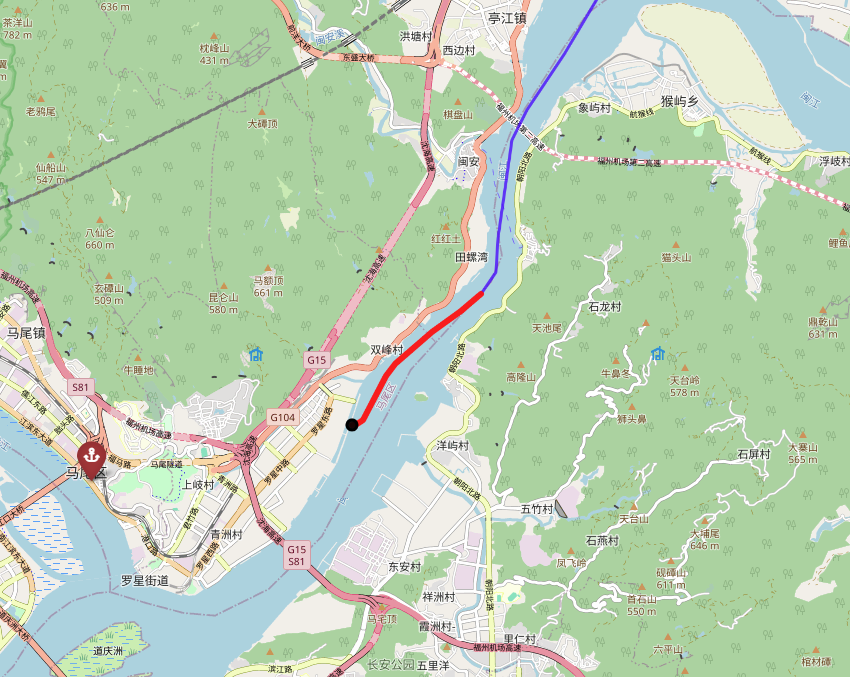

#### 判定準則:距離最後一個訊號點300m內

In [6]:
import numpy as np
import pandas as pd

def _haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000.0
    phi1 = np.radians(lat1); phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi/2.0)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlmb/2.0)**2
    return float(2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a)))

def edge_guard_drop_events_by_event_endpoint_distance(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    events_df: pd.DataFrame,
    *,
    dist_m: float = 300.0,
    time_col: str = "Timestamp",
    lat_col: str = "Lat",
    lon_col: str = "Long",
    voyage_id_col: str = "voyage_id",
    dep_col: str = "t_depart_origin",
    arr_col: str = "t_arrive_dest",
    ev_start_col: str = "t_start",
    ev_end_col: str = "t_end",
    duration_col: str = "duration_sec",
    out_total_col: str = "total_loitering_sec",
    out_cnt_col: str = "loitering_events_count",
):
    """
    Edge-guard by geometry:
    - 事件終點座標 = 事件區間內「最後一筆 AIS 點」
    - 航程起點/迄點座標 = 航程時間窗內「第一/最後一筆 AIS 點」
    - 若 min(dist(event_end, voy_start), dist(event_end, voy_end)) <= dist_m => drop
    回傳：events_kept, events_dropped, voyages_updated(回填 out_total_col/out_cnt_col)
    """
    # ---- empty guard ----
    v_upd = voyages_df.copy()
    if events_df is None or not isinstance(events_df, pd.DataFrame) or events_df.empty:
        v_upd[out_total_col] = 0.0
        v_upd[out_cnt_col] = 0
        empty = pd.DataFrame(columns=list(events_df.columns) if isinstance(events_df, pd.DataFrame) else [])
        return empty.copy(), empty.copy(), v_upd

    d = df_points.copy()
    v = voyages_df.copy()
    e = events_df.copy()

    # ---- normalize datetime ----
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")
    v[dep_col]  = pd.to_datetime(v[dep_col], errors="coerce")
    v[arr_col]  = pd.to_datetime(v[arr_col], errors="coerce")
    e[ev_start_col] = pd.to_datetime(e[ev_start_col], errors="coerce")
    e[ev_end_col]   = pd.to_datetime(e[ev_end_col], errors="coerce")

    # ---- minimal columns check ----
    for c in [time_col, lat_col, lon_col]:
        if c not in d.columns:
            raise KeyError(f"df_points missing column: {c}")
    for c in [voyage_id_col, dep_col, arr_col]:
        if c not in v.columns:
            raise KeyError(f"voyages_df missing column: {c}")
    for c in [voyage_id_col, ev_start_col, ev_end_col]:
        if c not in e.columns:
            raise KeyError(f"events_df missing column: {c}")

    # ---- clean inputs ----
    d = d.dropna(subset=[time_col, lat_col, lon_col]).sort_values(time_col).copy()

    v2 = v[[voyage_id_col, dep_col, arr_col]].copy()
    v2[voyage_id_col] = pd.to_numeric(v2[voyage_id_col], errors="coerce")
    v2 = v2.dropna(subset=[voyage_id_col, dep_col, arr_col]).copy()
    v2 = v2[v2[arr_col] > v2[dep_col]].copy()
    v2[voyage_id_col] = v2[voyage_id_col].astype(int)

    e[voyage_id_col] = pd.to_numeric(e[voyage_id_col], errors="coerce")
    e = e.dropna(subset=[voyage_id_col, ev_start_col, ev_end_col]).copy()
    e[voyage_id_col] = e[voyage_id_col].astype(int)

    if e.empty:
        v_upd = v.copy()
        v_upd[out_total_col] = 0.0
        v_upd[out_cnt_col] = 0
        return e, e.iloc[0:0].copy(), v_upd

    # ---- cache per voyage ----
    vids = e[voyage_id_col].unique().tolist()
    vlook = v2[v2[voyage_id_col].isin(vids)].drop_duplicates(subset=[voyage_id_col], keep="first").copy()

    cache = {}  # vid -> dict(ts, lat, lon, start, end)
    for _, row in vlook.iterrows():
        vid = int(row[voyage_id_col])
        t0, t1 = row[dep_col], row[arr_col]
        seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].sort_values(time_col)
        if seg.empty:
            continue
        ts = seg[time_col].to_numpy(dtype="datetime64[ns]")
        lat = seg[lat_col].to_numpy(dtype=float)
        lon = seg[lon_col].to_numpy(dtype=float)
        cache[vid] = {
            "ts": ts, "lat": lat, "lon": lon,
            "start": (float(lat[0]), float(lon[0])),
            "end":   (float(lat[-1]), float(lon[-1])),
        }

    # ---- keep/drop ----
    keep = np.ones(len(e), dtype=bool)
    reasons = np.array([""] * len(e), dtype=object)
    dmin_arr = np.full(len(e), np.nan, dtype=float)

    e_ts = e[ev_start_col].to_numpy(dtype="datetime64[ns]")
    e_te = e[ev_end_col].to_numpy(dtype="datetime64[ns]")
    e_vid = e[voyage_id_col].to_numpy(dtype=int)

    for i in range(len(e)):
        vid = int(e_vid[i])
        if vid not in cache:
            continue

        ts = cache[vid]["ts"]
        lat = cache[vid]["lat"]
        lon = cache[vid]["lon"]
        (s_lat, s_lon) = cache[vid]["start"]
        (a_lat, a_lon) = cache[vid]["end"]

        t_start = e_ts[i]
        t_end   = e_te[i]
        if np.isnat(t_start) or np.isnat(t_end):
            continue

        # 事件區間內最後一點（ts <= t_end 的最後一筆）
        idx_end = np.searchsorted(ts, t_end, side="right") - 1
        if idx_end < 0:
            continue
        if ts[idx_end] < t_start:
            continue  # 事件區間內沒點，保守不 drop

        ev_lat = float(lat[idx_end])
        ev_lon = float(lon[idx_end])

        ds = _haversine_m(ev_lat, ev_lon, s_lat, s_lon)
        da = _haversine_m(ev_lat, ev_lon, a_lat, a_lon)
        dmin = min(ds, da)
        dmin_arr[i] = dmin

        if dmin <= float(dist_m):
            keep[i] = False
            reasons[i] = "event_end_within_edge_buffer"

    e = e.copy()
    e["edge_guard_status"] = np.where(keep, "kept", "dropped")
    e["edge_guard_reason"] = np.where(keep, "", reasons)
    e["edge_guard_min_dist_to_voy_edge_m"] = dmin_arr

    events_kept = e[keep].reset_index(drop=True)
    events_dropped = e[~keep].reset_index(drop=True)

    # ---- summarize back to voyages (NO merge -> no name collision) ----
    v_upd = v.copy()

    # 確保 duration_sec 存在
    ev2 = events_kept.copy()
    if duration_col not in ev2.columns:
        ev2[duration_col] = (ev2[ev_end_col] - ev2[ev_start_col]).dt.total_seconds().clip(lower=0)

    sum_sec = ev2.groupby(voyage_id_col)[duration_col].sum()
    cnt_evt = ev2.groupby(voyage_id_col)[duration_col].count()

    v_upd[voyage_id_col] = pd.to_numeric(v_upd[voyage_id_col], errors="coerce")
    v_upd[out_total_col] = v_upd[voyage_id_col].map(sum_sec).fillna(0.0)
    v_upd[out_cnt_col]   = v_upd[voyage_id_col].map(cnt_evt).fillna(0).astype(int)

    return events_kept, events_dropped, v_upd


# ===== 直接套用（300m）=====
voyages_df = voyages_with_waiting_enhanced.copy() if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting.copy()
if "loitering_events" not in globals():
    raise NameError("找不到 loitering_events（raw）。請先跑 loitering 偵測那格 cell。")
base_events = loitering_events

loitering_events_kept_300m, loitering_events_dropped_300m, voyages_with_waiting_edgeguarded_300m = \
    edge_guard_drop_events_by_event_endpoint_distance(
        df_points=df,
        voyages_df=voyages_df,
        events_df=base_events,
        dist_m=300.0
    )

print("edge-guard(300m) before:", len(base_events))
print("edge-guard(300m) kept  :", len(loitering_events_kept_300m))
print("edge-guard(300m) drop  :", len(loitering_events_dropped_300m))


edge-guard(300m) before: 455
edge-guard(300m) kept  : 370
edge-guard(300m) drop  : 85


#### 判定準則: 異常事件中包含最後三個ais點

In [7]:
import numpy as np
import pandas as pd

def _summarize_loitering_to_voyages_no_suffix(
    voyages_df: pd.DataFrame,
    events_df: pd.DataFrame,
    *,
    voyage_id_col="voyage_id",
    event_start_col="t_start",
    event_end_col="t_end",
    out_total_col="total_loitering_sec",
    out_cnt_col="loitering_events_count",
):
    vw = voyages_df.copy()

    # 避免 merge 產生 _x/_y
    for c in [out_total_col, out_cnt_col]:
        if c in vw.columns:
            vw = vw.drop(columns=c)

    # 沒事件就補 0
    if events_df is None or (isinstance(events_df, pd.DataFrame) and events_df.empty):
        vw[out_total_col] = 0.0
        vw[out_cnt_col] = 0
        return vw

    ev = events_df.copy()
    ev[voyage_id_col] = pd.to_numeric(ev[voyage_id_col], errors="coerce").astype("Int64")
    ev[event_start_col] = pd.to_datetime(ev[event_start_col], errors="coerce")
    ev[event_end_col]   = pd.to_datetime(ev[event_end_col], errors="coerce")
    ev = ev.dropna(subset=[voyage_id_col, event_start_col, event_end_col]).copy()

    if ev.empty:
        vw[out_total_col] = 0.0
        vw[out_cnt_col] = 0
        return vw

    if "duration_sec" not in ev.columns:
        ev["duration_sec"] = (ev[event_end_col] - ev[event_start_col]).dt.total_seconds().clip(lower=0)

    g = ev.groupby(voyage_id_col)["duration_sec"].agg(["sum", "count"]).reset_index()
    g = g.rename(columns={"sum": out_total_col, "count": out_cnt_col})

    vw[voyage_id_col] = pd.to_numeric(vw[voyage_id_col], errors="coerce").astype("Int64")
    vw = vw.merge(g, on=voyage_id_col, how="left")
    vw[out_total_col] = vw[out_total_col].fillna(0.0)
    vw[out_cnt_col]   = vw[out_cnt_col].fillna(0).astype(int)
    return vw


def edge_guard_loitering_events_by_first_last_k_points(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    events_df: pd.DataFrame,
    k: int = 3,
    time_col: str = "Timestamp",
    dep_col: str = "t_depart_origin",
    arr_col: str = "t_arrive_dest",
    voyage_id_col: str = "voyage_id",
    event_start_col: str = "t_start",
    event_end_col: str = "t_end",
):
    # --- 空事件 ---
    if events_df is None or not isinstance(events_df, pd.DataFrame) or events_df.empty:
        v_upd = voyages_df.copy()
        v_upd = _summarize_loitering_to_voyages_no_suffix(v_upd, pd.DataFrame(), voyage_id_col=voyage_id_col,
                                                         event_start_col=event_start_col, event_end_col=event_end_col)
        empty = events_df.copy() if isinstance(events_df, pd.DataFrame) else pd.DataFrame()
        return empty, empty.iloc[0:0].copy(), v_upd

    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    v = voyages_df.copy()
    v[dep_col] = pd.to_datetime(v[dep_col], errors="coerce")
    v[arr_col] = pd.to_datetime(v[arr_col], errors="coerce")
    v[voyage_id_col] = pd.to_numeric(v[voyage_id_col], errors="coerce").astype("Int64")

    e = events_df.copy()
    e[event_start_col] = pd.to_datetime(e[event_start_col], errors="coerce")
    e[event_end_col]   = pd.to_datetime(e[event_end_col], errors="coerce")
    e[voyage_id_col]   = pd.to_numeric(e[voyage_id_col], errors="coerce").astype("Int64")

    e = e.dropna(subset=[voyage_id_col, event_start_col, event_end_col]).copy()
    if e.empty:
        v_upd = _summarize_loitering_to_voyages_no_suffix(v, e, voyage_id_col=voyage_id_col,
                                                         event_start_col=event_start_col, event_end_col=event_end_col)
        return e, e.iloc[0:0].copy(), v_upd

    # 只處理 events 出現過的 voyage_id
    vids = e[voyage_id_col].dropna().astype(int).unique().tolist()

    # vid -> (head_min, head_max, tail_min, tail_max)
    edge_ranges = {}
    for vid in vids:
        rows = v[v[voyage_id_col] == vid]
        if rows.empty:
            continue
        row = rows.iloc[0]
        t0, t1 = row[dep_col], row[arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].dropna(subset=[time_col]).sort_values(time_col)
        if len(seg) == 0:
            continue

        head = seg.head(k)[time_col].to_list()
        tail = seg.tail(k)[time_col].to_list()
        edge_ranges[int(vid)] = (min(head), max(head), min(tail), max(tail))

    def _overlap(a0, a1, b0, b1):
        return (a0 <= b1) and (a1 >= b0)

    keep_mask = []
    for _, r in e.iterrows():
        vid = int(r[voyage_id_col])
        if vid not in edge_ranges:
            keep_mask.append(True)
            continue

        h0, h1, t0, t1 = edge_ranges[vid]
        es, ee = r[event_start_col], r[event_end_col]
        hit_head = _overlap(es, ee, h0, h1)
        hit_tail = _overlap(es, ee, t0, t1)
        keep_mask.append(not (hit_head or hit_tail))

    keep_mask = np.array(keep_mask, dtype=bool)
    events_kept = e.loc[keep_mask].copy().reset_index(drop=True)
    events_dropped = e.loc[~keep_mask].copy().reset_index(drop=True)

    # 回填 voyages（不產生 _x/_y）
    v_upd = _summarize_loitering_to_voyages_no_suffix(
        v, events_kept,
        voyage_id_col=voyage_id_col,
        event_start_col=event_start_col,
        event_end_col=event_end_col,
        out_total_col="total_loitering_sec",
        out_cnt_col="loitering_events_count",
    )

    return events_kept, events_dropped, v_upd


# === 套用：包含起/迄點前後 3 點 ===
voyages_df = voyages_with_waiting_enhanced.copy() if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting.copy()

#  建議：edge-guard 最好吃「raw events」（merge 前）
# 如果你真的要 guard merged 也可以，把 base_events 改成 loitering_events_merged
base_events = loitering_events

loitering_events_kept_3pts, loitering_events_dropped_3pts, voyages_with_waiting_edgeguarded_3pts = \
    edge_guard_loitering_events_by_first_last_k_points(
        df_points=df,
        voyages_df=voyages_df,
        events_df=base_events,
        k=3
    )

print("edge-guard(前後3點) before:", len(base_events))
print("edge-guard(前後3點) kept  :", len(loitering_events_kept_3pts))
print("edge-guard(前後3點) drop  :", len(loitering_events_dropped_3pts))

display(voyages_with_waiting_edgeguarded_3pts[["voyage_id","total_loitering_sec","loitering_events_count"]].head())


edge-guard(前後3點) before: 455
edge-guard(前後3點) kept  : 294
edge-guard(前後3點) drop  : 161


,voyage_id,total_loitering_sec,loitering_events_count
0,1,1560.0,2
1,2,0.0,0
2,3,0.0,0
3,4,10320.0,7
4,5,0.0,0


In [8]:
VIDS = list(range(51, 100))

voyages_df = voyages_with_waiting_edgeguarded_3pts

#  強制用 kept（不吃 merged）
events_df = loitering_events = loitering_events_kept_3pts

m = visualize_voyages_with_loitering_and_anchorage(
    df=df,
    voyages_df=voyages_df,
    loitering_events=events_df,
    stops_labeled=stops_labeled,
    ports_df=ports_df,
    voyage_ids=VIDS,
    output_html="outputs/voyages_loitering_anchorage_map.html",
    sailing_color="blue",
    anch_color="orange",
    loiter_color="red",
    zoom_start=6,
)


已輸出地圖到 C:\Users\slab\Desktop\Slab Project\Stage2 ETA\outputs\voyages_loitering_anchorage_map.html


#### 合併異常航行事件

In [9]:
import numpy as np
import pandas as pd
from math import radians, sin, cos, atan2, sqrt

# -----------------------
# helpers
# -----------------------
def _to_lon180(dlon):
    return ((dlon + 180.0) % 360.0) - 180.0

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlmb = radians(_to_lon180(lon2 - lon1))
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlmb/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

def segment_r95_km(seg: pd.DataFrame, lat_col="Lat", lon_col="Long"):
    if seg.empty:
        return np.nan
    lat = pd.to_numeric(seg[lat_col], errors="coerce").to_numpy()
    lon = pd.to_numeric(seg[lon_col], errors="coerce").to_numpy()
    lat_med = np.nanmedian(lat)
    lon_med = np.nanmedian(lon)
    d = np.array([haversine_km(lat_med, lon_med, a, b) for a, b in zip(lat, lon)], dtype=float)
    d = d[np.isfinite(d)]
    if d.size == 0:
        return np.nan
    return float(np.percentile(d, 95))

def _ensure_datetime(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

# -----------------------
# core
# -----------------------
def merge_loitering_events_by_compactness(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    events_df: pd.DataFrame,
    *,
    time_col="Timestamp", lat_col="Lat", lon_col="Long",
    dep_col="t_depart_origin", arr_col="t_arrive_dest",
    voyage_id_col="voyage_id",
    event_id_col="event_id",
    ev_start_col="t_start", ev_end_col="t_end",
    merge_r95_max_km: float | None = None,
    max_event_hr: float | None = None,
    max_gap_hr: float = 24.0,
    min_points_in_span: int = 5,
):
    """
    將 loitering events（建議：已做完 3pt edge-guard 的 kept events）
    依「同一區域緊湊性」合併：
      - gap <= max_gap_hr
      - 合併後時間跨度 <= max_event_hr
      - 合併後 r95 <= merge_r95_max_km 且 span 點數 >= min_points_in_span
    並回填每個 voyage 的 total_loitering_sec / loitering_events_count（不要求 voyage 原本有欄位）
    """
    # points
    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")
    d = d.dropna(subset=[time_col]).sort_values(time_col)

    # voyages
    v = voyages_df.copy()
    v = _ensure_datetime(v, [dep_col, arr_col])
    if voyage_id_col not in v.columns:
        raise KeyError(f"voyages_df missing column: {voyage_id_col}")

    # events
    e = events_df.copy() if isinstance(events_df, pd.DataFrame) else pd.DataFrame()

    # empty -> return safe outputs
    if e.empty:
        merged = pd.DataFrame(columns=[
            "event_id", voyage_id_col, ev_start_col, ev_end_col, "duration_sec",
            "anomaly_type", "r95_km", "n_points", "merged_from_event_ids"
        ])
        v_out = v.copy()
        # 每次都覆蓋建立，避免 KeyError
        v_out["total_loitering_sec"] = 0.0
        v_out["loitering_events_count"] = 0
        return merged, v_out

    # ensure datetime
    e = _ensure_datetime(e, [ev_start_col, ev_end_col])

    # try to attach voyage_id if missing
    if voyage_id_col not in e.columns:
        e[voyage_id_col] = np.nan
        mids = pd.to_datetime(e[ev_start_col], errors="coerce") + (
            pd.to_datetime(e[ev_end_col], errors="coerce") - pd.to_datetime(e[ev_start_col], errors="coerce")
        ) / 2
        for idx, mid in zip(e.index, mids):
            if pd.isna(mid):
                continue
            hit = v[(v[dep_col] <= mid) & (v[arr_col] >= mid)]
            if not hit.empty:
                e.at[idx, voyage_id_col] = hit.iloc[0][voyage_id_col]

    # sanitize
    e = e.dropna(subset=[voyage_id_col, ev_start_col, ev_end_col]).copy()
    e[voyage_id_col] = pd.to_numeric(e[voyage_id_col], errors="coerce")
    e = e.dropna(subset=[voyage_id_col]).copy()
    e[voyage_id_col] = e[voyage_id_col].astype(int)

    # event_id fallback
    if event_id_col not in e.columns:
        e[event_id_col] = np.arange(1, len(e) + 1)

    # defaults
    if merge_r95_max_km is None:
        merge_r95_max_km = 10.0

    if max_event_hr is None:
        if "duration_sec" in e.columns and len(e) >= 5:
            dur_hr = pd.to_numeric(e["duration_sec"], errors="coerce") / 3600.0
            base = float(dur_hr.quantile(0.95)) if dur_hr.notna().any() else 6.0
            max_event_hr = float(np.clip(base * 3.0, 6.0, 48.0))
        else:
            max_event_hr = 24.0

    merged_rows = []

    # per voyage
    for vid, evs in e.sort_values([voyage_id_col, ev_start_col]).groupby(voyage_id_col):
        evs = evs.sort_values(ev_start_col).reset_index(drop=True)

        vrow = v[v[voyage_id_col] == vid]
        if vrow.empty:
            continue
        t0 = vrow.iloc[0][dep_col]
        t1 = vrow.iloc[0][arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        seg_v = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy()
        seg_v = seg_v.sort_values(time_col)
        if seg_v.empty:
            continue

        cur_start = pd.to_datetime(evs.loc[0, ev_start_col])
        cur_end   = pd.to_datetime(evs.loc[0, ev_end_col])
        member_ids = [int(evs.loc[0, event_id_col])]

        def _span_r95(a, b):
            sub = seg_v[(seg_v[time_col] >= a) & (seg_v[time_col] <= b)]
            return segment_r95_km(sub, lat_col=lat_col, lon_col=lon_col), len(sub)

        for j in range(1, len(evs)):
            ns = pd.to_datetime(evs.loc[j, ev_start_col])
            ne = pd.to_datetime(evs.loc[j, ev_end_col])
            if pd.isna(ns) or pd.isna(ne):
                continue

            gap_hr = (ns - cur_end).total_seconds() / 3600.0

            # too far -> flush
            if gap_hr > max_gap_hr:
                merged_rows.append({
                    voyage_id_col: vid,
                    ev_start_col: cur_start,
                    ev_end_col: cur_end,
                    "duration_sec": (cur_end - cur_start).total_seconds(),
                    "merged_from_event_ids": member_ids,
                })
                cur_start, cur_end = ns, ne
                member_ids = [int(evs.loc[j, event_id_col])]
                continue

            cand_start, cand_end = cur_start, max(cur_end, ne)
            dur_hr = (cand_end - cand_start).total_seconds() / 3600.0

            if dur_hr > max_event_hr:
                merged_rows.append({
                    voyage_id_col: vid,
                    ev_start_col: cur_start,
                    ev_end_col: cur_end,
                    "duration_sec": (cur_end - cur_start).total_seconds(),
                    "merged_from_event_ids": member_ids,
                })
                cur_start, cur_end = ns, ne
                member_ids = [int(evs.loc[j, event_id_col])]
                continue

            r95, npts = _span_r95(cand_start, cand_end)

            if np.isfinite(r95) and (r95 <= merge_r95_max_km) and (npts >= min_points_in_span):
                cur_end = cand_end
                member_ids.append(int(evs.loc[j, event_id_col]))
            else:
                merged_rows.append({
                    voyage_id_col: vid,
                    ev_start_col: cur_start,
                    ev_end_col: cur_end,
                    "duration_sec": (cur_end - cur_start).total_seconds(),
                    "merged_from_event_ids": member_ids,
                })
                cur_start, cur_end = ns, ne
                member_ids = [int(evs.loc[j, event_id_col])]

        merged_rows.append({
            voyage_id_col: vid,
            ev_start_col: cur_start,
            ev_end_col: cur_end,
            "duration_sec": (cur_end - cur_start).total_seconds(),
            "merged_from_event_ids": member_ids,
        })

    merged = pd.DataFrame(merged_rows)

    # still empty -> safe return
    if merged.empty:
        merged = pd.DataFrame(columns=[
            "event_id", voyage_id_col, ev_start_col, ev_end_col, "duration_sec",
            "anomaly_type", "r95_km", "n_points", "merged_from_event_ids"
        ])
        v_out = v.copy()
        v_out["total_loitering_sec"] = 0.0
        v_out["loitering_events_count"] = 0
        return merged, v_out

    merged = merged.sort_values([voyage_id_col, ev_start_col]).reset_index(drop=True)
    merged["event_id"] = np.arange(1, len(merged) + 1)
    merged["anomaly_type"] = "loitering_merged"

    # compute merged r95 / n_points
    r95_list, npts_list = [], []
    for _, row in merged.iterrows():
        vid = int(row[voyage_id_col])
        vrow = v[v[voyage_id_col] == vid]
        if vrow.empty:
            r95_list.append(np.nan); npts_list.append(0); continue
        t0 = vrow.iloc[0][dep_col]
        t1 = vrow.iloc[0][arr_col]
        seg_v = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy()
        sub = seg_v[(seg_v[time_col] >= row[ev_start_col]) & (seg_v[time_col] <= row[ev_end_col])]
        npts_list.append(int(len(sub)))
        r95_list.append(segment_r95_km(sub, lat_col=lat_col, lon_col=lon_col))

    merged["n_points"] = npts_list
    merged["r95_km"] = r95_list

    # --- summarize back to voyages (safe, no KeyError) ---
    v_out = v.copy()

    # 永遠先清掉舊 summary 欄，避免 _x/_y 與 KeyError
    v_out = v_out.drop(columns=[
        "total_loitering_sec", "loitering_events_count",
        "total_loitering_sec_x", "total_loitering_sec_y",
        "loitering_events_count_x", "loitering_events_count_y",
    ], errors="ignore")

    agg = merged.groupby(voyage_id_col)["duration_sec"].agg(["sum", "count"]).reset_index()
    agg = agg.rename(columns={"sum": "total_loitering_sec", "count": "loitering_events_count"})

    v_out = v_out.merge(agg, on=voyage_id_col, how="left")
    v_out["total_loitering_sec"] = v_out["total_loitering_sec"].fillna(0.0)
    v_out["loitering_events_count"] = v_out["loitering_events_count"].fillna(0).astype(int)

    return merged, v_out


# -----------------------
# RUN (改成吃 3pt edge-guard 後的 events)
# -----------------------
df_points = df
vw = voyages_with_waiting_enhanced.copy() if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting.copy()

#  正確：merge 前先 edge-guard，所以這裡優先用 3pt kept events
if "loitering_events_kept_3pts" in globals():
    base_events_for_merge = loitering_events_kept_3pts
elif "loitering_events_kept" in globals():
    base_events_for_merge = loitering_events_kept
else:
    # 退而求其次：你手上現成的（但建議你確定它是 edge-guard 後的）
    base_events_for_merge = loitering_events

loitering_events_merged, voyages_with_waiting_merged = merge_loitering_events_by_compactness(
    df_points=df_points,
    voyages_df=vw,
    events_df=base_events_for_merge,
    merge_r95_max_km=10.0,
    max_event_hr=24.0,
    max_gap_hr=24.0,
)

display(loitering_events_merged.head(10))
display(voyages_with_waiting_merged[["voyage_id","total_loitering_sec","loitering_events_count"]].head(10))


,voyage_id,t_start,t_end,duration_sec,merged_from_event_ids,event_id,anomaly_type,n_points,r95_km
0,1,2025-01-01 12:17:19,2025-01-01 12:31:19,840.0,[2],1,loitering_merged,8,1.255442
1,1,2025-01-01 22:35:19,2025-01-01 22:47:19,720.0,[3],2,loitering_merged,7,1.167740
2,4,2025-01-07 16:15:42,2025-01-08 06:09:42,50040.0,"[7, 8, 9, 10, 11, 12, 13]",3,loitering_merged,341,0.101904
3,6,2025-01-12 08:58:00,2025-01-12 09:14:00,960.0,[15],4,loitering_merged,8,0.010450
4,7,2025-01-13 21:56:06,2025-01-13 22:36:06,2400.0,"[17, 18]",5,loitering_merged,11,2.092467
5,9,2025-01-16 23:46:09,2025-01-17 23:34:09,85680.0,"[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 3...",6,loitering_merged,519,0.455727
6,9,2025-01-18 00:12:09,2025-01-18 02:12:09,7200.0,"[37, 38, 39, 40]",7,loitering_merged,60,5.208899
7,10,2025-01-21 23:32:07,2025-01-22 03:12:07,13200.0,"[43, 44, 45]",8,loitering_merged,108,9.452717
8,10,2025-01-22 04:58:07,2025-01-22 05:16:07,1080.0,[46],9,loitering_merged,10,0.863983
9,12,2025-01-25 10:26:04,2025-01-25 11:20:04,3240.0,[50],10,loitering_merged,27,2.461402


,voyage_id,total_loitering_sec,loitering_events_count
0,1,1560.0,2
1,2,0.0,0
2,3,0.0,0
3,4,50040.0,1
4,5,0.0,0
5,6,960.0,1
6,7,2400.0,1
7,8,0.0,0
8,9,92880.0,2
9,10,14280.0,2


In [10]:
VIDS = list(range(1, 100))

m = visualize_voyages_with_loitering_and_anchorage(
    df=df,
    voyages_df=voyages_with_waiting_merged,
    loitering_events=loitering_events_merged,
    stops_labeled=stops_labeled,
    ports_df=ports_df,
    voyage_ids=VIDS,
    output_html="outputs/voyages_loitering_anchorage_map.html",
    sailing_color="blue",
    anch_color="orange",
    loiter_color="red",
    zoom_start=6,
)

已輸出地圖到 C:\Users\slab\Desktop\Slab Project\Stage2 ETA\outputs\voyages_loitering_anchorage_map.html


#### 異常航行區塊檢查-- V/t圖

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_voyage_sog_with_loitering_boxes(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    loitering_events: pd.DataFrame,
    voyage_id: int,
    *,
    # 基本欄位
    time_col="Timestamp",
    sog_col="Sog",
    dep_col="t_depart_origin",
    arr_col="t_arrive_dest",
    voyage_id_col="voyage_id",

    # loitering 事件欄位
    ev_start_col="t_start",
    ev_end_col="t_end",

    # ✅ 新增：anchorage_like 相關參數
    anchorage_stops: pd.DataFrame | None = None,
    anch_start_col="t_start",
    anch_end_col="t_end",
    stop_type_col="stop_type",
    anchorage_label="anchorage_like",

    title_prefix="",
    figsize=(14, 4),
    box_alpha=0.15,
    box_linewidth=2.0,
    anch_box_alpha=0.12,
    anch_box_linewidth=2.0,
):
    """
    畫指定 voyage 的 SOG vs Time：
    - loitering events：紅色半透明框
    - anchorage_like episodes：黃色半透明框

    參數說明：
    - df_points: AIS 點 df（含 Timestamp, Sog）
    - voyages_df: voyages_with_waiting(_enhanced / _merged 都可)
    - loitering_events: loitering_events_merged / loitering_events_kept_3pts ...
    - anchorage_stops: 停泊 episode 表（例如 stops_labeled / stops_merged），
                       需要至少包含 [t_start, t_end, stop_type]，有 voyage_id 更好但不是必須
    """
    # ----------------------------
    # 1) 準備 AIS 點與 voyage 時間窗
    # ----------------------------
    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    v = voyages_df.copy()
    v[dep_col] = pd.to_datetime(v[dep_col], errors="coerce")
    v[arr_col] = pd.to_datetime(v[arr_col], errors="coerce")

    row = v.loc[pd.to_numeric(v[voyage_id_col], errors="coerce") == int(voyage_id)]
    if row.empty:
        print(f"[WARN] voyages_df 找不到 voyage_id={voyage_id}")
        return
    row = row.iloc[0]
    t0, t1 = row[dep_col], row[arr_col]
    if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
        print(f"[WARN] voyage_id={voyage_id} 的時間窗不合法 (t0/t1)")
        return

    seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy().sort_values(time_col)
    if seg.empty:
        print(f"[WARN] voyage_id={voyage_id} 時間窗內沒有 AIS 點")
        return

    if sog_col not in seg.columns:
        print(f"[WARN] df_points 沒有欄位 {sog_col}")
        return

    seg["_sog"] = pd.to_numeric(seg[sog_col], errors="coerce")

    # ----------------------------
    # 2) 準備 loitering events
    # ----------------------------
    evs = loitering_events.copy() if isinstance(loitering_events, pd.DataFrame) else pd.DataFrame()
    if not evs.empty:
        if voyage_id_col not in evs.columns:
            print("[WARN] loitering_events 沒有 voyage_id 欄位，無法對應到此航程")
            evs = pd.DataFrame()
        else:
            evs[ev_start_col] = pd.to_datetime(evs[ev_start_col], errors="coerce")
            evs[ev_end_col]   = pd.to_datetime(evs[ev_end_col], errors="coerce")
            evs = evs.loc[pd.to_numeric(evs[voyage_id_col], errors="coerce") == int(voyage_id)]
            evs = evs.dropna(subset=[ev_start_col, ev_end_col]).sort_values(ev_start_col)

    # ----------------------------
    # 3) ✅ 準備 anchorage_like episodes
    # ----------------------------
    anch = anchorage_stops.copy() if isinstance(anchorage_stops, pd.DataFrame) else pd.DataFrame()
    if not anch.empty:
        # 轉時間
        anch[anch_start_col] = pd.to_datetime(anch[anch_start_col], errors="coerce")
        anch[anch_end_col]   = pd.to_datetime(anch[anch_end_col], errors="coerce")

        # 只留 anchorage_like
        if stop_type_col in anch.columns:
            anch = anch[anch[stop_type_col] == anchorage_label]

        # 若有 voyage_id 欄位，就順便用 voyage_id 篩一次（比較精準）
        if voyage_id_col in anch.columns:
            anch = anch.loc[pd.to_numeric(anch[voyage_id_col], errors="coerce") == int(voyage_id)]

        # 再限制在此 voyage 的時間窗附近（有些 anchorage episode 可能跨航程）
        anch = anch.dropna(subset=[anch_start_col, anch_end_col])
        # 保留與 [t0, t1] 有重疊的 episode
        anch = anch[(anch[anch_end_col] >= t0) & (anch[anch_start_col] <= t1)]
        anch = anch.sort_values(anch_start_col)

    # ----------------------------
    # 4) 繪圖
    # ----------------------------
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(seg[time_col], seg["_sog"], linewidth=1)

    ax.set_title(f"{title_prefix}Voyage {voyage_id} - SOG over time "
                 "(yellow = anchorage_like, red box = loitering)")
    ax.set_xlabel("Time")
    ax.set_ylabel("SOG (knots)")
    ax.grid(True, alpha=0.3)

    # 先記住原始 y 範圍，避免 axvspan 觸發 autoscale 改變
    ymin, ymax = ax.get_ylim()

    # 4.1 ✅ anchorage_like：黃色背景（比較淡）
    if not anch.empty:
        for _, e in anch.iterrows():
            a, b = e[anch_start_col], e[anch_end_col]
            if b <= a:
                continue
            # clamp 到航程時間窗
            a2 = max(a, seg[time_col].min())
            b2 = min(b, seg[time_col].max())
            if b2 <= a2:
                continue

            ax.axvspan(
                a2, b2,
                alpha=anch_box_alpha,
                edgecolor="goldenrod",
                linewidth=anch_box_linewidth,
                facecolor="yellow",
            )

    # 4.2 loitering：紅色框 + 淡紅底
    if not evs.empty:
        for _, e in evs.iterrows():
            a, b = e[ev_start_col], e[ev_end_col]
            if b <= a:
                continue
            # clamp 到航程時間窗
            a2 = max(a, seg[time_col].min())
            b2 = min(b, seg[time_col].max())
            if b2 <= a2:
                continue

            ax.axvspan(
                a2, b2,
                alpha=box_alpha,
                edgecolor="black",
                linewidth=box_linewidth,
                facecolor="red",  # 你不想要紅底也可以改成 None
            )

    # 把 y 軸恢復到原本（避免 autoscale 被 span 影響）
    ax.set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.show()



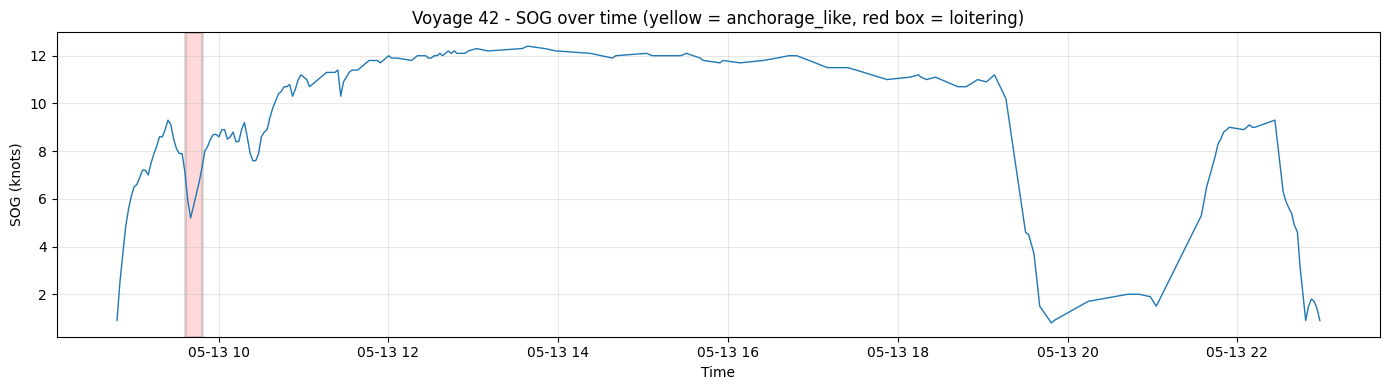

In [ ]:
voyage_id_to_check = 42

vw = voyages_with_waiting_merged if "voyages_with_waiting_merged" in globals() else \
     (voyages_with_waiting_enhanced if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting)

ev = loitering_events_merged if "loitering_events_merged" in globals() else \
     (loitering_events_kept_3pts if "loitering_events_kept_3pts" in globals() else loitering_events)

#  新增：stops 表（含 anchorage_like）
stops_for_plot = stops_labeled if "stops_labeled" in globals() else None

plot_voyage_sog_with_loitering_boxes(
    df_points=df,
    voyages_df=vw,
    loitering_events=ev,
    anchorage_stops=stops_for_plot,   # 傳進去就會畫 anchorage_like
    voyage_id=voyage_id_to_check,
    title_prefix="",
)

### 12/01 目前全部pipeline

In [74]:
# =========================
# main.py in Jupyter cell（整合版 - smart teleport + 港到港 + robust停泊分類）
# =========================

from pathlib import Path
import webbrowser

import numpy as np
import pandas as pd
from haversine import haversine

# 匯入自訂模組
from data_loader import load_and_preprocess
from voyage_splitter import (
    detect_stops,
    split_voyages,
    voyage_quality_checker,
    _safe_haversine,   # 小工具：改經度範圍後的 haversine
)
from visualization import visualize_voyages
from od_marker import assign_ports
from Trajectory_Recon import TrajectoryReconstructor
from data_quality import voyage_integrity_metrics


# ----------------------------
# 0. 基本設定
# ----------------------------
csv_path = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "477300400_VesselHistoryLineInfo.csv"
target_mmsi = 477300400

# 港口清單路徑：filtered_ports.csv，欄位為 unlocode, lat, lon
ports_csv = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "filtered_ports.csv"


# ----------------------------
# 0.5  移除雜訊點（teleport）- smart 迭代版
# ----------------------------

def remove_teleport_points(
    df: pd.DataFrame,
    speed_kn_th: float = 50.0,
    dt_max_sec: float = 3600.0,
    keep_report: bool = True
):
    """
    移除 AIS 瞬移點（teleport）
    - Rule A（三點檢查，中間點）：prev->cur 爆速 且 prev->next 合理 => 刪 cur
    - Rule B（開頭邊界點）：cur->next 爆速 且 next->next 正常 => 刪 cur
    - Rule C（結尾邊界點）：prev->cur 爆速 且 prev->prev 正常 => 刪 cur

    需要欄位：Timestamp, Lat, Long
    回傳：df_clean, report_df
    """
    d = df.sort_values("Timestamp").copy()

    # 避免你 df 本來就有 orig_index 造成重複欄位
    if "orig_index" in d.columns:
        d = d.rename(columns={"orig_index": "orig_index_old"})
    d = d.reset_index(drop=False).rename(columns={"index": "orig_index"})

    # prev/next
    d["Lat_prev"]   = d["Lat"].shift(1)
    d["Long_prev"]  = d["Long"].shift(1)
    d["T_prev"]     = d["Timestamp"].shift(1)

    d["Lat_next"]   = d["Lat"].shift(-1)
    d["Long_next"]  = d["Long"].shift(-1)
    d["T_next"]     = d["Timestamp"].shift(-1)

    d["Lat_next2"]  = d["Lat"].shift(-2)
    d["Long_next2"] = d["Long"].shift(-2)
    d["T_next2"]    = d["Timestamp"].shift(-2)

    d["Lat_prev2"]  = d["Lat"].shift(2)
    d["Long_prev2"] = d["Long"].shift(2)
    d["T_prev2"]    = d["Timestamp"].shift(2)

    # dt
    d["dt_prev_sec"]     = (d["Timestamp"] - d["T_prev"]).dt.total_seconds()
    d["dt_next_sec"]     = (d["T_next"] - d["Timestamp"]).dt.total_seconds()
    d["dt_prevnext_sec"] = (d["T_next"] - d["T_prev"]).dt.total_seconds()
    d["dt_next2_sec"]    = (d["T_next2"] - d["T_next"]).dt.total_seconds()
    d["dt_prev2_sec"]    = (d["T_prev"] - d["T_prev2"]).dt.total_seconds()

    # dist (km)
    def _dist_km(lat1, lon1, lat2, lon2):
        if np.any(pd.isna([lat1, lon1, lat2, lon2])):
            return np.nan
        return haversine((lat1, lon1), (lat2, lon2))

    d["dist_prev_km"]     = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_prev"],  d["Long_prev"],  d["Lat"],      d["Long"])]
    d["dist_next_km"]     = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat"],       d["Long"],       d["Lat_next"], d["Long_next"])]
    d["dist_prevnext_km"] = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_prev"],  d["Long_prev"],  d["Lat_next"], d["Long_next"])]

    d["dist_next2_km"]    = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_next"],  d["Long_next"],  d["Lat_next2"], d["Long_next2"])]
    d["dist_prev2_km"]    = [_dist_km(a,b,c,e) for a,b,c,e in zip(d["Lat_prev2"], d["Long_prev2"], d["Lat_prev"],  d["Long_prev"])]

    # speed (kn)
    d["speed_prev_kn"]     = (d["dist_prev_km"] / (d["dt_prev_sec"] / 3600.0)) / 1.852
    d["speed_next_kn"]     = (d["dist_next_km"] / (d["dt_next_sec"] / 3600.0)) / 1.852
    d["speed_prevnext_kn"] = (d["dist_prevnext_km"] / (d["dt_prevnext_sec"] / 3600.0)) / 1.852
    d["speed_next2_kn"]    = (d["dist_next2_km"] / (d["dt_next2_sec"] / 3600.0)) / 1.852
    d["speed_prev2_kn"]    = (d["dist_prev2_km"] / (d["dt_prev2_sec"] / 3600.0)) / 1.852

    # ---------- Rule A: 三點檢查刪中間點 ----------
    ruleA = (
        (d["dt_prev_sec"] > 0) & (d["dt_prev_sec"] <= dt_max_sec) &
        (d["speed_prev_kn"] > speed_kn_th) &
        (d["speed_prevnext_kn"].fillna(np.inf) <= speed_kn_th)
    )

    # ---------- Rule B: 開頭邊界離群點（刪當前點） ----------
    ruleB = (
        (d["dt_next_sec"] > 0) & (d["dt_next_sec"] <= dt_max_sec) &
        (d["speed_next_kn"] > speed_kn_th) &
        (d["speed_next2_kn"].fillna(np.inf) <= speed_kn_th)
    )

    # ---------- Rule C: 結尾邊界離群點（刪當前點） ----------
    ruleC = (
        (d["dt_prev_sec"] > 0) & (d["dt_prev_sec"] <= dt_max_sec) &
        (d["speed_prev_kn"] > speed_kn_th) &
        (d["speed_prev2_kn"].fillna(np.inf) <= speed_kn_th)
    )

    to_drop = (ruleA | ruleB | ruleC).fillna(False)

    reason = np.where(ruleA, "A_midpoint",
             np.where(ruleB, "B_head_outlier",
             np.where(ruleC, "C_tail_outlier", "")))
    report = d.loc[to_drop, ["orig_index","Timestamp","Lat","Long","speed_prev_kn","speed_next_kn"]].copy()
    report["reason"] = np.array(reason)[to_drop.to_numpy()]

    drop_cols = [
        "Lat_prev","Long_prev","T_prev",
        "Lat_next","Long_next","T_next",
        "Lat_next2","Long_next2","T_next2",
        "Lat_prev2","Long_prev2","T_prev2",
        "dt_prev_sec","dt_next_sec","dt_prevnext_sec","dt_next2_sec","dt_prev2_sec",
        "dist_prev_km","dist_next_km","dist_prevnext_km","dist_next2_km","dist_prev2_km",
        "speed_prev_kn","speed_next_kn","speed_prevnext_kn","speed_next2_kn","speed_prev2_kn"
    ]
    drop_cols = [c for c in drop_cols if c in d.columns]

    df_clean = d.loc[~to_drop, :].drop(columns=drop_cols).reset_index(drop=True)

    if keep_report:
        return df_clean, report
    return df_clean, None


def has_teleport_edges(df: pd.DataFrame, speed_kn_th: float = 50.0, dt_max_sec: float = 3600.0) -> bool:
    if df.empty or len(df) < 2:
        return False

    d = df.sort_values("Timestamp")[["Timestamp","Lat","Long"]].copy()
    dt = d["Timestamp"].diff().dt.total_seconds()

    lat1 = d["Lat"].shift(1).to_numpy()
    lon1 = d["Long"].shift(1).to_numpy()
    lat2 = d["Lat"].to_numpy()
    lon2 = d["Long"].to_numpy()

    dist = np.full(len(d), np.nan, dtype=float)
    valid = (~np.isnan(lat1)) & (~np.isnan(lon1)) & (~np.isnan(lat2)) & (~np.isnan(lon2))
    idxs = np.where(valid)[0]
    for i in idxs:
        dist[i] = haversine((lat1[i], lon1[i]), (lat2[i], lon2[i]))  # km

    speed_kn = (dist / (dt.to_numpy() / 3600.0)) / 1.852
    mask = (dt.to_numpy() > 0) & (dt.to_numpy() <= dt_max_sec) & (speed_kn > speed_kn_th)
    return bool(np.nan_to_num(mask).any())


def remove_teleport_points_smart(
    df: pd.DataFrame,
    speed_kn_th: float = 50.0,
    dt_max_sec: float = 3600.0,
    max_iter: int = 8,
    verbose: bool = True
):
    d = df.copy()
    reports = []

    for it in range(max_iter):
        still_bad = has_teleport_edges(d, speed_kn_th=speed_kn_th, dt_max_sec=dt_max_sec)
        if not still_bad:
            if verbose:
                print(f"[teleport] stop at iter {it}: no suspect edges.")
            break

        d2, rep = remove_teleport_points(d, speed_kn_th=speed_kn_th, dt_max_sec=dt_max_sec, keep_report=True)
        n_drop = 0 if rep is None else len(rep)
        if verbose:
            print(f"[teleport] iter {it+1}: dropped {n_drop} points")

        if rep is None or n_drop == 0:
            break

        rep = rep.copy()
        rep["iter"] = it + 1
        reports.append(rep)
        d = d2

    report_all = pd.concat(reports, ignore_index=True) if reports else pd.DataFrame()
    return d, report_all


# ----------------------------
# 1. 載入 AIS & teleport 清洗 & 基礎停泊偵測
# ----------------------------
print("載入與前處理資料中...")
df = load_and_preprocess(csv_path, target_mmsi)
print(f"清理後資料筆數: {len(df)}")

print("移除瞬移(teleport)雜訊點（smart迭代：先掃描、有異常才跑下一輪）...")
df, teleport_report = remove_teleport_points_smart(
    df,
    speed_kn_th=50,
    dt_max_sec=3600,
    max_iter=8,
    verbose=True
)
print(f"刪除 teleport 點數量: {len(teleport_report)}")
print(f"清理後資料筆數(teleport 清除後): {len(df)}")

print("執行停泊判斷 (detect_stops)...")
stop_segments_initial = detect_stops(df)
print(f"偵測到停泊區段數量: {len(stop_segments_initial)}")


# ----------------------------
# 2. 傳統航程切分（供 QA / 地圖呈現）
# ----------------------------
print("\n[傳統] 切分航程（停泊→航行→停泊）...")
df_with_voyages, voyages_raw = split_voyages(df, stop_segments_initial)
print(f"切分後航程數量: {len(voyages_raw)}")

print("執行航程 QA 檢查...")
voyages_qc = voyage_quality_checker(
    df_with_voyages,
    voyages_raw,
    stop_segments=stop_segments_initial
)
print(f"QA 完成，有效航程數量: {voyages_qc['valid_flag'].sum()}")

print("輸出傳統航程地圖 voyages_map.html ...")
visualize_voyages(df_with_voyages, voyages_raw)
webbrowser.open("voyages_map.html")


# ============================
# 下方開始：新版「港到港＋錨泊/等待」流程
# ============================

# ----------------------------
# ★ Robust SOG stats：把最外側少量尖峰降噪後再算 std
# ----------------------------
def robust_sog_stats(sog_series: pd.Series, clip_pct: float = 2.5):
    """
    clip_pct=2.5 代表用中間 95% 做穩健估計（winsorize / trim）
    回傳：
      avg_sog
      sog_std            : 原始 std
      sog_p95            : 95分位（參考用）
      sog_std_w95        : winsorized std（建議拿來判 port_call）
      sog_std_trim95     : trimmed std（debug用）
    """
    x = pd.to_numeric(sog_series, errors="coerce").dropna().to_numpy()
    if len(x) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    avg = float(np.mean(x))
    std = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
    p95 = float(np.percentile(x, 95))

    lo = float(np.percentile(x, clip_pct))
    hi = float(np.percentile(x, 100 - clip_pct))

    x_w = np.clip(x, lo, hi)
    std_w95 = float(np.std(x_w, ddof=1)) if len(x_w) > 1 else 0.0

    x_t = x[(x >= lo) & (x <= hi)]
    std_trim95 = float(np.std(x_t, ddof=1)) if len(x_t) > 1 else 0.0

    return avg, std, p95, std_w95, std_trim95


# ----------------------------
# 3. 從 stop_segments_initial 建立停泊 episodes + 合併碎段
# ----------------------------
def build_raw_stop_episodes(df, stop_segments):
    """
    將 detect_stops 回傳的 stop_segments(list of range)
    轉成一個 DataFrame：每列是一個「原始停泊 episode」
    新增 robust 指標：sog_std_w95 / sog_std_trim95
    """
    records = []
    for seg_id, seg in enumerate(stop_segments, start=1):
        idxs = list(seg)
        if not idxs:
            continue

        start_idx = idxs[0]
        end_idx   = idxs[-1]
        t_start = df.loc[start_idx, "Timestamp"]
        t_end   = df.loc[end_idx, "Timestamp"]
        duration_sec = (t_end - t_start).total_seconds()

        lat_center = df.loc[idxs, "Lat"].median()
        lon_center = df.loc[idxs, "Long"].median()

        avg_sog, sog_std, sog_p95, sog_std_w95, sog_std_trim95 = robust_sog_stats(df.loc[idxs, "Sog"], clip_pct=2.5)

        distances = [
            _safe_haversine(
                (lat_center, lon_center),
                (df.loc[j, "Lat"], df.loc[j, "Long"])
            )
            for j in idxs
        ]
        radius_km = float(np.percentile(distances, 95)) if distances else 0.0

        records.append({
            "raw_stop_id": seg_id,
            "start_idx": start_idx,
            "end_idx": end_idx,
            "t_start": t_start,
            "t_end": t_end,
            "duration_sec": duration_sec,
            "center_lat": lat_center,
            "center_lon": lon_center,
            "avg_sog": avg_sog,
            "sog_std": sog_std,
            "sog_p95": sog_p95,
            "sog_std_w95": sog_std_w95,        # ★ 用這個來判 port_call
            "sog_std_trim95": sog_std_trim95,  # debug
            "radius_km": radius_km,
        })

    return pd.DataFrame(records)


def merge_stop_episodes(df,
                        stops_raw,
                        max_gap_sec=30*60,
                        max_center_dist_km=1.0,
                        max_move_duration_sec=30*60,
                        max_move_disp_km=2.0,
                        max_move_avg_sog_kn=2.0):
    """
    合併相鄰停泊 episodes，合併後會重新計算 robust 指標
    """
    if stops_raw.empty:
        out = stops_raw.copy()
        for c in ["sog_p95", "sog_std_w95", "sog_std_trim95"]:
            if c not in out.columns:
                out[c] = np.nan
        return out.assign(stop_id=lambda x: np.arange(1, len(x)+1))

    stops_raw = stops_raw.sort_values("t_start").reset_index(drop=True)

    merged_records = []
    cur_start_idx = int(stops_raw.loc[0, "start_idx"])
    cur_end_idx   = int(stops_raw.loc[0, "end_idx"])

    for i in range(len(stops_raw) - 1):
        this_row = stops_raw.loc[i]
        next_row = stops_raw.loc[i+1]

        this_end_idx = int(this_row["end_idx"])
        next_start_idx = int(next_row["start_idx"])

        gap_sec = (next_row["t_start"] - this_row["t_end"]).total_seconds()

        center_dist_km = _safe_haversine(
            (this_row["center_lat"], this_row["center_lon"]),
            (next_row["center_lat"], next_row["center_lon"])
        )

        move_start_idx = this_end_idx + 1
        move_end_idx   = next_start_idx - 1

        has_move = move_start_idx <= move_end_idx
        move_duration_sec = 0.0
        move_disp_km = 0.0
        move_avg_sog = 0.0

        if has_move:
            t_move_start = df.loc[move_start_idx, "Timestamp"]
            t_move_end   = df.loc[move_end_idx, "Timestamp"]
            move_duration_sec = (t_move_end - t_move_start).total_seconds()
            move_disp_km = _safe_haversine(
                (df.loc[move_start_idx, "Lat"], df.loc[move_start_idx, "Long"]),
                (df.loc[move_end_idx,   "Lat"], df.loc[move_end_idx,   "Long"])
            )
            move_avg_sog = float(pd.to_numeric(df.loc[move_start_idx:move_end_idx, "Sog"], errors="coerce").mean())

        cond_time_close   = gap_sec <= max_gap_sec
        cond_center_close = center_dist_km <= max_center_dist_km

        if has_move:
            cond_move_small = (
                (move_duration_sec <= max_move_duration_sec) and
                (move_disp_km <= max_move_disp_km) and
                (move_avg_sog <= max_move_avg_sog_kn)
            )
        else:
            cond_move_small = True

        if cond_time_close and cond_center_close and cond_move_small:
            cur_end_idx = int(next_row["end_idx"])
        else:
            merged_records.append((cur_start_idx, cur_end_idx))
            cur_start_idx = int(next_row["start_idx"])
            cur_end_idx   = int(next_row["end_idx"])

    merged_records.append((cur_start_idx, cur_end_idx))

    merged_rows = []
    for stop_id, (s_idx, e_idx) in enumerate(merged_records, start=1):
        idxs = list(range(s_idx, e_idx + 1))
        t_start = df.loc[s_idx, "Timestamp"]
        t_end   = df.loc[e_idx, "Timestamp"]
        duration_sec = (t_end - t_start).total_seconds()

        lat_center = df.loc[idxs, "Lat"].median()
        lon_center = df.loc[idxs, "Long"].median()

        avg_sog, sog_std, sog_p95, sog_std_w95, sog_std_trim95 = robust_sog_stats(df.loc[idxs, "Sog"], clip_pct=2.5)

        distances = [
            _safe_haversine(
                (lat_center, lon_center),
                (df.loc[j, "Lat"], df.loc[j, "Long"])
            )
            for j in idxs
        ]
        radius_km = float(np.percentile(distances, 95)) if distances else 0.0

        merged_rows.append({
            "stop_id": stop_id,
            "start_idx": s_idx,
            "end_idx": e_idx,
            "t_start": t_start,
            "t_end": t_end,
            "duration_sec": duration_sec,
            "center_lat": lat_center,
            "center_lon": lon_center,
            "avg_sog": avg_sog,
            "sog_std": sog_std,
            "sog_p95": sog_p95,
            "sog_std_w95": sog_std_w95,        # ★ 用這個來判 port_call
            "sog_std_trim95": sog_std_trim95,  # debug
            "radius_km": radius_km
        })

    return pd.DataFrame(merged_rows)


print("\n建構停泊 episodes（raw）...")
stops_raw = build_raw_stop_episodes(df, stop_segments_initial)
print("原始停泊段數量:", len(stops_raw))

print("合併碎停泊 episodes（stops_merged）...")
stops_merged = merge_stop_episodes(df, stops_raw)
print("合併後停泊段數量:", len(stops_merged))


# ----------------------------
# 4. 載入港口清單 + 最近港口貼標 + 停泊型態分類
# ----------------------------
print("\n載入港口清單 filtered_ports.csv ...")
ports_df = pd.read_csv(ports_csv)

ports_df = ports_df.rename(columns={"unlocode": "port_id"})
if "port_name" not in ports_df.columns:
    ports_df["port_name"] = ports_df["port_id"]

print(f"港口數量: {len(ports_df)}")


def attach_nearest_port_to_stops(stops_df, ports_df):
    stops_df = stops_df.copy()

    port_coords = ports_df[["port_id", "port_name", "lat", "lon"]].to_dict(orient="records")

    nearest_ids = []
    nearest_names = []
    nearest_dists = []

    for _, row in stops_df.iterrows():
        lat0 = row["center_lat"]
        lon0 = row["center_lon"]

        best_port_id = None
        best_port_name = None
        best_dist = np.inf

        for p in port_coords:
            d = haversine((lat0, lon0), (p["lat"], p["lon"]))  # km
            if d < best_dist:
                best_dist = d
                best_port_id = p["port_id"]
                best_port_name = p["port_name"]

        nearest_ids.append(best_port_id)
        nearest_names.append(best_port_name)
        nearest_dists.append(best_dist)

    stops_df["nearest_port_id"] = nearest_ids
    stops_df["nearest_port_name"] = nearest_names
    stops_df["dist_to_port_km"] = nearest_dists

    return stops_df


def classify_stop_type(stops_df,
                       call_max_dist_km=15.0,
                       call_min_duration_sec=4*3600,
                       call_max_avg_sog_kn=0.1,
                       call_max_sog_std_w95_kn=0.2,   # ★改成 robust std
                       call_max_radius_km=0.5,
                       anch_max_dist_km=30.0,
                       anch_min_duration_sec=1800,
                       anch_min_avg_sog_kn=0.1,
                       anch_max_avg_sog_kn=2.0):
    """
    port_call 判斷改用 sog_std_w95（winsorized 95% std）：
      - 對少數尖峰更不敏感
      - 保留你原本想用 std 代表「穩定程度」的物理意義
    """
    stops_df = stops_df.copy()
    stops_df["stop_type"] = "other"

    if "sog_std_w95" not in stops_df.columns:
        stops_df["sog_std_w95"] = np.inf

    mask_call = (
        (stops_df["dist_to_port_km"] <= call_max_dist_km) &
        (stops_df["duration_sec"]   >= call_min_duration_sec) &
        (stops_df["avg_sog"].fillna(0) <= call_max_avg_sog_kn) &
        (stops_df["sog_std_w95"].fillna(np.inf) <= call_max_sog_std_w95_kn) &
        (stops_df["radius_km"].fillna(0) <= call_max_radius_km)
    )
    stops_df.loc[mask_call, "stop_type"] = "port_call"

    mask_anch = (
        (stops_df["stop_type"] == "other") &
        (stops_df["dist_to_port_km"] <= anch_max_dist_km) &
        (stops_df["duration_sec"]   >= anch_min_duration_sec) &
        #(stops_df["avg_sog"].fillna(0) >= anch_min_avg_sog_kn) &
        (stops_df["avg_sog"].fillna(0) <= anch_max_avg_sog_kn)
    )
    stops_df.loc[mask_anch, "stop_type"] = "anchorage_like"

    return stops_df


print("停泊 episodes 貼最近港口 & 分類型態...")
stops_with_port = attach_nearest_port_to_stops(stops_merged, ports_df)
stops_classified = classify_stop_type(stops_with_port)

print(stops_classified["stop_type"].value_counts())
display(stops_classified.head())


# ----------------------------
# 5. 從 port_call episodes 建立港到港 voyages + waiting_for_dest 標記
# ----------------------------
def build_port_calls(stops_classified):
    calls = stops_classified[stops_classified["stop_type"] == "port_call"].copy()
    if calls.empty:
        return pd.DataFrame(columns=[
            "call_id", "mmsi", "port_id", "port_name",
            "t_arrive_port", "t_depart_port", "stop_id"
        ])

    calls = calls.sort_values("t_start").reset_index(drop=True)
    calls["call_id"] = np.arange(1, len(calls) + 1)

    port_calls = pd.DataFrame({
        "call_id": calls["call_id"],
        "port_id": calls["nearest_port_id"],
        "port_name": calls["nearest_port_name"],
        "t_arrive_port": calls["t_start"],
        "t_depart_port": calls["t_end"],
        "stop_id": calls["stop_id"]
    })
    return port_calls


def build_voyages_from_port_calls(port_calls):
    if port_calls.empty or len(port_calls) < 2:
        return pd.DataFrame(columns=[
            "voyage_id", "origin_call_id", "dest_call_id",
            "origin_port_id", "dest_port_id",
            "origin_port_name", "dest_port_name",
            "t_depart_origin", "t_arrive_dest"
        ])

    port_calls = port_calls.sort_values("t_arrive_port").reset_index(drop=True)

    records = []
    voyage_id = 1
    for i in range(len(port_calls) - 1):
        row_o = port_calls.loc[i]
        row_d = port_calls.loc[i+1]

        records.append({
            "voyage_id": voyage_id,
            "origin_call_id": row_o["call_id"],
            "dest_call_id": row_d["call_id"],
            "origin_port_id": row_o["port_id"],
            "dest_port_id": row_d["port_id"],
            "origin_port_name": row_o["port_name"],
            "dest_port_name": row_d["port_name"],
            "t_depart_origin": row_o["t_depart_port"],
            "t_arrive_dest": row_d["t_arrive_port"]
        })
        voyage_id += 1

    return pd.DataFrame(records)


def label_waiting_for_dest(stops_classified, voyages_p2p,
                           ports_df,
                           alpha_progress=0.7,
                           max_dist_to_dest_km=100.0):
    stops = stops_classified.copy()
    stops["waiting_for_dest_port_id"] = None

    if voyages_p2p.empty:
        voyages_p2p["total_waiting_sec"] = 0.0
        return stops, voyages_p2p

    port_coord_map = {row["port_id"]: (row["lat"], row["lon"])
                      for _, row in ports_df[["port_id", "lat", "lon"]].iterrows()}

    voyages_records = []

    for _, v in voyages_p2p.iterrows():
        dest_port = v["dest_port_id"]
        t_dep = v["t_depart_origin"]
        t_arr = v["t_arrive_dest"]

        if pd.isna(t_dep) or pd.isna(t_arr) or (t_arr <= t_dep):
            v_dict = v.to_dict()
            v_dict["total_waiting_sec"] = 0.0
            voyages_records.append(v_dict)
            continue

        T_voy = (t_arr - t_dep).total_seconds()
        if T_voy <= 0:
            v_dict = v.to_dict()
            v_dict["total_waiting_sec"] = 0.0
            voyages_records.append(v_dict)
            continue

        mask_in_voy = (stops["t_start"] >= t_dep) & (stops["t_start"] <= t_arr)
        stops_voy = stops[mask_in_voy].copy()

        dest_lat, dest_lon = port_coord_map.get(dest_port, (None, None))

        waiting_ids = []
        total_waiting_sec = 0.0

        for _, s in stops_voy.iterrows():
            if s["stop_type"] != "anchorage_like":
                continue

            t_mid = s["t_start"] + (s["t_end"] - s["t_start"]) / 2
            progress = (t_mid - t_dep).total_seconds() / T_voy
            if progress < alpha_progress:
                continue

            dist_to_B = np.inf
            if dest_lat is not None:
                dist_to_B = haversine((s["center_lat"], s["center_lon"]), (dest_lat, dest_lon))
            if dist_to_B > max_dist_to_dest_km:
                continue

            waiting_ids.append(s["stop_id"])
            total_waiting_sec += s["duration_sec"]

        if waiting_ids:
            stops.loc[stops["stop_id"].isin(waiting_ids), "waiting_for_dest_port_id"] = dest_port

        v_dict = v.to_dict()
        v_dict["total_waiting_sec"] = total_waiting_sec
        voyages_records.append(v_dict)

    voyages_with_waiting = pd.DataFrame(voyages_records)
    return stops, voyages_with_waiting
# ----------------------------
# 6. 標記有large_time_gap 的航程
# ----------------------------
def mark_large_time_gap_for_voyages(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    time_col: str = "Timestamp",
    lat_col: str = "Lat",
    lon_col: str = "Long",
    dep_col: str = "t_depart_origin",
    arr_col: str = "t_arrive_dest",
    voyage_id_col: str = "voyage_id",
    gap_sec_th: float = 6 * 3600,   # 例如 6 小時；你可改 3hr/12hr/24hr
    window_pad_sec: float = 0.0,    # 需要可加 padding
    verbose: bool = False
):
    """
    對每條 voyage（用 dep~arr 時間窗切點），計算最大 dt_sec，並標記 large_time_gap。
    回傳：voyages_df (新增欄位)
    """
    d = df_points.sort_values(time_col).copy()
    v = voyages_df.copy()

    # 初始化欄位
    v["n_points"] = 0
    v["max_dt_sec"] = np.nan
    v["max_dt_hr"] = np.nan
    v["gap_from"] = pd.NaT
    v["gap_to"] = pd.NaT
    v["large_time_gap_flag"] = False

    for i, row in v.iterrows():
        vid = row[voyage_id_col]
        t0 = row[dep_col]
        t1 = row[arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        t0p = t0 - pd.Timedelta(seconds=window_pad_sec)
        t1p = t1 + pd.Timedelta(seconds=window_pad_sec)

        seg = d[(d[time_col] >= t0p) & (d[time_col] <= t1p)].copy()
        if len(seg) < 2:
            v.at[i, "n_points"] = len(seg)
            continue

        seg["dt_sec"] = seg[time_col].diff().dt.total_seconds()

        # 最大 gap（忽略第一筆 NaN）
        jmax = seg["dt_sec"].idxmax()
        max_dt = float(seg.loc[jmax, "dt_sec"])

        v.at[i, "n_points"] = len(seg)
        v.at[i, "max_dt_sec"] = max_dt
        v.at[i, "max_dt_hr"] = max_dt / 3600.0 if np.isfinite(max_dt) else np.nan

        if np.isfinite(max_dt):
            # gap_from 是上一筆時間（idxmax 那列的前一列）
            pos = seg.index.get_loc(jmax)
            if pos > 0:
                prev_idx = seg.index[pos - 1]
                v.at[i, "gap_from"] = seg.loc[prev_idx, time_col]
                v.at[i, "gap_to"] = seg.loc[jmax, time_col]

            v.at[i, "large_time_gap_flag"] = (max_dt >= gap_sec_th)

        if verbose and v.at[i, "large_time_gap_flag"]:
            print(f"[voyage {vid}] max_dt_hr={v.at[i,'max_dt_hr']:.2f}  gap_from={v.at[i,'gap_from']}  gap_to={v.at[i,'gap_to']}")

    return v


print("\n從停泊 episodes 建立 port_calls & 港到港 voyages...")
port_calls = build_port_calls(stops_classified)
voyages_p2p = build_voyages_from_port_calls(port_calls)

print("Port calls 數量:", len(port_calls))
print("港到港 voyages 數量:", len(voyages_p2p))

print("標記 waiting_for_dest_port_id（錨泊/等待段）...")
stops_labeled, voyages_with_waiting = label_waiting_for_dest(
    stops_classified,
    voyages_p2p,
    ports_df,
    alpha_progress=0.7,
    max_dist_to_dest_km=100.0
)

port_calls["mmsi"] = target_mmsi
voyages_with_waiting["mmsi"] = target_mmsi

print("有等待時間的港到港航程數量:",
      (voyages_with_waiting["total_waiting_sec"] > 0).sum())



print("\n=== stops_labeled 範例 ===")
display(stops_labeled.head())

print("\n=== voyages_with_waiting 範例 ===")
display(voyages_with_waiting.head())

#print("\n流程完成，可以開始拿 voyages_with_waiting / stops_labeled 來準備 ETA 的訓練資料了。")

voyages_with_waiting = mark_large_time_gap_for_voyages(
    df_points=df,  # 你的 AIS 點資料（teleport 清過的 df）
    voyages_df=voyages_with_waiting,
    gap_sec_th=6*3600,
    verbose=True
)

display(voyages_with_waiting.sort_values("max_dt_sec", ascending=False).head(10))
print("large_time_gap 航程數量:", voyages_with_waiting["large_time_gap_flag"].sum())

# =========================
# Loitering / Slow-wait anomaly detector (non-stop) - drop-in cell
# Assumes you already ran the pipeline above and have:
#   df (teleport-cleaned points, with Timestamp/Lat/Long/Sog)
#   voyages_with_waiting (port-to-port voyages with t_depart_origin/t_arrive_dest, voyage_id)
# =========================

import numpy as np
import pandas as pd
from math import radians, sin, cos, atan2, sqrt

# ---------- utils ----------
def _to_lon180(x: float) -> float:
    return ((x + 180.0) % 360.0) - 180.0

def haversine_km(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(_to_lon180(lon2 - lon1))
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlambda/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

def _path_len_km(lat, lon):
    if len(lat) < 2:
        return 0.0
    tot = 0.0
    for i in range(1, len(lat)):
        if np.isnan(lat[i-1]) or np.isnan(lon[i-1]) or np.isnan(lat[i]) or np.isnan(lon[i]):
            continue
        tot += haversine_km(lat[i-1], lon[i-1], lat[i], lon[i])
    return float(tot)

def _r95_km(lat, lon):
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    mask = ~np.isnan(lat) & ~np.isnan(lon)
    if mask.sum() == 0:
        return np.nan
    latm = float(np.nanmedian(lat[mask]))
    lonm = float(np.nanmedian(lon[mask]))
    d = np.array([haversine_km(latm, lonm, a, b) for a, b in zip(lat[mask], lon[mask])], dtype=float)
    return float(np.nanpercentile(d, 95)) if len(d) else np.nan

def _net_disp_km(lat, lon):
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    mask = ~np.isnan(lat) & ~np.isnan(lon)
    if mask.sum() < 2:
        return 0.0
    i0 = np.where(mask)[0][0]
    i1 = np.where(mask)[0][-1]
    return float(haversine_km(lat[i0], lon[i0], lat[i1], lon[i1]))

def _winsorize_std(x, clip_pct=2.5):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().to_numpy(dtype=float)
    if len(x) == 0:
        return np.nan
    if len(x) == 1:
        return 0.0
    lo = float(np.percentile(x, clip_pct))
    hi = float(np.percentile(x, 100 - clip_pct))
    xw = np.clip(x, lo, hi)
    return float(np.std(xw, ddof=1))

def _merge_intervals(intervals, max_gap_sec=600):
    """
    intervals: list of (start_ts, end_ts)
    """
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x[0])
    out = [list(intervals[0])]
    for s, e in intervals[1:]:
        if (s - out[-1][1]).total_seconds() <= max_gap_sec:
            out[-1][1] = max(out[-1][1], e)
        else:
            out.append([s, e])
    return [(a, b) for a, b in out]

# ---------- main detector ----------
def detect_loitering_events_for_voyages(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    time_col: str = "Timestamp",
    lat_col: str = "Lat",
    lon_col: str = "Long",
    sog_col: str = "Sog",
    dep_col: str = "t_depart_origin",
    arr_col: str = "t_arrive_dest",
    voyage_id_col: str = "voyage_id",

    # windowing
    window_sec: int = 10 * 60,        # 10 min window
    step_sec: int = 2 * 60,           # slide every 2 min
    min_points_in_window: int = 12,   # depends on your sampling; 12 points / 10min = ~50s interval

    # anomaly logic (tune later)
    sog_low_kn: float = 0.5,
    sog_high_kn: float = 6.0,
    low_speed_ratio_th: float = 0.70,

    r95_max_km: float = 3.0,          # "small area" but not necessarily stopped
    net_disp_max_km: float = 1.0,     # little net progress within window
    tortuosity_min: float = 2.5,      # path / net_disp (higher => circling)
    sog_std_w95_min: float = 0.15,    # "moving around" signal (not dead-still)

    min_event_sec: int = 20 * 60,     # event must last >= 20 min
    merge_gap_sec: int = 10 * 60,     # merge nearby candidate windows
    verbose: bool = True
):
    d = df_points.sort_values(time_col).copy()
    # ensure datetime
    d[time_col] = pd.to_datetime(d[time_col])

    voyages = voyages_df.copy()
    voyages[dep_col] = pd.to_datetime(voyages[dep_col])
    voyages[arr_col] = pd.to_datetime(voyages[arr_col])

    all_events = []
    point_labels = []  # store (voyage_id, start_ts, end_ts, event_id)

    event_id = 1

    for _, v in voyages.iterrows():
        vid = v[voyage_id_col]
        t0 = v[dep_col]
        t1 = v[arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy()
        if len(seg) < min_points_in_window:
            continue

        # build sliding windows
        t_start = seg[time_col].iloc[0]
        t_end = seg[time_col].iloc[-1]
        cur = t_start

        candidate_intervals = []

        while cur <= t_end:
            w_end = cur + pd.Timedelta(seconds=window_sec)
            w = seg[(seg[time_col] >= cur) & (seg[time_col] < w_end)]
            if len(w) >= min_points_in_window:
                lat = w[lat_col].astype(float).to_numpy()
                lon = w[lon_col].astype(float).to_numpy()
                sog = pd.to_numeric(w[sog_col], errors="coerce").to_numpy(dtype=float)

                # speed band ratio
                band = (sog >= sog_low_kn) & (sog <= sog_high_kn)
                low_ratio = float(np.nanmean(band)) if len(sog) else 0.0
                sog_std_w95 = _winsorize_std(sog, clip_pct=2.5)

                # geometry
                r95 = _r95_km(lat, lon)
                net = _net_disp_km(lat, lon)
                plen = _path_len_km(lat, lon)
                tort = float(plen / max(net, 1e-6))

                # candidate rule: (low speed) + (small area) + (either circling OR jittery movement)
                cond_speed = (low_ratio >= low_speed_ratio_th)
                cond_area = (np.isfinite(r95) and r95 <= r95_max_km and net <= net_disp_max_km)

                # "loitering-ness": circling or back-and-forth
                cond_circling = (tort >= tortuosity_min)
                cond_jitter = (np.isfinite(sog_std_w95) and sog_std_w95 >= sog_std_w95_min) and (net <= net_disp_max_km)

                if cond_speed and cond_area and (cond_circling or cond_jitter):
                    candidate_intervals.append((cur, min(w_end, t_end)))

            cur = cur + pd.Timedelta(seconds=step_sec)

        # merge candidates -> events
        merged = _merge_intervals(candidate_intervals, max_gap_sec=merge_gap_sec)
        # filter by duration
        merged = [(a, b) for (a, b) in merged if (b - a).total_seconds() >= min_event_sec]

        if verbose and merged:
            print(f"[loitering] voyage {vid}: found {len(merged)} events")

        for (a, b) in merged:
            all_events.append({
                "event_id": event_id,
                "voyage_id": vid,
                "t_start": a,
                "t_end": b,
                "duration_sec": float((b - a).total_seconds()),
                "anomaly_type": "loitering_or_slow_wait"
            })
            point_labels.append((vid, a, b, event_id))
            event_id += 1

    loitering_events = pd.DataFrame(all_events)

    # point-level labeling (vector-ish per voyage)
    df_lab = d.copy()
    df_lab["loitering_flag"] = False
    df_lab["loitering_event_id"] = np.nan

    if not loitering_events.empty:
        # assign by scanning labels (fast enough for per-voyage volumes)
        for (vid, a, b, eid) in point_labels:
            m = (df_lab[time_col] >= a) & (df_lab[time_col] <= b)
            # We don't have voyage_id on points; we label by time only (safe if single MMSI per df).
            # If you later run multi-MMSI, add an MMSI column and filter it here.
            df_lab.loc[m, "loitering_flag"] = True
            # if overlap, keep smallest id (or you can keep the latest)
            cur_e = df_lab.loc[m, "loitering_event_id"]
            df_lab.loc[m, "loitering_event_id"] = np.where(cur_e.isna(), eid, np.minimum(cur_e, eid))

    return loitering_events, df_lab


# ---------- run ----------
loitering_events, df_loitering_labeled = detect_loitering_events_for_voyages(
    df_points=df,
    voyages_df=voyages_with_waiting,
    window_sec=10*60,
    step_sec=2*60,
    min_points_in_window=4,

    sog_low_kn=0.5,
    sog_high_kn=6.0,
    low_speed_ratio_th=0.70,

    r95_max_km=5.0,
    net_disp_max_km=2.0,
    tortuosity_min=2.5,
    sog_std_w95_min=0.15,

    min_event_sec=10*60,
    merge_gap_sec=10*60,
    verbose=True
)

display(loitering_events.head(10))
print("Total loitering events:", len(loitering_events))

# ---------- voyage-level aggregation ----------
voyages_with_waiting_enhanced = voyages_with_waiting.copy()
voyages_with_waiting_enhanced["total_loitering_sec"] = 0.0
voyages_with_waiting_enhanced["loitering_events_count"] = 0

if not loitering_events.empty:
    agg = loitering_events.groupby("voyage_id").agg(
        total_loitering_sec=("duration_sec", "sum"),
        loitering_events_count=("event_id", "count")
    ).reset_index()
    voyages_with_waiting_enhanced = voyages_with_waiting_enhanced.merge(
        agg, on="voyage_id", how="left", suffixes=("", "_new")
    )
    voyages_with_waiting_enhanced["total_loitering_sec"] = voyages_with_waiting_enhanced["total_loitering_sec_new"].fillna(0.0)
    voyages_with_waiting_enhanced["loitering_events_count"] = voyages_with_waiting_enhanced["loitering_events_count_new"].fillna(0).astype(int)
    voyages_with_waiting_enhanced = voyages_with_waiting_enhanced.drop(
        columns=[c for c in ["total_loitering_sec_new", "loitering_events_count_new"] if c in voyages_with_waiting_enhanced.columns]
    )

display(voyages_with_waiting_enhanced.sort_values("total_loitering_sec", ascending=False).head(10))

# (optional) save
# out_dir = Path("outputs")
# out_dir.mkdir(exist_ok=True)
# loitering_events.to_csv(out_dir/"loitering_events.csv", index=False, encoding="utf-8-sig")
# df_loitering_labeled.to_parquet(out_dir/"df_loitering_labeled.parquet", index=False)
# voyages_with_waiting_enhanced.to_csv(out_dir/"voyages_with_waiting_enhanced.csv", index=False, encoding="utf-8-sig")

import numpy as np
import pandas as pd

def _summarize_loitering_to_voyages_no_suffix(
    voyages_df: pd.DataFrame,
    events_df: pd.DataFrame,
    *,
    voyage_id_col="voyage_id",
    event_start_col="t_start",
    event_end_col="t_end",
    out_total_col="total_loitering_sec",
    out_cnt_col="loitering_events_count",
):
    vw = voyages_df.copy()

    # 避免 merge 產生 _x/_y
    for c in [out_total_col, out_cnt_col]:
        if c in vw.columns:
            vw = vw.drop(columns=c)

    # 沒事件就補 0
    if events_df is None or (isinstance(events_df, pd.DataFrame) and events_df.empty):
        vw[out_total_col] = 0.0
        vw[out_cnt_col] = 0
        return vw

    ev = events_df.copy()
    ev[voyage_id_col] = pd.to_numeric(ev[voyage_id_col], errors="coerce").astype("Int64")
    ev[event_start_col] = pd.to_datetime(ev[event_start_col], errors="coerce")
    ev[event_end_col]   = pd.to_datetime(ev[event_end_col], errors="coerce")
    ev = ev.dropna(subset=[voyage_id_col, event_start_col, event_end_col]).copy()

    if ev.empty:
        vw[out_total_col] = 0.0
        vw[out_cnt_col] = 0
        return vw

    if "duration_sec" not in ev.columns:
        ev["duration_sec"] = (ev[event_end_col] - ev[event_start_col]).dt.total_seconds().clip(lower=0)

    g = ev.groupby(voyage_id_col)["duration_sec"].agg(["sum", "count"]).reset_index()
    g = g.rename(columns={"sum": out_total_col, "count": out_cnt_col})

    vw[voyage_id_col] = pd.to_numeric(vw[voyage_id_col], errors="coerce").astype("Int64")
    vw = vw.merge(g, on=voyage_id_col, how="left")
    vw[out_total_col] = vw[out_total_col].fillna(0.0)
    vw[out_cnt_col]   = vw[out_cnt_col].fillna(0).astype(int)
    return vw


def edge_guard_loitering_events_by_first_last_k_points(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    events_df: pd.DataFrame,
    k: int = 3,
    time_col: str = "Timestamp",
    dep_col: str = "t_depart_origin",
    arr_col: str = "t_arrive_dest",
    voyage_id_col: str = "voyage_id",
    event_start_col: str = "t_start",
    event_end_col: str = "t_end",
):
    # --- 空事件 ---
    if events_df is None or not isinstance(events_df, pd.DataFrame) or events_df.empty:
        v_upd = voyages_df.copy()
        v_upd = _summarize_loitering_to_voyages_no_suffix(v_upd, pd.DataFrame(), voyage_id_col=voyage_id_col,
                                                         event_start_col=event_start_col, event_end_col=event_end_col)
        empty = events_df.copy() if isinstance(events_df, pd.DataFrame) else pd.DataFrame()
        return empty, empty.iloc[0:0].copy(), v_upd

    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    v = voyages_df.copy()
    v[dep_col] = pd.to_datetime(v[dep_col], errors="coerce")
    v[arr_col] = pd.to_datetime(v[arr_col], errors="coerce")
    v[voyage_id_col] = pd.to_numeric(v[voyage_id_col], errors="coerce").astype("Int64")

    e = events_df.copy()
    e[event_start_col] = pd.to_datetime(e[event_start_col], errors="coerce")
    e[event_end_col]   = pd.to_datetime(e[event_end_col], errors="coerce")
    e[voyage_id_col]   = pd.to_numeric(e[voyage_id_col], errors="coerce").astype("Int64")

    e = e.dropna(subset=[voyage_id_col, event_start_col, event_end_col]).copy()
    if e.empty:
        v_upd = _summarize_loitering_to_voyages_no_suffix(v, e, voyage_id_col=voyage_id_col,
                                                         event_start_col=event_start_col, event_end_col=event_end_col)
        return e, e.iloc[0:0].copy(), v_upd

    # 只處理 events 出現過的 voyage_id
    vids = e[voyage_id_col].dropna().astype(int).unique().tolist()

    # vid -> (head_min, head_max, tail_min, tail_max)
    edge_ranges = {}
    for vid in vids:
        rows = v[v[voyage_id_col] == vid]
        if rows.empty:
            continue
        row = rows.iloc[0]
        t0, t1 = row[dep_col], row[arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].dropna(subset=[time_col]).sort_values(time_col)
        if len(seg) == 0:
            continue

        head = seg.head(k)[time_col].to_list()
        tail = seg.tail(k)[time_col].to_list()
        edge_ranges[int(vid)] = (min(head), max(head), min(tail), max(tail))

    def _overlap(a0, a1, b0, b1):
        return (a0 <= b1) and (a1 >= b0)

    keep_mask = []
    for _, r in e.iterrows():
        vid = int(r[voyage_id_col])
        if vid not in edge_ranges:
            keep_mask.append(True)
            continue

        h0, h1, t0, t1 = edge_ranges[vid]
        es, ee = r[event_start_col], r[event_end_col]
        hit_head = _overlap(es, ee, h0, h1)
        hit_tail = _overlap(es, ee, t0, t1)
        keep_mask.append(not (hit_head or hit_tail))

    keep_mask = np.array(keep_mask, dtype=bool)
    events_kept = e.loc[keep_mask].copy().reset_index(drop=True)
    events_dropped = e.loc[~keep_mask].copy().reset_index(drop=True)

    # 回填 voyages（不產生 _x/_y）
    v_upd = _summarize_loitering_to_voyages_no_suffix(
        v, events_kept,
        voyage_id_col=voyage_id_col,
        event_start_col=event_start_col,
        event_end_col=event_end_col,
        out_total_col="total_loitering_sec",
        out_cnt_col="loitering_events_count",
    )

    return events_kept, events_dropped, v_upd


# === 套用：包含起/迄點前後 3 點 ===
voyages_df = voyages_with_waiting_enhanced.copy() if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting.copy()

#  建議：edge-guard 最好吃「raw events」（merge 前）
# 如果你真的要 guard merged 也可以，把 base_events 改成 loitering_events_merged
base_events = loitering_events

loitering_events_kept_3pts, loitering_events_dropped_3pts, voyages_with_waiting_edgeguarded_3pts = \
    edge_guard_loitering_events_by_first_last_k_points(
        df_points=df,
        voyages_df=voyages_df,
        events_df=base_events,
        k=3
    )

print("edge-guard(前後3點) before:", len(base_events))
print("edge-guard(前後3點) kept  :", len(loitering_events_kept_3pts))
print("edge-guard(前後3點) drop  :", len(loitering_events_dropped_3pts))

display(voyages_with_waiting_edgeguarded_3pts[["voyage_id","total_loitering_sec","loitering_events_count"]].head())

import numpy as np
import pandas as pd
from math import radians, sin, cos, atan2, sqrt

# -----------------------
# helpers
# -----------------------
def _to_lon180(dlon):
    return ((dlon + 180.0) % 360.0) - 180.0

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlmb = radians(_to_lon180(lon2 - lon1))
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlmb/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

def segment_r95_km(seg: pd.DataFrame, lat_col="Lat", lon_col="Long"):
    if seg.empty:
        return np.nan
    lat = pd.to_numeric(seg[lat_col], errors="coerce").to_numpy()
    lon = pd.to_numeric(seg[lon_col], errors="coerce").to_numpy()
    lat_med = np.nanmedian(lat)
    lon_med = np.nanmedian(lon)
    d = np.array([haversine_km(lat_med, lon_med, a, b) for a, b in zip(lat, lon)], dtype=float)
    d = d[np.isfinite(d)]
    if d.size == 0:
        return np.nan
    return float(np.percentile(d, 95))

def _ensure_datetime(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

# -----------------------
# core
# -----------------------
def merge_loitering_events_by_compactness(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    events_df: pd.DataFrame,
    *,
    time_col="Timestamp", lat_col="Lat", lon_col="Long",
    dep_col="t_depart_origin", arr_col="t_arrive_dest",
    voyage_id_col="voyage_id",
    event_id_col="event_id",
    ev_start_col="t_start", ev_end_col="t_end",
    merge_r95_max_km: float | None = None,
    max_event_hr: float | None = None,
    max_gap_hr: float = 24.0,
    min_points_in_span: int = 5,
):
    """
    將 loitering events（建議：已做完 3pt edge-guard 的 kept events）
    依「同一區域緊湊性」合併：
      - gap <= max_gap_hr
      - 合併後時間跨度 <= max_event_hr
      - 合併後 r95 <= merge_r95_max_km 且 span 點數 >= min_points_in_span
    並回填每個 voyage 的 total_loitering_sec / loitering_events_count（不要求 voyage 原本有欄位）
    """
    # points
    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")
    d = d.dropna(subset=[time_col]).sort_values(time_col)

    # voyages
    v = voyages_df.copy()
    v = _ensure_datetime(v, [dep_col, arr_col])
    if voyage_id_col not in v.columns:
        raise KeyError(f"voyages_df missing column: {voyage_id_col}")

    # events
    e = events_df.copy() if isinstance(events_df, pd.DataFrame) else pd.DataFrame()

    # empty -> return safe outputs
    if e.empty:
        merged = pd.DataFrame(columns=[
            "event_id", voyage_id_col, ev_start_col, ev_end_col, "duration_sec",
            "anomaly_type", "r95_km", "n_points", "merged_from_event_ids"
        ])
        v_out = v.copy()
        # 每次都覆蓋建立，避免 KeyError
        v_out["total_loitering_sec"] = 0.0
        v_out["loitering_events_count"] = 0
        return merged, v_out

    # ensure datetime
    e = _ensure_datetime(e, [ev_start_col, ev_end_col])

    # try to attach voyage_id if missing
    if voyage_id_col not in e.columns:
        e[voyage_id_col] = np.nan
        mids = pd.to_datetime(e[ev_start_col], errors="coerce") + (
            pd.to_datetime(e[ev_end_col], errors="coerce") - pd.to_datetime(e[ev_start_col], errors="coerce")
        ) / 2
        for idx, mid in zip(e.index, mids):
            if pd.isna(mid):
                continue
            hit = v[(v[dep_col] <= mid) & (v[arr_col] >= mid)]
            if not hit.empty:
                e.at[idx, voyage_id_col] = hit.iloc[0][voyage_id_col]

    # sanitize
    e = e.dropna(subset=[voyage_id_col, ev_start_col, ev_end_col]).copy()
    e[voyage_id_col] = pd.to_numeric(e[voyage_id_col], errors="coerce")
    e = e.dropna(subset=[voyage_id_col]).copy()
    e[voyage_id_col] = e[voyage_id_col].astype(int)

    # event_id fallback
    if event_id_col not in e.columns:
        e[event_id_col] = np.arange(1, len(e) + 1)

    # defaults
    if merge_r95_max_km is None:
        merge_r95_max_km = 10.0

    if max_event_hr is None:
        if "duration_sec" in e.columns and len(e) >= 5:
            dur_hr = pd.to_numeric(e["duration_sec"], errors="coerce") / 3600.0
            base = float(dur_hr.quantile(0.95)) if dur_hr.notna().any() else 6.0
            max_event_hr = float(np.clip(base * 3.0, 6.0, 48.0))
        else:
            max_event_hr = 24.0

    merged_rows = []

    # per voyage
    for vid, evs in e.sort_values([voyage_id_col, ev_start_col]).groupby(voyage_id_col):
        evs = evs.sort_values(ev_start_col).reset_index(drop=True)

        vrow = v[v[voyage_id_col] == vid]
        if vrow.empty:
            continue
        t0 = vrow.iloc[0][dep_col]
        t1 = vrow.iloc[0][arr_col]
        if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
            continue

        seg_v = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy()
        seg_v = seg_v.sort_values(time_col)
        if seg_v.empty:
            continue

        cur_start = pd.to_datetime(evs.loc[0, ev_start_col])
        cur_end   = pd.to_datetime(evs.loc[0, ev_end_col])
        member_ids = [int(evs.loc[0, event_id_col])]

        def _span_r95(a, b):
            sub = seg_v[(seg_v[time_col] >= a) & (seg_v[time_col] <= b)]
            return segment_r95_km(sub, lat_col=lat_col, lon_col=lon_col), len(sub)

        for j in range(1, len(evs)):
            ns = pd.to_datetime(evs.loc[j, ev_start_col])
            ne = pd.to_datetime(evs.loc[j, ev_end_col])
            if pd.isna(ns) or pd.isna(ne):
                continue

            gap_hr = (ns - cur_end).total_seconds() / 3600.0

            # too far -> flush
            if gap_hr > max_gap_hr:
                merged_rows.append({
                    voyage_id_col: vid,
                    ev_start_col: cur_start,
                    ev_end_col: cur_end,
                    "duration_sec": (cur_end - cur_start).total_seconds(),
                    "merged_from_event_ids": member_ids,
                })
                cur_start, cur_end = ns, ne
                member_ids = [int(evs.loc[j, event_id_col])]
                continue

            cand_start, cand_end = cur_start, max(cur_end, ne)
            dur_hr = (cand_end - cand_start).total_seconds() / 3600.0

            if dur_hr > max_event_hr:
                merged_rows.append({
                    voyage_id_col: vid,
                    ev_start_col: cur_start,
                    ev_end_col: cur_end,
                    "duration_sec": (cur_end - cur_start).total_seconds(),
                    "merged_from_event_ids": member_ids,
                })
                cur_start, cur_end = ns, ne
                member_ids = [int(evs.loc[j, event_id_col])]
                continue

            r95, npts = _span_r95(cand_start, cand_end)

            if np.isfinite(r95) and (r95 <= merge_r95_max_km) and (npts >= min_points_in_span):
                cur_end = cand_end
                member_ids.append(int(evs.loc[j, event_id_col]))
            else:
                merged_rows.append({
                    voyage_id_col: vid,
                    ev_start_col: cur_start,
                    ev_end_col: cur_end,
                    "duration_sec": (cur_end - cur_start).total_seconds(),
                    "merged_from_event_ids": member_ids,
                })
                cur_start, cur_end = ns, ne
                member_ids = [int(evs.loc[j, event_id_col])]

        merged_rows.append({
            voyage_id_col: vid,
            ev_start_col: cur_start,
            ev_end_col: cur_end,
            "duration_sec": (cur_end - cur_start).total_seconds(),
            "merged_from_event_ids": member_ids,
        })

    merged = pd.DataFrame(merged_rows)

    # still empty -> safe return
    if merged.empty:
        merged = pd.DataFrame(columns=[
            "event_id", voyage_id_col, ev_start_col, ev_end_col, "duration_sec",
            "anomaly_type", "r95_km", "n_points", "merged_from_event_ids"
        ])
        v_out = v.copy()
        v_out["total_loitering_sec"] = 0.0
        v_out["loitering_events_count"] = 0
        return merged, v_out

    merged = merged.sort_values([voyage_id_col, ev_start_col]).reset_index(drop=True)
    merged["event_id"] = np.arange(1, len(merged) + 1)
    merged["anomaly_type"] = "loitering_merged"

    # compute merged r95 / n_points
    r95_list, npts_list = [], []
    for _, row in merged.iterrows():
        vid = int(row[voyage_id_col])
        vrow = v[v[voyage_id_col] == vid]
        if vrow.empty:
            r95_list.append(np.nan); npts_list.append(0); continue
        t0 = vrow.iloc[0][dep_col]
        t1 = vrow.iloc[0][arr_col]
        seg_v = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy()
        sub = seg_v[(seg_v[time_col] >= row[ev_start_col]) & (seg_v[time_col] <= row[ev_end_col])]
        npts_list.append(int(len(sub)))
        r95_list.append(segment_r95_km(sub, lat_col=lat_col, lon_col=lon_col))

    merged["n_points"] = npts_list
    merged["r95_km"] = r95_list

    # --- summarize back to voyages (safe, no KeyError) ---
    v_out = v.copy()

    # 永遠先清掉舊 summary 欄，避免 _x/_y 與 KeyError
    v_out = v_out.drop(columns=[
        "total_loitering_sec", "loitering_events_count",
        "total_loitering_sec_x", "total_loitering_sec_y",
        "loitering_events_count_x", "loitering_events_count_y",
    ], errors="ignore")

    agg = merged.groupby(voyage_id_col)["duration_sec"].agg(["sum", "count"]).reset_index()
    agg = agg.rename(columns={"sum": "total_loitering_sec", "count": "loitering_events_count"})

    v_out = v_out.merge(agg, on=voyage_id_col, how="left")
    v_out["total_loitering_sec"] = v_out["total_loitering_sec"].fillna(0.0)
    v_out["loitering_events_count"] = v_out["loitering_events_count"].fillna(0).astype(int)

    return merged, v_out


# -----------------------
# RUN (改成吃 3pt edge-guard 後的 events)
# -----------------------
df_points = df
vw = voyages_with_waiting_enhanced.copy() if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting.copy()

#  正確：merge 前先 edge-guard，所以這裡優先用 3pt kept events
if "loitering_events_kept_3pts" in globals():
    base_events_for_merge = loitering_events_kept_3pts
elif "loitering_events_kept" in globals():
    base_events_for_merge = loitering_events_kept
else:
    # 退而求其次：你手上現成的（但建議你確定它是 edge-guard 後的）
    base_events_for_merge = loitering_events

loitering_events_merged, voyages_with_waiting_merged = merge_loitering_events_by_compactness(
    df_points=df_points,
    voyages_df=vw,
    events_df=base_events_for_merge,
    merge_r95_max_km=10.0,
    max_event_hr=24.0,
    max_gap_hr=24.0,
)

display(loitering_events_merged.head(10))
display(voyages_with_waiting_merged[["voyage_id","total_loitering_sec","loitering_events_count"]].head(10))






載入與前處理資料中...
  已對 MMSI=477300400 進行 SOG 校正（/10）
清理後資料筆數: 200878
移除瞬移(teleport)雜訊點（smart迭代：先掃描、有異常才跑下一輪）...


C:\Users\slab\AppData\Local\Temp\ipykernel_28548\469819882.py:171: RuntimeWarning: divide by zero encountered in divide
  speed_kn = (dist / (dt.to_numpy() / 3600.0)) / 1.852


[teleport] iter 1: dropped 334 points


C:\Users\slab\AppData\Local\Temp\ipykernel_28548\469819882.py:171: RuntimeWarning: divide by zero encountered in divide
  speed_kn = (dist / (dt.to_numpy() / 3600.0)) / 1.852


[teleport] iter 2: dropped 48 points


...

,voyage_id,origin_call_id,dest_call_id,origin_port_id,dest_port_id,origin_port_name,dest_port_name,t_depart_origin,t_arrive_dest,total_waiting_sec,mmsi,n_points,max_dt_sec,max_dt_hr,gap_from,gap_to,large_time_gap_flag,total_loitering_sec,loitering_events_count
95,96,96,97,TWTPE,CNLYA,TWTPE,CNLYA,2025-11-09 15:30:14,2025-11-11 11:14:27,7327.0,477300400,1191,710.0,0.197222,2025-11-09 18:32:40,2025-11-09 18:44:30,False,102253.0,8
96,97,97,98,CNLYA,TWTPE,CNLYA,TWTPE,2025-11-12 09:10:21,2025-11-14 09:52:57,0.0,477300400,1296,7813.0,2.170278,2025-11-14 07:42:44,2025-11-14 09:52:57,False,91320.0,21
14,15,15,16,CNFOC,TWTPE,CNFOC,TWTPE,2025-02-06 14:32:07,2025-02-08 06:28:07,21599.0,477300400,1197,362.0,0.100556,2025-02-07 16:32:07,2025-02-07 16:38:09,False,68040.0,16
8,9,9,10,CNFOC,TWTPE,CNFOC,TWTPE,2025-01-16 07:08:09,2025-01-18 03:00:03,22919.0,477300400,639,25078.0,6.966111,2025-01-16 15:36:05,2025-01-16 22:34:03,True,53874.0,22
57,58,58,59,TWTPE,CNLYA,TWTPE,CNLYA,2025-07-05 06:28:34,2025-07-08 13:20:38,89756.0,477300400,2200,5634.0,1.565000,2025-07-07 03:26:41,2025-07-07 05:00:35,False,49684.0,22
89,90,90,91,TWTPE,CNNDE,TWTPE,CNNDE,2025-10-23 11:26:39,2025-10-24 12:18:12,0.0,477300400,611,1314.0,0.365000,2025-10-24 00:00:15,2025-10-24 00:22:09,False,46893.0,11
18,19,19,20,CNNDE,CNLYA,CNNDE,CNLYA,2025-03-06 13:00:16,2025-03-07 09:10:13,7801.0,477300400,599,721.0,0.200278,2025-03-07 07:16:13,2025-03-07 07:28:14,False,44517.0,11
17,18,18,19,TWTPE,CNNDE,TWTPE,CNNDE,2025-02-18 06:12:12,2025-02-19 12:40:39,9243.0,477300400,897,616.0,0.171111,2025-02-18 10:18:36,2025-02-18 10:28:52,False,33387.0,12
15,16,16,17,TWTPE,CNFOC,TWTPE,CNFOC,2025-02-12 17:30:13,2025-02-13 15:36:09,2032.0,477300400,652,275.0,0.076389,2025-02-12 17:44:10,2025-02-12 17:48:45,False,31796.0,5
19,20,20,21,CNLYA,TWTPE,CNLYA,TWTPE,2025-03-08 10:38:13,2025-03-09 08:32:13,0.0,477300400,656,360.0,0.100000,2025-03-08 18:12:16,2025-03-08 18:18:16,False,31320.0,5


edge-guard(前後3點) before: 447
edge-guard(前後3點) kept  : 285
edge-guard(前後3點) drop  : 162


,voyage_id,total_loitering_sec,loitering_events_count
0,1,1560.0,2
1,2,0.0,0
2,3,0.0,0
3,4,10560.0,7
4,5,0.0,0


,voyage_id,t_start,t_end,duration_sec,merged_from_event_ids,event_id,anomaly_type,n_points,r95_km
0,1,2025-01-01 12:17:19,2025-01-01 12:31:19,840.0,[2],1,loitering_merged,8,1.255442
1,1,2025-01-01 22:35:19,2025-01-01 22:47:19,720.0,[3],2,loitering_merged,7,1.167740
2,4,2025-01-07 16:15:42,2025-01-08 06:09:42,50040.0,"[7, 8, 9, 10, 11, 12, 13]",3,loitering_merged,341,0.101904
3,6,2025-01-12 08:58:00,2025-01-12 09:34:00,2160.0,[15],4,loitering_merged,18,0.021970
4,7,2025-01-13 21:56:06,2025-01-13 22:36:06,2400.0,"[17, 18]",5,loitering_merged,11,2.092467
5,9,2025-01-16 23:46:09,2025-01-17 23:34:09,85680.0,"[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 3...",6,loitering_merged,519,0.455727
6,9,2025-01-18 00:12:09,2025-01-18 02:12:09,7200.0,"[37, 38, 39, 40]",7,loitering_merged,60,5.208899
7,10,2025-01-21 23:32:07,2025-01-22 03:16:07,13440.0,"[43, 44, 45]",8,loitering_merged,110,9.640888
8,10,2025-01-22 03:40:07,2025-01-22 05:16:07,5760.0,"[46, 47]",9,loitering_merged,48,3.503329
9,12,2025-01-25 10:26:04,2025-01-25 11:20:04,3240.0,[51],10,loitering_merged,27,2.461402


,voyage_id,total_loitering_sec,loitering_events_count
0,1,1560.0,2
1,2,0.0,0
2,3,0.0,0
3,4,50040.0,1
4,5,0.0,0
5,6,2160.0,1
6,7,2400.0,1
7,8,0.0,0
8,9,92880.0,2
9,10,19200.0,2


#### visualization

In [62]:
import folium
from folium import LayerControl
from branca.element import Element
import pandas as pd
import numpy as np

def visualize_voyages_with_loitering_and_anchorage(
    df,
    voyages_df,
    loitering_events,
    stops_labeled,          # 需要 stop_type, t_start, t_end
    ports_df,
    voyage_ids=None,
    max_voyages=10,
    output_html="outputs/voyages_loitering_anchorage_map.html",
    sailing_color="blue",
    anch_color="orange",
    loiter_color="red",
    zoom_start=6,
):
    # -----------------------
    # 0) Normalize inputs
    # -----------------------
    d = df.copy()
    d["Timestamp"] = pd.to_datetime(d["Timestamp"])

    v_all = voyages_df.copy().dropna(subset=["t_depart_origin", "t_arrive_dest"])
    v_all["t_depart_origin"] = pd.to_datetime(v_all["t_depart_origin"])
    v_all["t_arrive_dest"]   = pd.to_datetime(v_all["t_arrive_dest"])
    v_all = v_all.sort_values("t_depart_origin")

    if voyage_ids is not None:
        v_sel = v_all[v_all["voyage_id"].isin(voyage_ids)].copy()
    else:
        v_sel = v_all.head(max_voyages).copy()

    if v_sel.empty:
        print("[WARN] 沒有符合條件的 voyages 可以畫。")
        return None

    # --- loitering_events: ensure schema ---
    le = loitering_events.copy() if isinstance(loitering_events, pd.DataFrame) else pd.DataFrame()
    if le.empty:
        le = pd.DataFrame(columns=["voyage_id","t_start","t_end"])
    for c in ["voyage_id","t_start","t_end"]:
        if c not in le.columns:
            le[c] = pd.Series(dtype="object")

    le["voyage_id"] = pd.to_numeric(le["voyage_id"], errors="coerce")
    le["t_start"] = pd.to_datetime(le["t_start"], errors="coerce")
    le["t_end"]   = pd.to_datetime(le["t_end"], errors="coerce")
    le = le.dropna(subset=["voyage_id","t_start","t_end"])
    le = le[le["t_end"] > le["t_start"]]

    # --- stops_labeled: anchored/anchorage-like by time intervals ---
    st = stops_labeled.copy() if isinstance(stops_labeled, pd.DataFrame) else pd.DataFrame()
    if st.empty:
        st = pd.DataFrame(columns=["stop_type","t_start","t_end"])
    for c in ["stop_type","t_start","t_end"]:
        if c not in st.columns:
            st[c] = pd.Series(dtype="object")

    st["t_start"] = pd.to_datetime(st["t_start"], errors="coerce")
    st["t_end"]   = pd.to_datetime(st["t_end"], errors="coerce")
    st["stop_type"] = st["stop_type"].astype(str).str.lower()
    st = st.dropna(subset=["t_start","t_end"])
    st = st[st["t_end"] > st["t_start"]]

    # 同時支援 anchorage_like / anchored_like / anchored
    st_anch = st[st["stop_type"].isin(["anchorage_like", "anchored_like", "anchored"])].copy()

    # --- ports_df -> map (optional markers) ---
    p = ports_df.copy()
    if "port_id" not in p.columns and "unlocode" in p.columns:
        p = p.rename(columns={"unlocode":"port_id"})
    if "port_name" not in p.columns:
        if "name" in p.columns:
            p["port_name"] = p["name"]
        else:
            p["port_name"] = p.get("port_id", "PORT")

    port_map = {}
    need_cols = ["port_id","lat","lon","port_name"]
    if all(c in p.columns for c in need_cols):
        pp = p[need_cols].dropna(subset=["lat","lon"]).copy()
        for _, r in pp.iterrows():
            port_map[str(r["port_id"])] = (float(r["lat"]), float(r["lon"]), str(r["port_name"]))

    # -----------------------
    # 1) Map center
    # -----------------------
    mask_time = np.zeros(len(d), dtype=bool)
    for _, v in v_sel.iterrows():
        mask_time |= ((d["Timestamp"] >= v["t_depart_origin"]) & (d["Timestamp"] <= v["t_arrive_dest"]))
    d_sel = d[mask_time]

    center_lat = float(d_sel["Lat"].median()) if not d_sel.empty else float(d["Lat"].median())
    center_lon = float(d_sel["Long"].median()) if not d_sel.empty else float(d["Long"].median())
    m = folium.Map(location=[center_lat, center_lon], zoom_start=zoom_start, tiles="OpenStreetMap")

    def _merge_intervals(intervals):
        if not intervals:
            return []
        intervals = sorted(intervals, key=lambda x: x[0])
        out = [intervals[0]]
        for s,e in intervals[1:]:
            ps,pe = out[-1]
            if s <= pe:  # overlap / touch
                out[-1] = (ps, max(pe, e))
            else:
                out.append((s,e))
        return out

    # -----------------------
    # 2) Draw each voyage
    # -----------------------
    for _, v in v_sel.iterrows():
        voy_id = int(v["voyage_id"])
        t_dep  = v["t_depart_origin"]
        t_arr  = v["t_arrive_dest"]

        op = str(v.get("origin_port_id", v.get("origin_port_name", "")))
        dp = str(v.get("dest_port_id",   v.get("dest_port_name", "")))
        layer_name = f"Voyage {voy_id}: {op} → {dp}".strip()

        fg = folium.FeatureGroup(name=layer_name)

        seg = d[(d["Timestamp"] >= t_dep) & (d["Timestamp"] <= t_arr)].copy()
        seg = seg.sort_values("Timestamp")

        # 去掉 NaN Lat/Long，避免 folium 斷線或報錯
        seg["Lat"] = pd.to_numeric(seg["Lat"], errors="coerce")
        seg["Long"] = pd.to_numeric(seg["Long"], errors="coerce")
        seg = seg.dropna(subset=["Lat","Long"])
        if len(seg) < 2:
            continue

        seg["is_loiter"] = False
        seg["is_anch"] = False

        # (A) loitering intervals by voyage_id
        ev = le[le["voyage_id"] == voy_id].copy()
        lo_intervals = [(r["t_start"], r["t_end"]) for _, r in ev.iterrows()]
        lo_intervals = _merge_intervals([x for x in lo_intervals if x[1] > x[0]])
        for a,b in lo_intervals:
            seg.loc[(seg["Timestamp"] >= a) & (seg["Timestamp"] <= b), "is_loiter"] = True

        # (B) anchorage_like intervals by time overlap (does not require dest proximity)
        stv = st_anch[(st_anch["t_start"] <= t_arr) & (st_anch["t_end"] >= t_dep)].copy()
        an_intervals = [(r["t_start"], r["t_end"]) for _, r in stv.iterrows()]
        an_intervals = _merge_intervals([x for x in an_intervals if x[1] > x[0]])
        for a,b in an_intervals:
            seg.loc[(seg["Timestamp"] >= a) & (seg["Timestamp"] <= b), "is_anch"] = True

        # state priority: loiter(2) > anch(1) > sailing(0)
        seg["state"] = 0
        seg.loc[seg["is_anch"], "state"] = 1
        seg.loc[seg["is_loiter"], "state"] = 2

        def add_polyline(segment, state):
            if len(segment) < 2:
                return
            if state == 2:
                color, weight, opacity = loiter_color, 6, 0.95
            elif state == 1:
                color, weight, opacity = anch_color, 5, 0.90
            else:
                color, weight, opacity = sailing_color, 3, 0.75

            folium.PolyLine(
                locations=segment,
                color=color,
                weight=weight,
                opacity=opacity
            ).add_to(fg)

        # ✅ 修正斷線：state 切換時，新段用 [prev_pt, pt] 補上跨段邊
        coords = seg[["Lat","Long","state"]].to_numpy()
        cur_state = int(coords[0][2])
        prev_pt = (float(coords[0][0]), float(coords[0][1]))
        cur_seg = [prev_pt]

        for lat, lon, stt in coords[1:]:
            stt = int(stt)
            pt = (float(lat), float(lon))

            if stt == cur_state:
                cur_seg.append(pt)
            else:
                add_polyline(cur_seg, cur_state)
                cur_state = stt
                cur_seg = [prev_pt, pt]   # ★關鍵：補跨段邊

            prev_pt = pt

        add_polyline(cur_seg, cur_state)

        # start/end markers
        lat0, lon0 = float(seg["Lat"].iloc[0]), float(seg["Long"].iloc[0])
        lat1, lon1 = float(seg["Lat"].iloc[-1]), float(seg["Long"].iloc[-1])
        folium.CircleMarker([lat0, lon0], radius=5, color="green", fill=True, fill_opacity=0.9,
                            tooltip=f"Start voyage {voy_id}").add_to(fg)
        folium.CircleMarker([lat1, lon1], radius=5, color="black", fill=True, fill_opacity=0.9,
                            tooltip=f"End voyage {voy_id}").add_to(fg)

        # optional port markers
        o_id = str(v.get("origin_port_id", ""))
        d_id = str(v.get("dest_port_id", ""))
        if o_id in port_map:
            plat, plon, pname = port_map[o_id]
            folium.Marker(
                [plat, plon],
                popup=f"Origin {o_id} ({pname})",
                icon=folium.Icon(color="green", icon="ship", prefix="fa")
            ).add_to(fg)
        if d_id in port_map:
            plat, plon, pname = port_map[d_id]
            folium.Marker(
                [plat, plon],
                popup=f"Dest {d_id} ({pname})",
                icon=folium.Icon(color="darkred", icon="anchor", prefix="fa")
            ).add_to(fg)

        fg.add_to(m)

    # -----------------------
    # 3) LayerControl + toggle buttons
    # -----------------------
    LayerControl(collapsed=False).add_to(m)

    toggle_all = Element("""
    <script>
    (function() {
      function setAllOverlays(checked){
        var inputs = document.querySelectorAll(
          '.leaflet-control-layers-overlays input[type="checkbox"]'
        );
        inputs.forEach(function(input){
          if (input.checked !== checked){
            input.click();
          }
        });
      }
      function injectButtons(){
        var lc = document.querySelector('.leaflet-control-layers');
        if(!lc) return;
        if (lc.querySelector('.folium-layer-toggle-all')) return;

        var form = lc.querySelector('form') || lc;
        var box = document.createElement('div');
        box.className = 'folium-layer-toggle-all';
        box.style.padding = '6px 8px';
        box.style.borderBottom = '1px solid #ddd';
        box.style.display = 'flex';
        box.style.gap = '6px';

        var btnAll = document.createElement('button');
        btnAll.type = 'button';
        btnAll.textContent = '全選';
        btnAll.style.cursor = 'pointer';

        var btnNone = document.createElement('button');
        btnNone.type = 'button';
        btnNone.textContent = '全不選';
        btnNone.style.cursor = 'pointer';

        btnAll.onclick = function(){ setAllOverlays(true); };
        btnNone.onclick = function(){ setAllOverlays(false); };

        box.appendChild(btnAll);
        box.appendChild(btnNone);
        form.insertBefore(box, form.firstChild);
      }
      window.addEventListener('load', injectButtons);
    })();
    </script>
    """)
    m.get_root().html.add_child(toggle_all)

    # save & open
    import os
    from pathlib import Path
    outp = Path(output_html)
    outp.parent.mkdir(parents=True, exist_ok=True)
    m.save(str(outp))
    print(f"已輸出地圖到 {outp.resolve()}")

    try:
        import webbrowser
        webbrowser.open(outp.resolve().as_uri())
    except Exception:
        pass

    return m


In [37]:
VIDS = list(range(1, 100))

m = visualize_voyages_with_loitering_and_anchorage(
    df=df,
    voyages_df=voyages_with_waiting_merged,
    loitering_events=loitering_events_merged,
    stops_labeled=stops_labeled,
    ports_df=ports_df,
    voyage_ids=VIDS,
    output_html="outputs/voyages_loitering_anchorage_map.html",
    sailing_color="blue",
    anch_color="orange",
    loiter_color="red",
    zoom_start=6,
)

已輸出地圖到 C:\Users\slab\Desktop\Slab Project\Stage2 ETA\outputs\voyages_loitering_anchorage_map.html


#### 檢視特定航程

In [89]:
import folium
from folium import LayerControl
import pandas as pd
import numpy as np
from pathlib import Path

def plot_voyage_route_with_loitering_and_anchorage(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    loitering_events: pd.DataFrame,
    stops_labeled: pd.DataFrame,
    ports_df: pd.DataFrame,
    voyage_id: int,
    *,
    time_col="Timestamp",
    lat_col="Lat",
    lon_col="Long",
    dep_col="t_depart_origin",
    arr_col="t_arrive_dest",
    voyage_id_col="voyage_id",
    ev_start_col="t_start",
    ev_end_col="t_end",
    stop_start_col="t_start",
    stop_end_col="t_end",
    stop_type_col="stop_type",
    sailing_color="blue",
    anch_color="orange",
    loiter_color="red",
    zoom_start=8,
    output_html=None,
):
    """
    畫「指定 voyage」的地圖：
    - 正常航行：sailing_color
    - loitering 區間：loiter_color（粗線）
    - anchorage_like/anchored 區間：anch_color
    """

    # -----------------------
    # 0) 找到目標 voyage 的時間窗
    # -----------------------
    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    v = voyages_df.copy()
    v[dep_col] = pd.to_datetime(v[dep_col], errors="coerce")
    v[arr_col] = pd.to_datetime(v[arr_col], errors="coerce")

    row = v.loc[pd.to_numeric(v[voyage_id_col], errors="coerce") == int(voyage_id)]
    if row.empty:
        print(f"[WARN] voyages_df 找不到 voyage_id={voyage_id}")
        return None
    row = row.iloc[0]
    t0, t1 = row[dep_col], row[arr_col]
    if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
        print(f"[WARN] voyage_id={voyage_id} 的時間窗不合法 (t0/t1)")
        return None

    # -----------------------
    # 1) 切出該航程的 AIS 點
    # -----------------------
    seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy()
    seg = seg.sort_values(time_col)

    # 經緯度轉 numeric，避免 NaN 造成 folium 問題
    seg[lat_col] = pd.to_numeric(seg[lat_col], errors="coerce")
    seg[lon_col] = pd.to_numeric(seg[lon_col], errors="coerce")
    seg = seg.dropna(subset=[lat_col, lon_col])

    if len(seg) < 2:
        print(f"[WARN] voyage_id={voyage_id} 時間窗內有效 AIS 點 < 2，無法畫線")
        return None

    # -----------------------
    # 2) loitering 與 anchorage 區間整理
    # -----------------------
    def _merge_intervals(intervals):
        """把時間區間 (start, end) 做 merge，避免重疊一堆小段。"""
        if not intervals:
            return []
        intervals = sorted(intervals, key=lambda x: x[0])
        out = [intervals[0]]
        for s, e in intervals[1:]:
            ps, pe = out[-1]
            if s <= pe:  # overlap / touch
                out[-1] = (ps, max(pe, e))
            else:
                out.append((s, e))
        return out

    # ---- (A) loitering_events：只取該 voyage 的事件 ----
    evs = loitering_events.copy() if isinstance(loitering_events, pd.DataFrame) else pd.DataFrame()
    if not evs.empty:
        if voyage_id_col not in evs.columns:
            print("[WARN] loitering_events 沒有 voyage_id 欄位，無法對應到此航程")
            evs = pd.DataFrame()
        else:
            evs[ev_start_col] = pd.to_datetime(evs[ev_start_col], errors="coerce")
            evs[ev_end_col]   = pd.to_datetime(evs[ev_end_col], errors="coerce")
            evs = evs.loc[pd.to_numeric(evs[voyage_id_col], errors="coerce") == int(voyage_id)]
            evs = evs.dropna(subset=[ev_start_col, ev_end_col])

    lo_intervals = []
    if not evs.empty:
        lo_intervals = [
            (r[ev_start_col], r[ev_end_col])
            for _, r in evs.iterrows()
            if r[ev_end_col] > r[ev_start_col]
        ]
        lo_intervals = _merge_intervals(lo_intervals)

    # ---- (B) anchorage_like / anchored 區間：從 stops_labeled 來 ----
    st = stops_labeled.copy() if isinstance(stops_labeled, pd.DataFrame) else pd.DataFrame()
    if st.empty:
        st = pd.DataFrame(columns=[stop_type_col, stop_start_col, stop_end_col])

    for c in [stop_start_col, stop_end_col]:
        st[c] = pd.to_datetime(st[c], errors="coerce")

    st[stop_type_col] = st[stop_type_col].astype(str).str.lower()
    st = st.dropna(subset=[stop_start_col, stop_end_col])
    st = st[st[stop_end_col] > st[stop_start_col]]

    # 支援 anchorage_like / anchored_like / anchored
    st_anch = st[st[stop_type_col].isin(["anchorage_like", "anchored_like", "anchored"])].copy()

    # 只保留時間有跟這條航程重疊的停泊事件
    stv = st_anch[(st_anch[stop_start_col] <= t1) & (st_anch[stop_end_col] >= t0)].copy()
    an_intervals = []
    if not stv.empty:
        an_intervals = [
            (r[stop_start_col], r[stop_end_col])
            for _, r in stv.iterrows()
            if r[stop_end_col] > r[stop_start_col]
        ]
        an_intervals = _merge_intervals(an_intervals)

    # -----------------------
    # 3) 依時間標記點的 state
    # -----------------------
    seg["is_loiter"] = False
    seg["is_anch"] = False

    for a, b in lo_intervals:
        seg.loc[(seg[time_col] >= a) & (seg[time_col] <= b), "is_loiter"] = True

    for a, b in an_intervals:
        seg.loc[(seg[time_col] >= a) & (seg[time_col] <= b), "is_anch"] = True

    # state priority: loiter(2) > anch(1) > sailing(0)
    seg["state"] = 0
    seg.loc[seg["is_anch"], "state"] = 1
    seg.loc[seg["is_loiter"], "state"] = 2

    # -----------------------
    # 4) 建立地圖與 polyline（含跨 state 斷點補線）
    # -----------------------
    center_lat = float(seg[lat_col].median())
    center_lon = float(seg[lon_col].median())
    m = folium.Map(location=[center_lat, center_lon], zoom_start=zoom_start, tiles="OpenStreetMap")

    fg = folium.FeatureGroup(
        name=f"Voyage {voyage_id}: {row.get('origin_port_id', '')} → {row.get('dest_port_id', '')}"
    )

    def add_polyline(segment, state):
        if len(segment) < 2:
            return
        if state == 2:
            color, weight, opacity = loiter_color, 6, 0.95
        elif state == 1:
            color, weight, opacity = anch_color, 5, 0.90
        else:
            color, weight, opacity = sailing_color, 3, 0.75

        folium.PolyLine(
            locations=segment,
            color=color,
            weight=weight,
            opacity=opacity
        ).add_to(fg)

    coords = seg[[lat_col, lon_col, "state"]].to_numpy()
    cur_state = int(coords[0][2])
    prev_pt = (float(coords[0][0]), float(coords[0][1]))
    cur_seg = [prev_pt]

    for lat, lon, stt in coords[1:]:
        stt = int(stt)
        pt = (float(lat), float(lon))

        if stt == cur_state:
            # 同一種狀態，直接延伸
            cur_seg.append(pt)
        else:
            # 狀態切換：先收尾，再用 [prev_pt, pt] 補跨段邊
            add_polyline(cur_seg, cur_state)
            cur_state = stt
            cur_seg = [prev_pt, pt]

        prev_pt = pt

    add_polyline(cur_seg, cur_state)

    # 起訖點 marker
    lat0, lon0 = float(seg[lat_col].iloc[0]), float(seg[lon_col].iloc[0])
    lat1, lon1 = float(seg[lat_col].iloc[-1]), float(seg[lon_col].iloc[-1])
    folium.CircleMarker(
        [lat0, lon0], radius=5, color="green", fill=True, fill_opacity=0.9,
        tooltip=f"Start voyage {voyage_id}"
    ).add_to(fg)
    folium.CircleMarker(
        [lat1, lon1], radius=5, color="black", fill=True, fill_opacity=0.9,
        tooltip=f"End voyage {voyage_id}"
    ).add_to(fg)

    # -----------------------
    # 5) 港口 marker（如果 ports_df 有資料）
    # -----------------------
    p = ports_df.copy()
    if "port_id" not in p.columns and "unlocode" in p.columns:
        p = p.rename(columns={"unlocode": "port_id"})
    if "port_name" not in p.columns:
        if "name" in p.columns:
            p["port_name"] = p["name"]
        else:
            p["port_name"] = p.get("port_id", "PORT")

    port_map = {}
    need_cols = ["port_id", "lat", "lon", "port_name"]
    if all(c in p.columns for c in need_cols):
        pp = p[need_cols].dropna(subset=["lat", "lon"]).copy()
        for _, r in pp.iterrows():
            port_map[str(r["port_id"])] = (float(r["lat"]), float(r["lon"]), str(r["port_name"]))

    o_id = str(row.get("origin_port_id", ""))
    d_id = str(row.get("dest_port_id", ""))

    if o_id in port_map:
        plat, plon, pname = port_map[o_id]
        folium.Marker(
            [plat, plon],
            popup=f"Origin {o_id} ({pname})",
            icon=folium.Icon(color="green", icon="ship", prefix="fa")
        ).add_to(fg)
    if d_id in port_map:
        plat, plon, pname = port_map[d_id]
        folium.Marker(
            [plat, plon],
            popup=f"Dest {d_id} ({pname})",
            icon=folium.Icon(color="darkred", icon="anchor", prefix="fa")
        ).add_to(fg)

    fg.add_to(m)
    LayerControl(collapsed=False).add_to(m)

    # -----------------------
    # 6) 輸出 HTML
    # -----------------------
    if output_html is None:
        output_html = f"outputs/voyage_{voyage_id}_route.html"

    outp = Path(output_html)
    outp.parent.mkdir(parents=True, exist_ok=True)
    m.save(str(outp))
    print(f"[OK] 已輸出地圖到 {outp.resolve()}")

    try:
        import webbrowser
        webbrowser.open(outp.resolve().as_uri())
    except Exception:
        pass

    return m

voyage_id_to_check = 94

# 跟你畫 v/t 那隻一樣：先挑要用的 voyages / loiter events
vw = voyages_with_waiting_merged if "voyages_with_waiting_merged" in globals() else \
     (voyages_with_waiting_enhanced if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting)

ev = loitering_events_merged if "loitering_events_merged" in globals() else \
     (loitering_events_kept_3pts if "loitering_events_kept_3pts" in globals() else loitering_events)

m = plot_voyage_route_with_loitering_and_anchorage(
    df_points=df,
    voyages_df=vw,
    loitering_events=ev,
    stops_labeled=stops_labeled,
    ports_df=ports_df,
    voyage_id=voyage_id_to_check,
    output_html=f"outputs/voyage_{voyage_id_to_check}_route.html",
    )


[OK] 已輸出地圖到 C:\Users\slab\Desktop\Slab Project\Stage2 ETA\outputs\voyage_94_route.html


#### 異常航行檢查 -- V/t plot

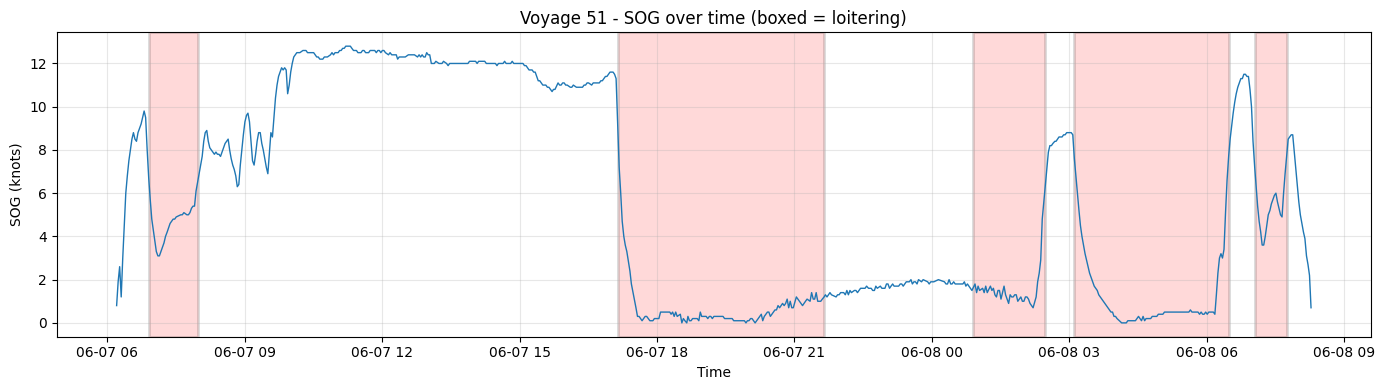

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_voyage_sog_with_loitering_boxes(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    loitering_events: pd.DataFrame,
    voyage_id: int,
    *,
    time_col="Timestamp",
    sog_col="Sog",
    dep_col="t_depart_origin",
    arr_col="t_arrive_dest",
    voyage_id_col="voyage_id",
    ev_start_col="t_start",
    ev_end_col="t_end",
    title_prefix="",
    figsize=(14, 4),
    box_alpha=0.15,
    box_linewidth=2.0,
):
    """
    畫指定 voyage 的 SOG vs Time，並把 loitering event 用「深色框框」框起來。
    - df_points: 你的 AIS 點 df（含 Timestamp, Sog）
    - voyages_df: voyages_with_waiting(_enhanced / _merged 都可)
    - loitering_events: 你想看的事件表（建議用 loitering_events_merged 或 loitering_events_kept_3pts）
    """
    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    v = voyages_df.copy()
    v[dep_col] = pd.to_datetime(v[dep_col], errors="coerce")
    v[arr_col] = pd.to_datetime(v[arr_col], errors="coerce")

    row = v.loc[pd.to_numeric(v[voyage_id_col], errors="coerce") == int(voyage_id)]
    if row.empty:
        print(f"[WARN] voyages_df 找不到 voyage_id={voyage_id}")
        return
    row = row.iloc[0]
    t0, t1 = row[dep_col], row[arr_col]
    if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
        print(f"[WARN] voyage_id={voyage_id} 的時間窗不合法 (t0/t1)")
        return

    seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy().sort_values(time_col)
    if seg.empty:
        print(f"[WARN] voyage_id={voyage_id} 時間窗內沒有 AIS 點")
        return

    if sog_col not in seg.columns:
        print(f"[WARN] df_points 沒有欄位 {sog_col}")
        return

    seg["_sog"] = pd.to_numeric(seg[sog_col], errors="coerce")

    # events
    evs = loitering_events.copy() if isinstance(loitering_events, pd.DataFrame) else pd.DataFrame()
    if not evs.empty:
        if voyage_id_col not in evs.columns:
            print("[WARN] loitering_events 沒有 voyage_id 欄位，無法對應到此航程")
            evs = pd.DataFrame()
        else:
            evs[ev_start_col] = pd.to_datetime(evs[ev_start_col], errors="coerce")
            evs[ev_end_col]   = pd.to_datetime(evs[ev_end_col], errors="coerce")
            evs = evs.loc[pd.to_numeric(evs[voyage_id_col], errors="coerce") == int(voyage_id)]
            evs = evs.dropna(subset=[ev_start_col, ev_end_col]).sort_values(ev_start_col)

    # plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(seg[time_col], seg["_sog"], linewidth=1)

    ax.set_title(f"{title_prefix}Voyage {voyage_id} - SOG over time (boxed = loitering)")
    ax.set_xlabel("Time")
    ax.set_ylabel("SOG (knots)")
    ax.grid(True, alpha=0.3)

    # 深色框框（用 axvspan + edgecolor）
    if not evs.empty:
        ymin, ymax = ax.get_ylim()
        for _, e in evs.iterrows():
            a, b = e[ev_start_col], e[ev_end_col]
            if b <= a:
                continue
            # clamp 到航程時間窗
            a2 = max(a, seg[time_col].min())
            b2 = min(b, seg[time_col].max())
            if b2 <= a2:
                continue

            ax.axvspan(
                a2, b2,
                alpha=box_alpha,
                edgecolor="black",
                linewidth=box_linewidth,
                facecolor="red"  # 你不想要紅底也可以改成 None，但留紅底比較直覺
            )

        # 把 y 軸恢復到原本（因為 axvspan 可能觸發 autoscale）
        ax.set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.show()


# -------------------------
# 用法範例（你只要改 voyage_id）
# -------------------------
voyage_id_to_check = 51

vw = voyages_with_waiting_merged if "voyages_with_waiting_merged" in globals() else \
     (voyages_with_waiting_enhanced if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting)

ev = loitering_events_merged if "loitering_events_merged" in globals() else \
     (loitering_events_kept_3pts if "loitering_events_kept_3pts" in globals() else loitering_events)

plot_voyage_sog_with_loitering_boxes(
    df_points=df,
    voyages_df=vw,
    loitering_events=ev,
    voyage_id=voyage_id_to_check,
    title_prefix="",
)


#### 看r95 km < 5 區間

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_voyage_sog_with_r95_windows(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    voyage_id: int,
    *,
    time_col="Timestamp",
    sog_col="Sog",
    dep_col="t_depart_origin",
    arr_col="t_arrive_dest",
    voyage_id_col="voyage_id",

    # 滑窗參數，預設跟 detect_loitering_events_for_voyages 一樣
    window_sec: int = 10 * 60,       # 10 分鐘窗
    step_sec: int = 2 * 60,          # 每 2 分鐘滑一次
    min_points_in_window: int = 4,   # 要至少幾個點才算一個窗

    # r95 門檻（單位 km）
    r95_thresh_km: float = 5.0,      # 你現在 loitering 的 r95_max_km=5.0，可依需求調整

    title_prefix: str = "",
    figsize=(14, 4),
    box_alpha: float = 0.20,
    box_linewidth: float = 1.5,
    box_facecolor: str = "gold",     # 塗色用的顏色
    lat_col: str = "Lat",
    lon_col: str = "Long",
):
    """
    畫指定 voyage 的 SOG vs Time，並把「滑窗 r95_km < r95_thresh_km」的時間區段塗色。

    會沿用你 loitering detector 中的滑窗邏輯（window_sec / step_sec / min_points_in_window）
    以及 _r95_km 計算半徑。
    """

    # -------- 0) 前處理：時間欄位 / 找出該航程 --------
    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    v = voyages_df.copy()
    v[dep_col] = pd.to_datetime(v[dep_col], errors="coerce")
    v[arr_col] = pd.to_datetime(v[arr_col], errors="coerce")

    row = v.loc[pd.to_numeric(v[voyage_id_col], errors="coerce") == int(voyage_id)]
    if row.empty:
        print(f"[WARN] voyages_df 找不到 voyage_id={voyage_id}")
        return
    row = row.iloc[0]
    t0, t1 = row[dep_col], row[arr_col]
    if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
        print(f"[WARN] voyage_id={voyage_id} 的時間窗不合法 (t0/t1)")
        return

    seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy().sort_values(time_col)
    if seg.empty:
        print(f"[WARN] voyage_id={voyage_id} 時間窗內沒有 AIS 點")
        return

    if sog_col not in seg.columns:
        print(f"[WARN] df_points 沒有欄位 {sog_col}")
        return

    seg["_sog"] = pd.to_numeric(seg[sog_col], errors="coerce")

    # -------- 1) 對這條航程做滑窗，計算 r95 --------
    t_start = seg[time_col].iloc[0]
    t_end   = seg[time_col].iloc[-1]

    intervals = []   # 存 (win_start, win_end) 且 r95 < threshold 的窗
    cur = t_start

    while cur <= t_end:
        w_end = cur + pd.Timedelta(seconds=window_sec)
        w = seg[(seg[time_col] >= cur) & (seg[time_col] < w_end)]

        if len(w) >= min_points_in_window:
            lat = pd.to_numeric(w[lat_col], errors="coerce").to_numpy(dtype=float)
            lon = pd.to_numeric(w[lon_col], errors="coerce").to_numpy(dtype=float)

            # 使用你前面 loitering detector 裡的 _r95_km
            r95 = _r95_km(lat, lon)

            if np.isfinite(r95) and (r95 < r95_thresh_km):
                intervals.append((cur, min(w_end, t_end)))

        cur = cur + pd.Timedelta(seconds=step_sec)

    # -------- 2) 合併有重疊 / 相接的時間區段，避免一堆細碎塊 --------
    def _merge_intervals_simple(intervals_list):
        if not intervals_list:
            return []
        intervals_list = sorted(intervals_list, key=lambda x: x[0])
        out = [list(intervals_list[0])]
        for s, e in intervals_list[1:]:
            ps, pe = out[-1]
            if s <= pe:  # 有重疊或剛好接上
                out[-1][1] = max(pe, e)
            else:
                out.append([s, e])
        return [(a, b) for a, b in out]

    merged_intervals = _merge_intervals_simple(intervals)

    # -------- 3) 畫圖：SOG 曲線 + r95 小的區段塗色 --------
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(seg[time_col], seg["_sog"], linewidth=1)

    title = (
        f"{title_prefix}Voyage {voyage_id} - SOG over time\n"
        f"(highlight windows with r95 < {r95_thresh_km} km)"
    )
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("SOG (knots)")
    ax.grid(True, alpha=0.3)

    ymin, ymax = ax.get_ylim()
    seg_t_min = seg[time_col].min()
    seg_t_max = seg[time_col].max()

    for a, b in merged_intervals:
        # clamp 到航程時間窗
        a2 = max(a, seg_t_min)
        b2 = min(b, seg_t_max)
        if b2 <= a2:
            continue

        ax.axvspan(
            a2, b2,
            alpha=box_alpha,
            edgecolor="black",
            linewidth=box_linewidth,
            facecolor=box_facecolor,
        )

    ax.set_ylim(ymin, ymax)
    plt.tight_layout()
    plt.show()


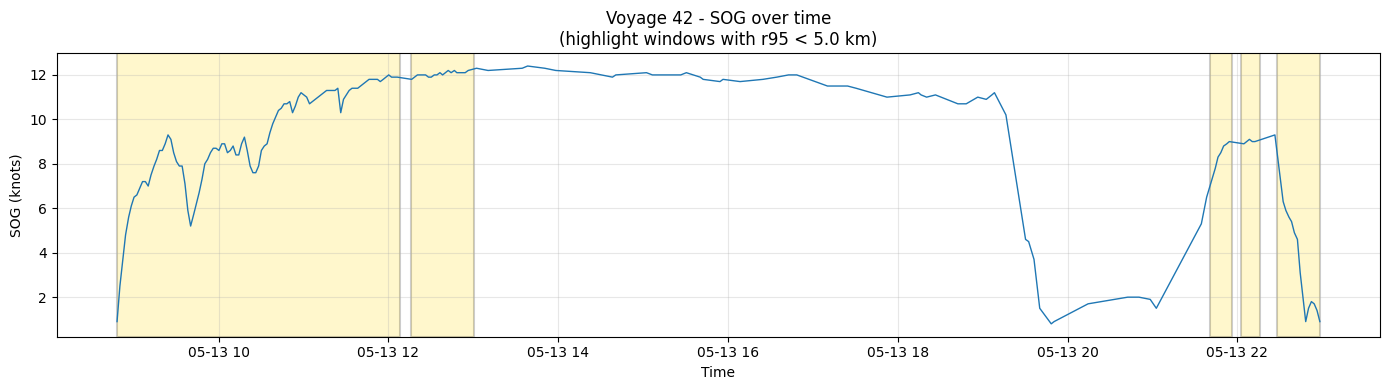

In [77]:
voyage_id_to_check = 42  # 你要看的那條航程 ID

vw = voyages_with_waiting_merged if "voyages_with_waiting_merged" in globals() else \
     (voyages_with_waiting_edgeguarded_3pts if "voyages_with_waiting_edgeguarded_3pts" in globals() else \
      (voyages_with_waiting_enhanced if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting))

plot_voyage_sog_with_r95_windows(
    df_points=df,
    voyages_df=vw,
    voyage_id=voyage_id_to_check,
    # window_sec / step_sec / min_points_in_window 預設就和 loitering 一樣
    r95_thresh_km=5.0,   # 想看「非常緊」的就用 3~5km；想放寬就改成 10
    title_prefix="",
)


#### 看 net_disp_max_km 不符合區段

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_voyage_sog_with_netdisp_violations(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    voyage_id: int,
    *,
    time_col="Timestamp",
    sog_col="Sog",
    dep_col="t_depart_origin",
    arr_col="t_arrive_dest",
    voyage_id_col="voyage_id",

    # 滑窗參數：要和 detect_loitering_events_for_voyages 的設定對得上
    window_sec: int = 10 * 60,       # 10 分鐘窗
    step_sec: int = 2 * 60,          # 每 2 分鐘滑一次
    min_points_in_window: int = 4,   # 窗內至少要有幾個 AIS 點

    # net 位移的門檻（單位：km）
    net_disp_max_km: float = 2.0,    # 你在 loitering 呼叫時用的是 net_disp_max_km=2.0

    title_prefix: str = "",
    figsize=(14, 4),
    box_alpha: float = 0.20,
    box_linewidth: float = 1.5,
    box_facecolor: str = "lightblue",
    lat_col: str = "Lat",
    lon_col: str = "Long",
):
    """
    畫指定 voyage 的 SOG vs Time，並把
      「滑窗 net_disp_km > net_disp_max_km」
    的時間區段用色塊標出來。

    主要用來看：哪些時間窗被「net 位移太大」這個條件踢出 loitering 候選。
    """

    # -------- 0) 前處理：時間欄位 & 找 voyage --------
    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    v = voyages_df.copy()
    v[dep_col] = pd.to_datetime(v[dep_col], errors="coerce")
    v[arr_col] = pd.to_datetime(v[arr_col], errors="coerce")

    row = v.loc[pd.to_numeric(v[voyage_id_col], errors="coerce") == int(voyage_id)]
    if row.empty:
        print(f"[WARN] voyages_df 找不到 voyage_id={voyage_id}")
        return
    row = row.iloc[0]
    t0, t1 = row[dep_col], row[arr_col]
    if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
        print(f"[WARN] voyage_id={voyage_id} 的時間窗不合法 (t0/t1)")
        return

    seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy().sort_values(time_col)
    if seg.empty:
        print(f"[WARN] voyage_id={voyage_id} 時間窗內沒有 AIS 點")
        return

    if sog_col not in seg.columns:
        print(f"[WARN] df_points 沒有欄位 {sog_col}")
        return

    seg["_sog"] = pd.to_numeric(seg[sog_col], errors="coerce")

    # -------- 1) 對這條 voyage 做滑窗，計算 net_disp --------
    t_start = seg[time_col].iloc[0]
    t_end   = seg[time_col].iloc[-1]

    intervals = []   # 存 net_disp_km > net_disp_max_km 的時間窗
    cur = t_start

    while cur <= t_end:
        w_end = cur + pd.Timedelta(seconds=window_sec)
        w = seg[(seg[time_col] >= cur) & (seg[time_col] < w_end)]

        if len(w) >= min_points_in_window:
            lat = pd.to_numeric(w[lat_col], errors="coerce").to_numpy(dtype=float)
            lon = pd.to_numeric(w[lon_col], errors="coerce").to_numpy(dtype=float)

            # 用你上面定義的 _net_disp_km
            net = _net_disp_km(lat, lon)

            # 👉 這裡是「不符合 net_disp_max_km 判斷」的定義：net_disp_km > 門檻
            if np.isfinite(net) and (net <= net_disp_max_km):
                intervals.append((cur, min(w_end, t_end)))

        cur = cur + pd.Timedelta(seconds=step_sec)

    # -------- 2) 合併有重疊 / 相接的區間，避免一堆碎塊 --------
    def _merge_intervals_simple(intervals_list):
        if not intervals_list:
            return []
        intervals_list = sorted(intervals_list, key=lambda x: x[0])
        out = [list(intervals_list[0])]
        for s, e in intervals_list[1:]:
            ps, pe = out[-1]
            if s <= pe:  # 有重疊或剛好接上
                out[-1][1] = max(pe, e)
            else:
                out.append([s, e])
        return [(a, b) for a, b in out]

    merged_intervals = _merge_intervals_simple(intervals)

    # -------- 3) 畫圖：SOG 曲線 + net_disp 違規區段 --------
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(seg[time_col], seg["_sog"], linewidth=1)

    title = (
        f"{title_prefix}Voyage {voyage_id} - SOG over time\n"
        f"(highlight windows where net_disp <= {net_disp_max_km} km)"
    )
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("SOG (knots)")
    ax.grid(True, alpha=0.3)

    ymin, ymax = ax.get_ylim()
    seg_t_min = seg[time_col].min()
    seg_t_max = seg[time_col].max()

    for a, b in merged_intervals:
        # 安全起見，把區間 clamp 在航程時間內
        a2 = max(a, seg_t_min)
        b2 = min(b, seg_t_max)
        if b2 <= a2:
            continue

        ax.axvspan(
            a2, b2,
            alpha=box_alpha,
            edgecolor="black",
            linewidth=box_linewidth,
            facecolor=box_facecolor,
        )

    ax.set_ylim(ymin, ymax)
    plt.tight_layout()
    plt.show()


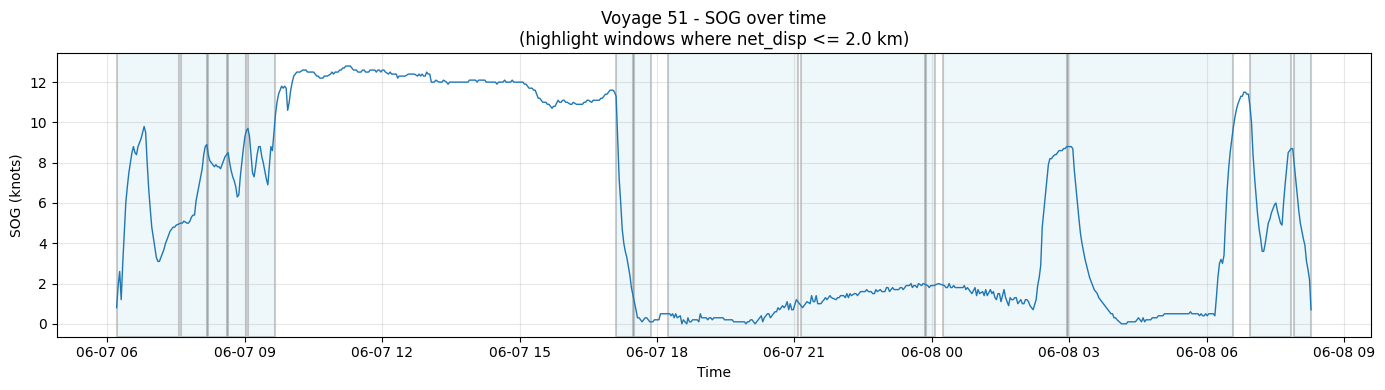

In [93]:
voyage_id_to_check = 51  # 想看的那條 voyage

vw = voyages_with_waiting_merged if "voyages_with_waiting_merged" in globals() else \
     (voyages_with_waiting_edgeguarded_3pts if "voyages_with_waiting_edgeguarded_3pts" in globals() else \
      (voyages_with_waiting_enhanced if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting))

plot_voyage_sog_with_netdisp_violations(
    df_points=df,
    voyages_df=vw,
    voyage_id=voyage_id_to_check,
    window_sec=10*60,
    step_sec=2*60,
    min_points_in_window=4,
    net_disp_max_km=2.0,  # 跟你 detector 呼叫時的設定對齊
    title_prefix="",
)


#### 看low_ratio > 0.7 的低速區段

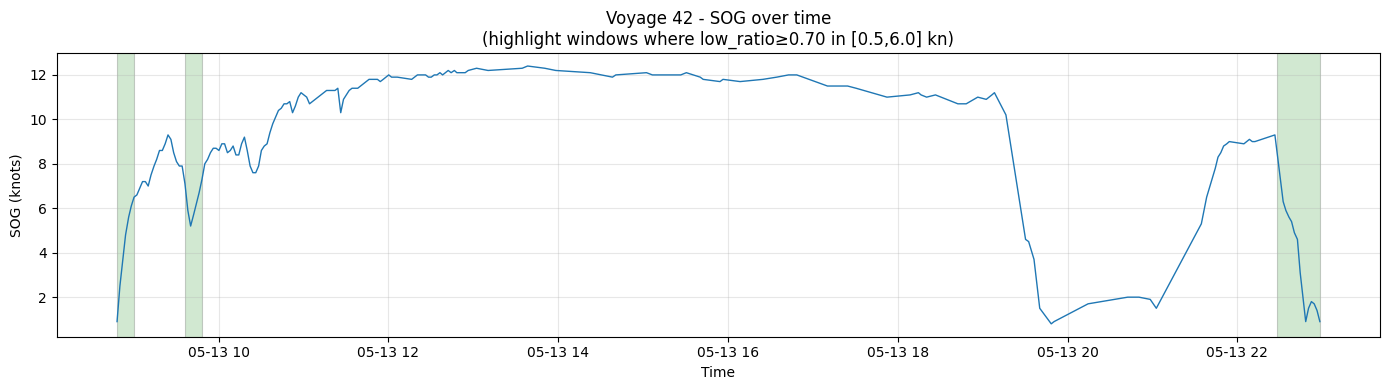

[INFO] voyage 42: low-speed windows count = 3
  #1: 2025-05-13 08:48:17 ~ 2025-05-13 09:00:17  (12.0 min)
  #2: 2025-05-13 09:36:17 ~ 2025-05-13 09:48:17  (12.0 min)
  #3: 2025-05-13 22:28:17 ~ 2025-05-13 22:58:15  (30.0 min)


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _merge_intervals(intervals, max_gap_sec=0):
    """
    intervals: list of (start_ts, end_ts)
    max_gap_sec: 若兩段之間的時間差 <= max_gap_sec，就視為同一段合併
    """
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x[0])
    out = [list(intervals[0])]
    for s, e in intervals[1:]:
        # 跟上一段結尾的 gap
        gap = (s - out[-1][1]).total_seconds()
        if gap <= max_gap_sec:
            out[-1][1] = max(out[-1][1], e)
        else:
            out.append([s, e])
    return [(a, b) for a, b in out]


def plot_voyage_sog_with_low_speed_regions(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    voyage_id: int,
    *,
    time_col="Timestamp",
    sog_col="Sog",
    dep_col="t_depart_origin",
    arr_col="t_arrive_dest",
    voyage_id_col="voyage_id",
    # 低速定義 & 比例門檻
    sog_low_kn: float = 0.5,
    sog_high_kn: float = 6.0,
    low_speed_ratio_th: float = 0.70,
    # 滑窗設定（跟 loitering detector 一樣）
    window_sec: int = 10 * 60,
    step_sec: int =  2 * 60,
    min_points_in_window: int = 4,
    # 畫圖參數
    title_prefix: str = "",
    figsize=(14, 4),
    band_alpha: float = 0.18,
    band_edge_alpha: float = 0.6,
):
    """
    畫指定 voyage 的 SOG vs Time，
    並把「10 分鐘窗內 SOG 在 [sog_low_kn, sog_high_kn] 之間比例 >= low_speed_ratio_th」
    的區段用背景色標出。
    """
    # ----- 準備資料 -----
    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    v = voyages_df.copy()
    v[dep_col] = pd.to_datetime(v[dep_col], errors="coerce")
    v[arr_col] = pd.to_datetime(v[arr_col], errors="coerce")

    row = v.loc[pd.to_numeric(v[voyage_id_col], errors="coerce") == int(voyage_id)]
    if row.empty:
        print(f"[WARN] voyages_df 找不到 voyage_id={voyage_id}")
        return
    row = row.iloc[0]
    t0, t1 = row[dep_col], row[arr_col]
    if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
        print(f"[WARN] voyage_id={voyage_id} 的時間窗不合法 (t0/t1)")
        return

    seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy().sort_values(time_col)
    if seg.empty:
        print(f"[WARN] voyage_id={voyage_id} 時間窗內沒有 AIS 點")
        return
    if sog_col not in seg.columns:
        print(f"[WARN] df_points 沒有欄位 {sog_col}")
        return

    seg["_sog"] = pd.to_numeric(seg[sog_col], errors="coerce")

    # ----- 計算低速窗 (low_ratio >= threshold) -----
    t_start = seg[time_col].iloc[0]
    t_end   = seg[time_col].iloc[-1]

    cur = t_start
    candidate_intervals = []

    while cur <= t_end:
        w_end = cur + pd.Timedelta(seconds=window_sec)
        w = seg[(seg[time_col] >= cur) & (seg[time_col] < w_end)]
        if len(w) >= min_points_in_window:
            sog = w["_sog"].to_numpy(dtype=float)
            band = (sog >= sog_low_kn) & (sog <= sog_high_kn)
            low_ratio = float(np.nanmean(band)) if len(sog) else 0.0

            if low_ratio >= low_speed_ratio_th:
                # 這一窗被視為「低速為主」區間
                candidate_intervals.append((cur, min(w_end, t_end)))
        cur = cur + pd.Timedelta(seconds=step_sec)

    # 合併重疊/相鄰窗，這裡 gap=0 表示只合併重疊或相接的
    merged_low_windows = _merge_intervals(candidate_intervals, max_gap_sec=0)

    # ----- 畫圖 -----
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(seg[time_col], seg["_sog"], linewidth=1)

    ax.set_title(
        f"{title_prefix}Voyage {voyage_id} - SOG over time\n"
        f"(highlight windows where low_ratio≥{low_speed_ratio_th:.2f} in [{sog_low_kn},{sog_high_kn}] kn)"
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("SOG (knots)")
    ax.grid(True, alpha=0.3)

    ymin, ymax = ax.get_ylim()

    # 背景上色：低速區
    for a, b in merged_low_windows:
        if b <= a:
            continue
        ax.axvspan(
            a, b,
            alpha=band_alpha,
            facecolor="green",
            edgecolor="black",
            linewidth=0.8,
        )

    ax.set_ylim(ymin, ymax)
    plt.tight_layout()
    plt.show()

    # debug 用：印出找到幾段
    print(f"[INFO] voyage {voyage_id}: low-speed windows count = {len(merged_low_windows)}")
    for i, (a, b) in enumerate(merged_low_windows, start=1):
        dur_min = (b - a).total_seconds() / 60.0
        print(f"  #{i}: {a} ~ {b}  ({dur_min:.1f} min)")


# -------------------------
# 用法範例
# -------------------------
voyage_id_to_check = 42

vw = voyages_with_waiting_merged if "voyages_with_waiting_merged" in globals() else \
     (voyages_with_waiting_enhanced if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting)

plot_voyage_sog_with_low_speed_regions(
    df_points=df,
    voyages_df=vw,
    voyage_id=voyage_id_to_check,
    sog_low_kn=0.5,
    sog_high_kn=6.0,
    low_speed_ratio_th=0.70,
    window_sec=10*60,
    step_sec=2*60,
    min_points_in_window=4,
)


#### 看tort ≥ 2.5 或 (sog_std_w95 ≥ 0.20 且 net ≤ 2 km)

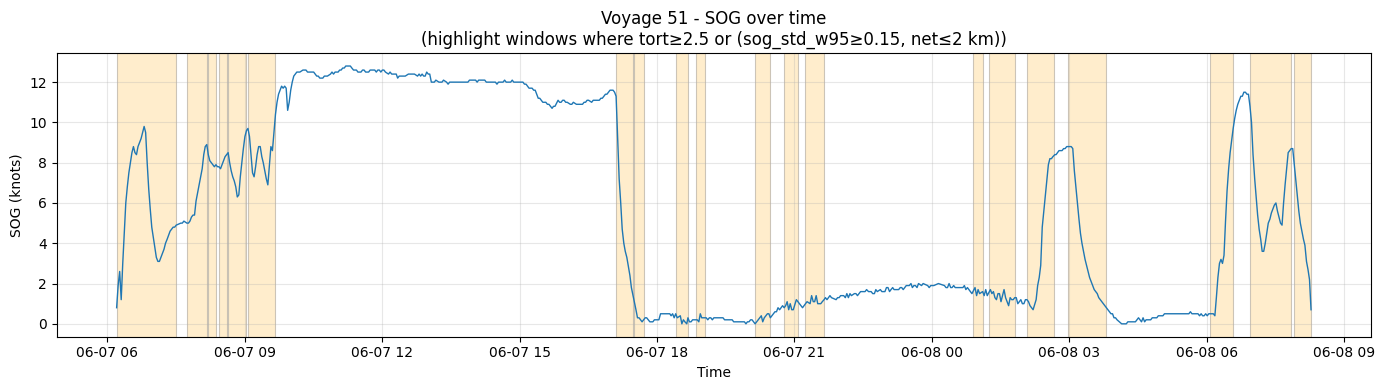

[INFO] voyage 51: geom/jitter windows count = 20
  #1: 2025-06-07 06:12:25 ~ 2025-06-07 07:30:25  (78.0 min)
  #2: 2025-06-07 07:44:25 ~ 2025-06-07 08:10:25  (26.0 min)
  #3: 2025-06-07 08:12:25 ~ 2025-06-07 08:22:25  (10.0 min)
  #4: 2025-06-07 08:26:25 ~ 2025-06-07 08:36:25  (10.0 min)
  #5: 2025-06-07 08:38:25 ~ 2025-06-07 09:02:25  (24.0 min)
  #6: 2025-06-07 09:04:25 ~ 2025-06-07 09:40:25  (36.0 min)
  #7: 2025-06-07 17:06:25 ~ 2025-06-07 17:28:25  (22.0 min)
  #8: 2025-06-07 17:30:25 ~ 2025-06-07 17:42:25  (12.0 min)
  #9: 2025-06-07 18:24:25 ~ 2025-06-07 18:40:25  (16.0 min)
  #10: 2025-06-07 18:50:25 ~ 2025-06-07 19:02:25  (12.0 min)
  #11: 2025-06-07 20:08:25 ~ 2025-06-07 20:28:25  (20.0 min)
  #12: 2025-06-07 20:46:25 ~ 2025-06-07 21:04:25  (18.0 min)
  #13: 2025-06-07 21:14:25 ~ 2025-06-07 21:38:25  (24.0 min)
  #14: 2025-06-08 00:54:25 ~ 2025-06-08 01:06:25  (12.0 min)
  #15: 2025-06-08 01:14:25 ~ 2025-06-08 01:48:25  (34.0 min)
  #16: 2025-06-08 02:04:25 ~ 2025-06-08 02:40

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_voyage_sog_with_loiter_geometry_regions(
    df_points: pd.DataFrame,
    voyages_df: pd.DataFrame,
    voyage_id: int,
    *,
    time_col="Timestamp",
    lat_col="Lat",
    lon_col="Long",
    sog_col="Sog",
    dep_col="t_depart_origin",
    arr_col="t_arrive_dest",
    voyage_id_col="voyage_id",

    # 幾何 / jitter 門檻（請對齊你 detect_loitering_events_for_voyages 的設定）
    tortuosity_min: float = 2.5,
    sog_std_w95_min: float = 0.20,
    net_disp_max_km: float = 2.0,

    # 滑窗設定
    window_sec: int = 10 * 60,
    step_sec: int = 2 * 60,
    min_points_in_window: int = 4,

    # 畫圖設定
    title_prefix: str = "",
    figsize=(14, 4),
    band_alpha: float = 0.20,
):
    """
    畫指定 voyage 的 SOG vs Time，
    並把「(tort >= tortuosity_min) OR (sog_std_w95 >= sog_std_w95_min 且 net <= net_disp_max_km)」
    的 10 分鐘滑窗區間塗色。

    依賴你前面已定義的:
      - _path_len_km(lat, lon)
      - _net_disp_km(lat, lon)
      - _winsorize_std(sog, clip_pct=2.5)
    """

    def _merge_intervals_local(intervals, max_gap_sec=0):
        if not intervals:
            return []
        intervals = sorted(intervals, key=lambda x: x[0])
        out = [list(intervals[0])]
        for s, e in intervals[1:]:
            gap = (s - out[-1][1]).total_seconds()
            if gap <= max_gap_sec:
                out[-1][1] = max(out[-1][1], e)
            else:
                out.append([s, e])
        return [(a, b) for a, b in out]

    # ---------- 準備資料 ----------
    d = df_points.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    v = voyages_df.copy()
    v[dep_col] = pd.to_datetime(v[dep_col], errors="coerce")
    v[arr_col] = pd.to_datetime(v[arr_col], errors="coerce")

    row = v.loc[pd.to_numeric(v[voyage_id_col], errors="coerce") == int(voyage_id)]
    if row.empty:
        print(f"[WARN] voyages_df 找不到 voyage_id={voyage_id}")
        return
    row = row.iloc[0]
    t0, t1 = row[dep_col], row[arr_col]
    if pd.isna(t0) or pd.isna(t1) or t1 <= t0:
        print(f"[WARN] voyage_id={voyage_id} 的時間窗不合法 (t0/t1)")
        return

    seg = d[(d[time_col] >= t0) & (d[time_col] <= t1)].copy().sort_values(time_col)
    if seg.empty:
        print(f"[WARN] voyage_id={voyage_id} 時間窗內沒有 AIS 點")
        return

    # ---------- 滑窗計算 tort / sog_std_w95 / net ----------
    t_start = seg[time_col].iloc[0]
    t_end   = seg[time_col].iloc[-1]

    cur = t_start
    candidate_intervals = []

    while cur <= t_end:
        w_end = cur + pd.Timedelta(seconds=window_sec)
        w = seg[(seg[time_col] >= cur) & (seg[time_col] < w_end)]
        if len(w) >= min_points_in_window:
            lat = pd.to_numeric(w[lat_col], errors="coerce").to_numpy(dtype=float)
            lon = pd.to_numeric(w[lon_col], errors="coerce").to_numpy(dtype=float)
            sog = pd.to_numeric(w[sog_col], errors="coerce").to_numpy(dtype=float)

            # 幾何量
            net = _net_disp_km(lat, lon)
            plen = _path_len_km(lat, lon)
            tort = float(plen / max(net, 1e-6))

            # 速度 jitter
            sog_std_w95 = _winsorize_std(sog, clip_pct=2.5)

            cond_circling = (np.isfinite(tort) and tort >= tortuosity_min)
            cond_jitter   = (
                np.isfinite(sog_std_w95) and (sog_std_w95 >= sog_std_w95_min)
                and np.isfinite(net) and (net <= net_disp_max_km)
            )

            if cond_circling or cond_jitter:
                candidate_intervals.append((cur, min(w_end, t_end)))

        cur = cur + pd.Timedelta(seconds=step_sec)

    geom_windows = _merge_intervals_local(candidate_intervals, max_gap_sec=0)

    # ---------- 畫圖 ----------
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(seg[time_col], seg[sog_col], linewidth=1)

    ax.set_title(
        f"{title_prefix}Voyage {voyage_id} - SOG over time\n"
        f"(highlight windows where tort≥{tortuosity_min} "
        f"or (sog_std_w95≥{sog_std_w95_min}, net≤{net_disp_max_km} km))"
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("SOG (knots)")
    ax.grid(True, alpha=0.3)

    ymin, ymax = ax.get_ylim()
    for a, b in geom_windows:
        if b <= a:
            continue
        ax.axvspan(
            a, b,
            alpha=band_alpha,
            facecolor="orange",   # 幾何 / jitter 區塊
            edgecolor="black",
            linewidth=0.8,
        )
    ax.set_ylim(ymin, ymax)
    plt.tight_layout()
    plt.show()

    print(f"[INFO] voyage {voyage_id}: geom/jitter windows count = {len(geom_windows)}")
    for i, (a, b) in enumerate(geom_windows, start=1):
        dur_min = (b - a).total_seconds() / 60.0
        print(f"  #{i}: {a} ~ {b}  ({dur_min:.1f} min)")


# -------------------------
# 用法範例
# -------------------------
voyage_id_to_check = 51

vw = voyages_with_waiting_merged if "voyages_with_waiting_merged" in globals() else \
     (voyages_with_waiting_enhanced if "voyages_with_waiting_enhanced" in globals() else voyages_with_waiting)

plot_voyage_sog_with_loiter_geometry_regions(
    df_points=df,
    voyages_df=vw,
    voyage_id=voyage_id_to_check,
    tortuosity_min=2.5,
    sog_std_w95_min=0.15,
    net_disp_max_km=2,
    window_sec=10*60,
    step_sec=2*60,
    min_points_in_window=4,
)


#### 輸出為csv

In [34]:
import numpy as np
import pandas as pd
from pathlib import Path
from math import radians, sin, cos, atan2, sqrt

# -----------------------------
# helpers
# -----------------------------
def _to_lon180(dlon):
    return ((dlon + 180.0) % 360.0) - 180.0

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlmb = radians(_to_lon180(lon2 - lon1))
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlmb/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

def bearing_deg(lat1, lon1, lat2, lon2):
    # initial bearing, degrees [0,360)
    lat1, lat2 = radians(lat1), radians(lat2)
    dlon = radians(_to_lon180(lon2 - lon1))
    x = sin(dlon) * cos(lat2)
    y = cos(lat1)*sin(lat2) - sin(lat1)*cos(lat2)*cos(dlon)
    brng = atan2(x, y)
    deg = (brng * 180.0 / np.pi + 360.0) % 360.0
    return float(deg)

def _build_voyage_id_for_points(df_points, voyages_df,
                               time_col="Timestamp",
                               dep_col="t_depart_origin", arr_col="t_arrive_dest",
                               voyage_id_col="voyage_id"):
    """assign voyage_id to each point by IntervalIndex [dep, arr]"""
    d = df_points.sort_values(time_col).copy()
    v = voyages_df.sort_values(dep_col).reset_index(drop=True).copy()

    intervals = pd.IntervalIndex.from_arrays(
        pd.to_datetime(v[dep_col], errors="coerce"),
        pd.to_datetime(v[arr_col], errors="coerce"),
        closed="both"
    )
    pos = intervals.get_indexer(pd.to_datetime(d[time_col], errors="coerce"))
    d[voyage_id_col] = pd.Series(np.where(pos >= 0, v[voyage_id_col].to_numpy()[np.clip(pos, 0, len(v)-1)], np.nan),
                                 index=d.index)
    d[voyage_id_col] = pd.to_numeric(d[voyage_id_col], errors="coerce").astype("Int64")
    return d

def _attach_stop_id_to_points(points_df, stops_df,
                             time_col="Timestamp",
                             stop_start="t_start", stop_end="t_end",
                             stop_id_col="stop_id"):
    """
    point 落在任何 stop (t_start~t_end) => stop_id
    用 merge_asof 找到最近的 stop_start，再檢查是否 <= stop_end
    """
    p = points_df.sort_values(time_col).copy()
    s = stops_df.sort_values(stop_start).copy()

    # 只保留必要欄位，避免欄名衝突
    s_key = s[[stop_id_col, stop_start, stop_end]].copy()
    s_key[stop_start] = pd.to_datetime(s_key[stop_start], errors="coerce")
    s_key[stop_end]   = pd.to_datetime(s_key[stop_end], errors="coerce")

    p[time_col] = pd.to_datetime(p[time_col], errors="coerce")
    out = pd.merge_asof(
        p, s_key,
        left_on=time_col, right_on=stop_start,
        direction="backward",
        allow_exact_matches=True
    )

    in_stop = (out[stop_id_col].notna()) & (out[time_col] <= out[stop_end])
    out[stop_id_col] = out[stop_id_col].where(in_stop, pd.NA).astype("Int64")
    out = out.drop(columns=[stop_start, stop_end], errors="ignore")
    return out

def _compute_point_features(points_df,
                            time_col="Timestamp", lat_col="Lat", lon_col="Long"):
    d = points_df.sort_values(time_col).copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")

    d["dt_sec"] = d[time_col].diff().dt.total_seconds()

    lat1 = pd.to_numeric(d[lat_col].shift(1), errors="coerce").to_numpy()
    lon1 = pd.to_numeric(d[lon_col].shift(1), errors="coerce").to_numpy()
    lat2 = pd.to_numeric(d[lat_col], errors="coerce").to_numpy()
    lon2 = pd.to_numeric(d[lon_col], errors="coerce").to_numpy()

    dist = np.full(len(d), np.nan, dtype=float)
    brng = np.full(len(d), np.nan, dtype=float)

    for i in range(1, len(d)):
        if np.any(np.isnan([lat1[i], lon1[i], lat2[i], lon2[i]])):
            continue
        dist[i] = haversine_km(lat1[i], lon1[i], lat2[i], lon2[i])
        brng[i] = bearing_deg(lat1[i], lon1[i], lat2[i], lon2[i])

    d["dist_km"] = dist
    d["bearing_deg"] = brng

    # 由位置推估速度（kn）
    d["speed_from_pos_kn"] = (d["dist_km"] / (d["dt_sec"] / 3600.0)) / 1.852
    d.loc[(d["dt_sec"] <= 0) | (~np.isfinite(d["dt_sec"])), "speed_from_pos_kn"] = np.nan

    d["cum_dist_km"] = d["dist_km"].fillna(0.0).cumsum()

    return d

def _mark_point_large_gaps(points_df, gap_sec_th=6*3600, time_col="Timestamp"):
    d = points_df.sort_values(time_col).copy()
    d["point_large_time_gap_flag"] = (d["dt_sec"] >= gap_sec_th) if "dt_sec" in d.columns else False
    return d

# -----------------------------
# choose the final voyages table
# -----------------------------
# 你最後通常會用 voyages_with_waiting_merged（含 loitering summary）
voyages_final = None
if "voyages_with_waiting_merged" in globals():
    voyages_final = voyages_with_waiting_merged.copy()
elif "voyages_with_waiting_edgeguarded_3pts" in globals():
    voyages_final = voyages_with_waiting_edgeguarded_3pts.copy()
elif "voyages_with_waiting_enhanced" in globals():
    voyages_final = voyages_with_waiting_enhanced.copy()
else:
    voyages_final = voyages_with_waiting.copy()

# -----------------------------
# build "all points": keep dropped teleport points too
# -----------------------------
# df: teleport-cleaned points
df_keep = df.copy()

# 將 teleport 被刪掉的點補回來（若你想「完整含異常點」一起輸出）
# teleport_report 只有 orig_index/時間/座標，所以我們從原始 csv 再把那些 rows 取回來
# 注意：load_and_preprocess 會清欄位/型別，所以這裡用同一個 loader 讀一次原始，再挑出 orig_index
df_all = df_keep.copy()
df_all["teleport_dropped_flag"] = False

if "teleport_report" in globals() and isinstance(teleport_report, pd.DataFrame) and len(teleport_report) > 0:
    try:
        df_raw = load_and_preprocess(csv_path, target_mmsi)  # 重新載入「未刪 teleport」版本
        # remove_teleport_points() 當時 reset_index rename -> orig_index 是原 df 的 row index
        drop_idx = pd.to_numeric(teleport_report["orig_index"], errors="coerce").dropna().astype(int).unique().tolist()
        df_dropped = df_raw.reset_index(drop=True).loc[drop_idx].copy()

        df_dropped["teleport_dropped_flag"] = True

        # 合併回去（避免重複：用 Timestamp+Lat+Long 粗略去重）
        df_all = pd.concat([df_keep, df_dropped], ignore_index=True, sort=False)
        df_all = df_all.drop_duplicates(subset=["Timestamp", "Lat", "Long"], keep="first").sort_values("Timestamp").reset_index(drop=True)

        # cleaned 的點 flag 補 False
        df_all["teleport_dropped_flag"] = df_all["teleport_dropped_flag"].fillna(False)
    except Exception as e:
        print("[warn] failed to re-attach teleport-dropped points, fallback to cleaned df only:", e)

# -----------------------------
# make sure loitering point flags exist (optional)
# -----------------------------
# 你目前有 df_loitering_labeled（time-based label），但它是對 df_points 的拷貝
# 我們用 Timestamp 對齊，把 loitering_flag / loitering_event_id merge 回 df_all
if "df_loitering_labeled" in globals() and isinstance(df_loitering_labeled, pd.DataFrame) and len(df_loitering_labeled) > 0:
    tmp = df_loitering_labeled[["Timestamp", "Lat", "Long", "loitering_flag", "loitering_event_id"]].copy()
    df_all = df_all.merge(tmp, on=["Timestamp", "Lat", "Long"], how="left")
else:
    df_all["loitering_flag"] = False
    df_all["loitering_event_id"] = np.nan

df_all["loitering_flag"] = df_all["loitering_flag"].fillna(False)
# -----------------------------
# 1) assign voyage_id to each point
# -----------------------------
df_pts = _build_voyage_id_for_points(df_all, voyages_final)

# 只保留落在任一 voyage 的點
df_pts = df_pts[df_pts["voyage_id"].notna()].copy()

# -----------------------------
# 2) add point-level features + gap flags
# -----------------------------
df_pts = _compute_point_features(df_pts)
df_pts = _mark_point_large_gaps(df_pts, gap_sec_th=6*3600)

# -----------------------------
# 3) attach stop_id to points
# -----------------------------
df_pts = _attach_stop_id_to_points(df_pts, stops_labeled)

# -----------------------------
# 4) merge voyage-level metadata (ports, times, flags, totals)
# -----------------------------
vmeta_cols = [c for c in voyages_final.columns if c not in ["mmsi"]]  # mmsi 也可留
vmeta = voyages_final.copy()

# voyage duration / progress ratio
vmeta["voyage_duration_sec"] = (pd.to_datetime(vmeta["t_arrive_dest"]) - pd.to_datetime(vmeta["t_depart_origin"])).dt.total_seconds()
df_pts = df_pts.merge(
    vmeta[[
        "voyage_id",
        "mmsi",
        "origin_port_id","origin_port_name","dest_port_id","dest_port_name",
        "t_depart_origin","t_arrive_dest",
        "total_waiting_sec",
        "large_time_gap_flag","max_dt_sec","max_dt_hr","gap_from","gap_to",
        *([c for c in ["total_loitering_sec","loitering_events_count"] if c in vmeta.columns])
    ]],
    on="voyage_id",
    how="left"
)

# progress ratio (0~1) within voyage
t = pd.to_datetime(df_pts["Timestamp"], errors="coerce")
t0 = pd.to_datetime(df_pts["t_depart_origin"], errors="coerce")
t1 = pd.to_datetime(df_pts["t_arrive_dest"], errors="coerce")
dur = (t1 - t0).dt.total_seconds().replace(0, np.nan)
df_pts["progress_ratio"] = ((t - t0).dt.total_seconds() / dur).clip(lower=0, upper=1)

# -----------------------------
# 5) merge stop metadata (stop_type, centers, dist_to_port, waiting_for_dest)
# -----------------------------
stop_meta = stops_labeled.copy()
stop_keep_cols = [
    "stop_id","stop_type",
    "t_start","t_end","duration_sec",
    "center_lat","center_lon",
    "nearest_port_id","nearest_port_name","dist_to_port_km",
    "avg_sog","sog_std","sog_p95","sog_std_w95","radius_km",
    "waiting_for_dest_port_id",
]
stop_keep_cols = [c for c in stop_keep_cols if c in stop_meta.columns]
stop_meta = stop_meta[stop_keep_cols].copy()

df_pts = df_pts.merge(stop_meta, on="stop_id", how="left", suffixes=("", "_stop"))

# add a clean point-in-stop flag
df_pts["in_stop_flag"] = df_pts["stop_id"].notna()

# -----------------------------
# 6) (optional) tag "stop is waiting for dest" boolean at point level
# -----------------------------
df_pts["waiting_for_dest_flag"] = df_pts["waiting_for_dest_port_id"].notna()

# -----------------------------
# 7) reorder / pick columns (keep all original + new)
# -----------------------------
core_cols = [
    "mmsi","voyage_id",
    "Timestamp","Lat","Long","Sog",
    "teleport_dropped_flag",
    "dt_sec","dist_km","speed_from_pos_kn","bearing_deg","cum_dist_km","progress_ratio",
    "point_large_time_gap_flag",
    "loitering_flag","loitering_event_id",
    "origin_port_id","origin_port_name","dest_port_id","dest_port_name",
    "t_depart_origin","t_arrive_dest",
    "large_time_gap_flag","max_dt_hr","gap_from","gap_to",
    "total_waiting_sec",
    "stop_id","in_stop_flag","stop_type",
    "t_start","t_end","duration_sec",
    "center_lat","center_lon","dist_to_port_km",
    "nearest_port_id","nearest_port_name",
    "waiting_for_dest_flag","waiting_for_dest_port_id",
    *([c for c in ["total_loitering_sec","loitering_events_count"] if c in df_pts.columns])
]
core_cols = [c for c in core_cols if c in df_pts.columns]

# 把原始欄位（你 df 中可能還有 Cog/Heading/NavStatus...）也一起帶上
other_cols = [c for c in df_pts.columns if c not in core_cols]
export_cols = core_cols + other_cols

df_export = df_pts[export_cols].sort_values(["voyage_id","Timestamp"]).reset_index(drop=True)

# -----------------------------
# 8) save to CSV
# -----------------------------
out_dir = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage2 ETA" / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / f"voyages_points_enriched_{target_mmsi}.csv"
df_export.to_csv(out_path, index=False, encoding="utf-8-sig")
print("Saved:", out_path)
print("Rows:", len(df_export), "Cols:", len(df_export.columns))

display(df_export.head(5))


  已對 MMSI=477848300 進行 SOG 校正（/10）
  已套用 SOG_CAP=50.0：刪除 1 筆不合理 SOG


C:\Users\slab\AppData\Local\Temp\ipykernel_20580\3499261654.py:155: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["teleport_dropped_flag"] = df_all["teleport_dropped_flag"].fillna(False)
C:\Users\slab\AppData\Local\Temp\ipykernel_20580\3499261654.py:171: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["loitering_flag"] = df_all["loitering_flag"].fillna(False)


Saved: C:\Users\slab\Desktop\Slab Project\Stage2 ETA\outputs\voyages_points_enriched_477848300.csv
Rows: 63967 Cols: 92


,mmsi,voyage_id,Timestamp,Lat,Long,Sog,teleport_dropped_flag,dt_sec,dist_km,speed_from_pos_kn,...,B_WindSpeed,B_WindAngle,B_RPM,Long_360,max_dt_sec,avg_sog,sog_std,sog_p95,sog_std_w95,radius_km
0,477848300,1,2025-01-02 10:30:05,26.008933,119.480033,0.3,False,NaN,NaN,NaN,...,NaN,NaN,NaN,119.480033,90242.0,0.003839,0.041635,0.0,0.0,0.012963
1,477848300,1,2025-01-02 10:32:05,26.008733,119.480567,1.1,False,120.0,0.057752,0.935503,...,NaN,NaN,NaN,119.480567,90242.0,NaN,NaN,NaN,NaN,NaN
2,477848300,1,2025-01-02 10:34:06,26.008033,119.481583,3.1,False,121.0,0.127989,2.056115,...,NaN,NaN,NaN,119.481583,90242.0,NaN,NaN,NaN,NaN,NaN
3,477848300,1,2025-01-02 10:36:05,26.005867,119.480917,3.7,False,119.0,0.249965,4.083134,...,NaN,NaN,NaN,119.480917,90242.0,NaN,NaN,NaN,NaN,NaN
4,477848300,1,2025-01-02 10:38:05,26.005317,119.480383,0.3,False,120.0,0.081124,1.314099,...,NaN,NaN,NaN,119.480383,90242.0,NaN,NaN,NaN,NaN,NaN
